# Lib Installation

In [1]:
!pip install  lightning pytorch-lightning torchvision  tqdm python-dotenv PyYAML wilds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Config

In [2]:
config = {
    "algo": "FOND",
    "dataset": ["PACS", "VLCS", "OfficeHome", "Wilds"],  # Options: VLCS, PACS
    "test_set_id": 0,  # 0, 1, 2, or 3
    # Paths
    
    "data_dir": {"PACS":"/kaggle/input/pacs-dataset/kfold", "VLCS": "/kaggle/input/vlcsdataset/", "OfficeHome": "/kaggle/input/officehome/OfficeHome/", "Wilds": ""},
    "log_dir": "./logs",
    # Training settings
    "n_epochs": 5001,  # Converted from 5001 steps (~15 epochs at 32 batch size)
    "checkpoint_freq": 300,  # Evaluate every epoch (was 300 steps)
    "holdout_fraction": 0.2,
    # Model checkpointing
    "model_checkpoint": {
        "metric": "val/oacc",
        "maximize": True
    },
    # Seeds
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,  # 0=default hparams, 1-4=random variants
    # System
    "num_workers": 4,
    # Dataset config (from sweep)
    "overlap": "high",  # Must match PACS.OVERLAP_CONFIG keys
    "num_classes": None,
    "num_domain_linked_classes": None,
    # AutoFOND specific (disabled for baseline)
    "auto_augment": False,
    "augment_search_epochs": 5,
    "augment_policy_size": 5,
    "augment_num_policies": 3,
    # Teacher paths (empty for regular FOND)
    "teacher_paths": {}
}

# Imports

In [3]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
import os
import torch
import torchmetrics
import torchvision.datasets.folder
from PIL import Image, ImageFile
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST, ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset





# SRC

## Domain Creation

In [4]:



def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


## Hparams

In [5]:
"""
Hyper-parameter registry
"""


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # Unconditional hparam definitions.

    _hparam("data_augmentation", True, lambda r: True)
    _hparam("resnet18", True, lambda r: True)
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # Algorithm-specific hparam definitions. Each block of code below
    # corresponds to exactly one algorithm.

    if (
        algorithm == "FOND"
        or algorithm == "FOND_NC"
        or algorithm == "FOND_N"
        or algorithm == "NOC"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
    elif (
        algorithm == "FOND_Distillation_Separate_Projector"
        or algorithm == "FOND_Distillation_Teacher_Projector"
        or algorithm == "FOND_Distillation_Student_Projector"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # Dataset-and-algorithm-specific hparam definitions. Each block of code
    # below corresponds to exactly one hparam. Avoid nested conditionals.

    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))

    if dataset in SMALL_IMAGES:
        _hparam("weight_decay", 0.0, lambda r: 0.0)
    else:
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))

    if dataset in SMALL_IMAGES:
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    elif algorithm == "ARM":
        _hparam("batch_size", 8, lambda r: 8)
    elif dataset == "DomainNet":
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
    else:
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}


## Misc

In [6]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1
    
    network.train()
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes
    
    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)
            
            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()
            
            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)
    
    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy
    
    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])
    
    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)
    
    other_acc = correct / total
    
    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [8]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""
    
    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV
        
        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}
            
        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value
        
        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()
            
        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return
            
        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write
        
    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)
        
        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)
            
    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""
    
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" 
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")
        
    def close(self):
        pass


# Fast Auto Augment

In [9]:
# ===========================
# FAST AUTOAUGMENT DEFINITIONS
# ===========================
import random
import PIL
import PIL.ImageOps
import PIL.ImageEnhance
import PIL.ImageDraw
import numpy as np
from torchvision.transforms.transforms import Compose

random_mirror = True

# -----------------------
# Basic augmentation functions
# -----------------------
def ShearX(img, v):
    assert -0.3 <= v <= 0.3
    if random_mirror and random.random() > 0.5:
        v = -v
    return img.transform(img.size, PIL.Image.AFFINE, (1, v, 0, 0, 1, 0))

def ShearY(img, v):
    assert -0.3 <= v <= 0.3
    if random_mirror and random.random() > 0.5:
        v = -v
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, 0, v, 1, 0))

def TranslateX(img, v):
    assert -0.45 <= v <= 0.45
    if random_mirror and random.random() > 0.5:
        v = -v
    v = v * img.size[0]
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, v, 0, 1, 0))

def TranslateY(img, v):
    assert -0.45 <= v <= 0.45
    if random_mirror and random.random() > 0.5:
        v = -v
    v = v * img.size[1]
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, 0, 0, 1, v))

def Rotate(img, v):
    assert -30 <= v <= 30
    if random_mirror and random.random() > 0.5:
        v = -v
    return img.rotate(v)

def AutoContrast(img, _):
    return PIL.ImageOps.autocontrast(img)

def Invert(img, _):
    return PIL.ImageOps.invert(img)

def Equalize(img, _):
    return PIL.ImageOps.equalize(img)

def Solarize(img, v):
    assert 0 <= v <= 256
    return PIL.ImageOps.solarize(img, v)

def Posterize(img, v):
    assert 4 <= v <= 8
    return PIL.ImageOps.posterize(img, int(v))

def Contrast(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Contrast(img).enhance(v)

def Color(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Color(img).enhance(v)

def Brightness(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Brightness(img).enhance(v)

def Sharpness(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Sharpness(img).enhance(v)

def Cutout(img, v):
    assert 0.0 <= v <= 0.2
    if v <= 0.:
        return img
    v = v * img.size[0]
    return CutoutAbs(img, v)

def CutoutAbs(img, v):
    if v < 0:
        return img
    w, h = img.size
    x0 = np.random.uniform(0, w)
    y0 = np.random.uniform(0, h)
    x0 = int(max(0, x0 - v / 2.))
    y0 = int(max(0, y0 - v / 2.))
    x1 = min(w, x0 + v)
    y1 = min(h, y0 + v)
    xy = (x0, y0, x1, y1)
    color = (125, 123, 114)
    img = img.copy()
    PIL.ImageDraw.Draw(img).rectangle(xy, color)
    return img

# -----------------------
# List of augmentations
# -----------------------
def augment_list():
    return [
        ("ShearX", ShearX),
        ("ShearY", ShearY),
        ("TranslateX", TranslateX),
        ("TranslateY", TranslateY),
        ("Rotate", Rotate),
        ("AutoContrast", AutoContrast),
        ("Invert", Invert),
        ("Equalize", Equalize),
        ("Solarize", Solarize),
        ("Posterize", Posterize),
        ("Contrast", Contrast),
        ("Color", Color),
        ("Brightness", Brightness),
        ("Sharpness", Sharpness),
        ("Cutout", Cutout)
    ]

# -----------------------
# Fast AutoAugment class
# -----------------------
class FastAutoAugment:
    def __init__(self, policy):
        self.policy = policy
        self.augment_list = {name: func for name, func in augment_list()}

    def __call__(self, img):
        policy = random.choice(self.policy)  # pick one policy
        for op_name, prob, level in policy:
            if random.random() < prob:
                func = self.augment_list[op_name]
                img = func(img, level)
        return img

# -----------------------
# Example CIFAR-10 style policy
# You can replace this with any other policy
# -----------------------
example_policy = [
    [("Invert", 0.7, 1), ("Contrast", 0.5, 1)],
    [("Rotate", 0.6, 30), ("Sharpness", 0.5, 2)],
    [("Color", 0.6, 1), ("ShearX", 0.8, 0.3)]
]

# -----------------------
# Helper to create transform
# -----------------------
def get_fast_autoaugment_transform():
    return FastAutoAugment(example_policy)


In [10]:
from torchvision import transforms
import random

def get_fast_autoaugment_transform():
    """
    A simplified Fast AutoAugment-like transform using torchvision only.
    """
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
        ),
        transforms.RandomGrayscale(p=0.1),
        transforms.RandomRotation(degrees=15),
    ])


# Dataset

## Base

In [11]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

DATASETS2 = [
    # Debug
    "Debug28",
    "Debug224",
    # Small images
    "ColoredMNIST",
    "RotatedMNIST",
    # Big images
    "VLCS",
    "PACS",
    "OfficeHome",
    "TerraIncognita",
    "DomainNet",
    "SVIRO",
    # WILDS datasets
    "WILDSCamelyon",
    "WILDSFMoW",
    # Spawrious datasets
    "SpawriousO2O_easy",
    "SpawriousO2O_medium",
    "SpawriousO2O_hard",
    "SpawriousM2M_easy",
    "SpawriousM2M_medium",
    "SpawriousM2M_hard",
]

# OVERLAP_TYPES = ["none", "low", "mid", "high", "full", "0", "33", "66", "100"]
SPECIAL_OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]
OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]


def get_domain_classes(N_c, N_oc, repeat, N_s, seed):
    N_noc = N_c - N_oc
    Q = []
    C = list(range(N_c))

    random_state = np.random.RandomState(seed)

    # choose non overlapping classes
    C_noc = list(random_state.choice(C, replace=False, size=N_noc))
    C_oc = [x for x in C if x not in C_noc]

    # add to queue
    Q.extend(C_noc + list(np.repeat(C_oc, repeat)))

    # Round-robing distribution of classes
    domain_classes = [Q[i::N_s] for i in range(N_s)]

    # assert overlapping classes
    overlap = np.zeros(N_c)
    for cls_list in domain_classes:
        np.add.at(overlap, cls_list, 1)

    assert C_oc == list(np.where(overlap > 1)[0])

    # output
    print("C_noc", C_noc)
    print("C_oc", C_oc)
    print("Q", Q)
    print("domain_classes", domain_classes)

    return domain_classes


class DomainBedImageFolder(ImageFolder):
    """
    Custom class to allow class filtering
    """

    def __init__(
        self,
        root: str,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        remove_classes: List[int] = [],
        allowed_classes: List[int] = [],
        is_test_env: Optional[bool] = None,
        env_name: Optional[str] = None,
    ):
        super().__init__(root, transform, target_transform)

        # Remove specified classes
        old_samples = self.samples
        self.samples = []
        self.targets = []
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name
        for sample in old_samples:
            _, target = sample

            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = list(set(self.targets))

    def __len__(self) -> int:
        return len(self.samples)

    def __str__(self):
        return (
            f"{self.env_name}: is_test_env={self.is_test_env}, allowed_classes={self.allowed_classes},"
            f" list(set(self.targets))={self.classes}, num_samples={len(self)}"
        )


def get_overlapping_classes(
    class_split: List[List[int]], num_classes: int
) -> List[int]:
    """
    Return the classes in multiple domains.
    """
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)

    overlapping_classes = list(np.where(overlap > 1)[0])

    return overlapping_classes


def get_dataset_class(dataset_name):
    """Return the dataset class with the given name."""
    if dataset_name not in globals():
        raise NotImplementedError("Dataset not found: {}".format(dataset_name))
    return globals()[dataset_name]


def num_environments(dataset_name):
    return len(get_dataset_class(dataset_name).ENVIRONMENTS)


class MultipleDomainDataset:
    N_STEPS = 5001  # Default, subclasses may override
    CHECKPOINT_FREQ = 100  # Default, subclasses may override
    N_WORKERS = 8  # Default, subclasses may override
    ENVIRONMENTS = None  # Subclasses should override
    INPUT_SHAPE = None  # Subclasses should override

    def __getitem__(self, index):
        return self.datasets[index]

    def __len__(self):
        return len(self.datasets)


class Debug(MultipleDomainDataset):
    def __init__(self, root, test_envs, hparams):
        super().__init__()
        self.input_shape = self.INPUT_SHAPE
        self.num_classes = 2
        self.datasets = []
        for _ in [0, 1, 2]:
            self.datasets.append(
                TensorDataset(
                    torch.randn(16, *self.INPUT_SHAPE),
                    torch.randint(0, self.num_classes, (16,)),
                )
            )


class Debug28(Debug):
    INPUT_SHAPE = (3, 28, 28)
    ENVIRONMENTS = ["0", "1", "2"]


class Debug224(Debug):
    INPUT_SHAPE = (3, 224, 224)
    ENVIRONMENTS = ["0", "1", "2"]


class MultipleEnvironmentMNIST(MultipleDomainDataset):
    def __init__(
        self,
        root,
        environments,
        dataset_transform,
        input_shape,
        num_classes,
        test_envs: List[int],
        domain_class_filter: List[List[int]],
    ):
        super().__init__()
        if root is None:
            raise ValueError("Data directory not specified!")

        original_dataset_tr = MNIST(root, train=True, download=True)
        original_dataset_te = MNIST(root, train=False, download=True)

        original_images = torch.cat(
            (original_dataset_tr.data, original_dataset_te.data)
        )

        original_labels = torch.cat(
            (original_dataset_tr.targets, original_dataset_te.targets)
        )

        shuffle = torch.randperm(len(original_images))

        original_images = original_images[shuffle]
        original_labels = original_labels[shuffle]

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"
        num_envs = len(environments)

        self.num_classes = num_classes
        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        self.datasets = []

        for i in range(len(environments)):
            images = original_images[i :: len(environments)]
            labels = original_labels[i :: len(environments)]
            self.datasets.append(dataset_transform(images, labels, environments[i]))

        self.input_shape = input_shape


class MultipleEnvironmentImageFolder(MultipleDomainDataset):
    def __init__(
        self,
        root,
        test_envs,
        augment,
        hparams,
        domain_class_filter: List[List[int]],
        num_classes=None,
    ):
        super().__init__()
        environments = [f.name for f in os.scandir(root) if f.is_dir()]
        environments = sorted(environments)
        num_envs = len(environments)

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"

        self.idx_to_class = self.get_idx_to_class(
            os.path.join(root, environments[test_envs[0]])
        )
        self.num_classes = (
            len(self.idx_to_class) if num_classes is None else num_classes
        )

        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        print(f"num_envs={num_envs}, num_filters={num_filters}, domain_class_filter={domain_class_filter}")
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        # Base transform (for test or default)
        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        # Old augmentation transform (optional)
        augment_transform = transforms.Compose(
            [
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        # Create datasets for each environment
        self.datasets = []
        for i, environment in enumerate(environments):
            path = os.path.join(root, environment)

            # Setup augmentation
            if augment and (i not in test_envs):
                if hparams.get("use_fast_autoaugment", False):
                    env_transform = transforms.Compose(
                        [
                            get_fast_autoaugment_transform(),
                            transforms.ToTensor(),
                            transforms.Normalize(
                                mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225],
                            ),
                        ]
                    )
                else:
                    env_transform = augment_transform
            else:
                env_transform = transform

            # Setup class filtering
            all_classes = set(list(self.idx_to_class.keys()))
            if i not in test_envs:
                filter_classes = domain_class_filter[shift_filter.pop()]
                if filter_classes == []:
                    continue
                remove_classes = list(all_classes - set(filter_classes))

                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=False,
                    allowed_classes=filter_classes,
                    env_name=environment,
                )
            else:
                remove_classes = list(range(self.num_classes, len(all_classes)))
                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=True,
                    allowed_classes=list(range(self.num_classes)),
                    env_name=environment,
                )
                assert self.num_classes == len(env_dataset.classes)

            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (3, 224, 224)

    def get_idx_to_class(self, data_dir: str) -> Dict[int, str]:
        dataset = ImageFolder(data_dir)
        idx_to_class = {}
        for key, value in dataset.class_to_idx.items():
            idx_to_class.update({value: key})
        assert len(dataset.class_to_idx) == len(idx_to_class), "Class and labels are not one-to-one"
        return idx_to_class


## PACS

In [12]:


class PACS(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "S"])
    NUM_CLASSES = 7
    OVERLAP_CONFIG = {
        "0": [[0, 1], [2, 3], [4, 5, 6]],
        "low": [[0, 1, 2], [2, 3, 4], [4, 5, 6]],
        "high": [[0, 1, 2, 3], [2, 3, 4, 5], [4, 5, 6, 0]],
        "100": [list(range(7)), list(range(7)), list(range(7))],
        "low_linked_only": [[0, 1], [3], [5, 6]],
        "high_linked_only": [[0, 1], [], [6]],
    }

    # overlap_type
    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        # print(f"[info] {type(self)}, test_envs: {test_envs}, overlap: {class_overlap_id}")
        self.dir = root
        print(root)
        self._num_source_domains = 3
        self._num_classes = 7

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            PACS.OVERLAP_CONFIG[overlap_type],
        )


## VLCS

In [13]:
class VLCS(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["C", "L", "S", "V"])
    NUM_CLASSES = 5
    OVERLAP_CONFIG = {
        "0": [[0, 1], [2, 3], [4]],
        "low": [[0, 1, 2], [2, 3], [3, 4]],
        "high": [[0, 1, 2], [2, 3, 4], [3, 4, 0]],
        "low_linked_only": [[0, 1], [], [4]],
        "high_linked_only": [[1], [], []],
        "100": [list(range(5)), list(range(5)), list(range(5))],
    }

    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        # print(f"[info] {type(self)}, test_envs: {test_envs}, overlap: {class_overlap_id}")
        self.dir = os.path.join(root, "VLCS/")
        self._num_source_domains = 3
        self._num_classes = 5

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            VLCS.OVERLAP_CONFIG[overlap_type],
        )


## OfficeHome

In [14]:


class OfficeHome(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "R"])
    OVERLAP_CONFIG = {
        "0": [list(range(0, 22)), list(range(22, 44)), list(range(44, 65))],
        "low": [list(range(0, 30)), list(range(14, 44)), list(range(35, 65))],  # 25/65
        "high": [list(range(0, 38)), list(range(5, 44)), list(range(27, 65))],  # 50/65
        "low_linked_only": [
            list(range(0, 14)),
            list(range(30, 35)),
            list(range(44, 65)),
        ],
        "high_linked_only": [list(range(0, 5)), [], list(range(44, 65))],
        "100": [list(range(65)), list(range(65)), list(range(65))],
    }

    def __init__(
        self,
        root: str,
        test_envs: List[int],
        hparams: dict,
        num_classes: int,
        num_domain_linked_classes: int,
        overlap_type=None,
        overlap_seed=None,
    ):
        
        self.dir = root
        self._num_source_domains = 3
        self._num_classes = 65

        domain_class_filter = []
        if overlap_type is not None:
            logging.info(
                f"Using predefined class distributions: overlap_type={overlap_type}"
            )
            domain_class_filter = OfficeHome.OVERLAP_CONFIG[overlap_type]
        else:
            logging.info(
                f"Using dynamic class distributions: num_classes={num_classes}, num_linked={num_domain_linked_classes}, num_train_domains={self._num_source_domains}"
            )
            assert num_classes <= self._num_classes
            self._num_classes = num_classes
            domain_class_filter = create_domains(
                num_classes=num_classes,
                num_linked=num_domain_linked_classes,
                num_train_domains=self._num_source_domains,
            )
        print(f"DEBUG: overlap_type={overlap_type}")
        print(f"DEBUG: domain_class_filter={domain_class_filter}")
        print(f"DEBUG: len(domain_class_filter)={len(domain_class_filter)}")
        print(f"DEBUG: test_envs={test_envs}")


        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            domain_class_filter=domain_class_filter,
            num_classes=self._num_classes
        )


## Wilds

In [15]:

class WILDSEnvironment:
    def __init__(
        self, 
        wilds_dataset, 
        metadata_name, 
        metadata_value, 
        transform=None,
        is_test_env=False,
        allowed_classes=None  # Filter samples by class
    ):
        self.name = metadata_name + "_" + str(metadata_value)
        self.is_test_env = is_test_env

        metadata_index = wilds_dataset.metadata_fields.index(metadata_name)
        metadata_array = wilds_dataset.metadata_array
        subset_indices = torch.where(
            metadata_array[:, metadata_index] == metadata_value
        )[0]

        # Filter by allowed classes if specified
        if allowed_classes is not None:
            y_values = wilds_dataset.y_array[subset_indices]
            class_mask = torch.zeros(len(subset_indices), dtype=torch.bool)
            for allowed_class in allowed_classes:
                class_mask |= (y_values == allowed_class)
            subset_indices = subset_indices[class_mask]
            print(f"  {self.name}: Filtered to classes {allowed_classes}, {len(subset_indices)} samples")
        else:
            print(f"  {self.name}: All classes, {len(subset_indices)} samples")

        self.dataset = wilds_dataset
        self.indices = subset_indices
        self.transform = transform

    def __getitem__(self, i):
        x = self.dataset.get_input(self.indices[i])
        if type(x).__name__ != "Image":
            x = Image.fromarray(x)

        y = self.dataset.y_array[self.indices[i]]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.indices)


class WILDSDataset(MultipleDomainDataset):
    INPUT_SHAPE = (3, 224, 224)

    def __init__(
        self, 
        dataset, 
        metadata_name, 
        test_envs, 
        augment, 
        hparams,
        overlap_config
    ):
        super().__init__()

        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        augment_transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        self.datasets = []
        metadata_values = self.metadata_values(dataset, metadata_name)
        
        print(f"[WILDS] Creating {len(metadata_values)} environments with overlap config: {overlap_config}")

        # Map environment index to allowed classes
        # Test environments get all classes, source environments get restricted classes
        source_env_idx = 0
        for i, metadata_value in enumerate(metadata_values):
            if augment and (i not in test_envs):
                env_transform = augment_transform
            else:
                env_transform = transform

            # Determine allowed classes for this environment
            if i in test_envs:
                # Test environment gets all classes
                allowed_classes = None
                print(f"[WILDS] Env {i} (TEST): all classes")
            else:
                # Source environment gets restricted classes from overlap_config
                if source_env_idx < len(overlap_config):
                    allowed_classes = overlap_config[source_env_idx]
                    print(f"[WILDS] Env {i} (SOURCE): classes {allowed_classes}")
                else:
                    allowed_classes = None
                    print(f"[WILDS] Env {i} (SOURCE): all classes (no config)")
                source_env_idx += 1

            env_dataset = WILDSEnvironment(
                dataset, 
                metadata_name, 
                metadata_value, 
                env_transform,
                is_test_env=(i in test_envs),
                allowed_classes=allowed_classes
            )

            self.datasets.append(env_dataset)

        self.input_shape = (3, 224, 224)
        self.num_classes = dataset.n_classes
        
        # Set overlapping classes from overlap_config (same as PACS/VLCS)
        all_overlapping = set()
        for domain_classes in overlap_config:
            all_overlapping.update(domain_classes)
        self.overlapping_classes = sorted(list(all_overlapping))
        
        print(f"[WILDS] Total overlapping classes: {self.overlapping_classes}")
        print(f"[WILDS] Dataset created with {len(self.datasets)} environments")

    def metadata_values(self, wilds_dataset, metadata_name):
        metadata_index = wilds_dataset.metadata_fields.index(metadata_name)
        metadata_vals = wilds_dataset.metadata_array[:, metadata_index]
        return sorted(list(set(metadata_vals.view(-1).tolist())))


class WILDSCamelyon(WILDSDataset):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = [
        "hospital_0",
        "hospital_1",
        "hospital_2",
        "hospital_3",
        "hospital_4",
    ]
    NUM_CLASSES = 2  # Binary: 0=normal, 1=tumor
    
    # Overlap configurations matching PACS/VLCS structure
    # For 4 source domains (when 1 is held out as test)
    OVERLAP_CONFIG = {
        "0": [[0], [1], [0, 1], [0]],  # Minimal overlap
        "low": [[0], [0, 1], [1], [0, 1]],  # Some overlap
        "high": [[0, 1], [0, 1], [0, 1], [0, 1]],  # Full overlap
        "100": [[0, 1], [0, 1], [0, 1], [0, 1]],  # All classes everywhere
        "low_linked_only": [[0], [], [1], []],  # Sparse
        "high_linked_only": [[0], [], [], []],  # Very sparse
    }

    def __init__(
        self, 
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        self.dir = os.path.join(root, "camelyon17_v1.0/")
        self._num_source_domains = 4  # 5 hospitals - 1 test = 4 source
        self._num_classes = 2
        
        print(f"[WILDSCamelyon] Initializing with overlap_type: {overlap_type}")
        print(f"[WILDSCamelyon] Test environments: {test_envs}")
        
        dataset = Camelyon17Dataset(root_dir=root)
        
        print(f"[WILDSCamelyon] Loaded base dataset: {len(dataset)} total samples")
        print(f"[WILDSCamelyon] Number of classes: {dataset.n_classes}")
        
        super().__init__(
            dataset,
            "hospital",
            test_envs,
            hparams["data_augmentation"],
            hparams,
            WILDSCamelyon.OVERLAP_CONFIG[overlap_type],
        )


# if __name__ == '__main__':
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--data_dir", type=str, default="./data")
#     parser.add_argument("--overlap", type=str, default="high")
#     args = parser.parse_args()
    
#     dataset = WILDSCamelyon(
#         root=args.data_dir, 
#         test_envs=[0], 
#         hparams={'data_augmentation': True},
#         overlap_type=args.overlap
#     )
    
#     print(f"\n=== Dataset Summary ===")
#     print(f"Number of classes: {dataset.num_classes}")
#     print(f"Overlapping classes: {dataset.overlapping_classes}")
#     print(f"Number of environments: {len(dataset.datasets)}")
    
#     for i, env in enumerate(dataset.datasets):
#         print(f"  {env.name}: {len(env)} samples (test={env.is_test_env})")

## INIT

In [16]:
DATASETS = {
    "PACS": PACS,
    "VLCS": VLCS,
    "OfficeHome": OfficeHome,
    #"WILDSCamelyon": WILDSCamelyon
}


# Networks

## Base


In [17]:

class Identity(nn.Module):
    """An identity layer"""

    def __init__(self):
        super(Identity, self).__init__()

    def forward(self, x):
        return x


class ResNet(torch.nn.Module):
    """ResNet with the softmax chopped off and the batchnorm frozen"""

    def __init__(self, input_shape, hparams):
        """
        If you're using Compute Canada you will need to manually download
        and store the appropriate resnet18 and resnet50 weight files. Currently
        we are using:
            ResNet18_Weights.IMAGENET1K_V1
                "https://download.pytorch.org/models/resnet18-f37072fd.pth",
            ResNet50_Weights.IMAGENET1K_V2
                "https://download.pytorch.org/models/resnet50-11ad3fa6.pth",

        """
        super(ResNet, self).__init__()
        resnet18 = hparams["resnet18"]
        if resnet18:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet18-f37072fd.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet18: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet18()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet18(
                    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
                )

            self.n_outputs = 512
        else:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet50-11ad3fa6.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet50: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet50()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet50(
                    weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
                )

            self.n_outputs = 2048

        # self.network = remove_batch_norm_from_resnet(self.network)

        # adapt number of channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()

            self.network.conv1 = nn.Conv2d(
                nc, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            )

            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # save memory
        del self.network.fc
        self.network.fc = Identity()

        self.freeze_bn()
        self.hparams = hparams
        self.dropout = nn.Dropout(hparams["resnet_dropout"])

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        return self.dropout(self.network(x))

    def train(self, mode=True):
        """
        Override the default train() to freeze the BN parameters
        """
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()


def Featurizer(input_shape, hparams):
    """Auto-select an appropriate featurizer for the given input shape."""
    # if len(input_shape) == 1:
    #     return MLP(input_shape[0], hparams["mlp_width"], hparams)
    # elif input_shape[1:3] == (28, 28):
    #     return MNIST_CNN(input_shape)
    # elif input_shape[1:3] == (32, 32):
    #     return wide_resnet.Wide_ResNet(input_shape, 16, 2, 0.)
    # elif input_shape[1:3] == (224, 224):
    if input_shape[1:3] == (224, 224):
        return ResNet(input_shape, hparams)
    else:
        raise NotImplementedError


def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return torch.nn.Sequential(
            torch.nn.Linear(in_features, in_features // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 2, in_features // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 4, out_features),
        )
    else:
        return torch.nn.Linear(in_features, out_features)


class Algorithm(torch.nn.Module):
    """
    A subclass of Algorithm implements a domain generalization algorithm.
    Subclasses should implement the following:
    - update()
    - predict()
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(Algorithm, self).__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        """
        Perform one update step, given a list of (x, y) tuples for all
        environments.

        Admits an optional list of unlabeled minibatches from the test domains,
        when task is domain_adaptation.
        """
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


class ERM(Algorithm):
    """
    Empirical Risk Minimization (ERM)
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(ERM, self).__init__(input_shape, num_classes, num_domains, hparams)
        self.featurizer = Featurizer(input_shape, self.hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs, num_classes, self.hparams["nonlinear_classifier"]
        )

        self.network = nn.Sequential(self.featurizer, self.classifier)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])
        loss = F.cross_entropy(self.predict(all_x), all_y)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## Fond

In [18]:


class AbstractXDom(ERM):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(AbstractXDom, self).__init__(
            input_shape, num_classes, num_domains, hparams
        )

        self.domain_relations = hparams.get("domain_relations", None)

        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]

        encoder_output = 512 if hparams["resnet18"] else 2048
        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )

        def weight_init(m):
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.projector.apply(weight_init)

        self.optimizer = torch.optim.Adam(
            (
                list(self.featurizer.parameters())
                + list(self.classifier.parameters())
                + list(self.projector.parameters())
            ),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        """
        Generate masks relating samples and their domains/classes
        """
        # mask-out self-contrast cases
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)

        # mask out dot products between different classes
        same_Y_mask = torch.eq(Y.view(-1, 1), Y.view(-1, 1).T)
        # mask out dot products between different domains
        same_D_mask = torch.eq(D.view(-1, 1), D.view(-1, 1).T)

        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(
        self,
        projections,
        positive_mask,
        negative_mask,
        alpha: torch.Tensor,
        beta: torch.Tensor,
        epsilon: float = 1e-6,
    ):
        """
        Regular FOND_FBA Loss with custom masks for positive and A(i) "negative" samples
        """

        mean_positives_per_sample = (
            torch.count_nonzero(positive_mask) / projections.shape[0]
        )

        # count the number of samples with no positives
        num_zero_positives = projections.shape[0] - torch.count_nonzero(
            positive_mask.sum(1)
        )

        # proj_dot is cos similarity b/c features are normalized
        # find the dot product with respect to every x
        proj_dot = torch.div(torch.matmul(projections, projections.T), self.temperature)

        # for numeric stability so sum is never zero
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()

        # compute exp per element (i.e. over each cosine similarity)
        exp_logits = torch.exp(logits) * negative_mask * beta
        # weigh intra domain negatives higher = same domain different class

        # decompose log(exp(x)/y) = x - log(y)
        # y = summation of cos similarities excluding self
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positives
        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (
            positive_mask.sum(1) + epsilon
        )

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.mean()

        return loss, mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        # NOTE: current implementations doesn't create duplicates
        # check SelfReg

        num_domains = len(minibatches)
        features = [self.featurizer(xi) for xi, _ in minibatches]

        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]

        # create domain labels
        domains = [
            torch.zeros(len(x), dtype=torch.uint8).to(x.device) + i
            for i, x in enumerate(targets)
        ]

        # match domains
        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new

        return {
            "features": features,
            "projections": projections,
            "classifs": classifs,
            "targets": targets,
            "domains": domains,
            "num_domains": num_domains,
        }

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FONDBase, self).__init__(input_shape, num_classes, num_domains, hparams)

        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


class FOND(FONDBase):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND, self).__init__(input_shape, num_classes, num_domains, hparams)


class FOND_NC(FONDBase):
    """
    Based on FOND however we replace the fairness loss with the domain-linked
    classification loss
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_NC, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = (
            class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


# FOND with a non overlapping class loss, but no overall class loss
class FOND_N(FONDBase):
    """
    Guiding Question: Why optimize for domain-shared class accuracy if
    we are only interested in domain-linked classes? Does including domain-shared
    classes for the contrastive objective only improve domain-linked class
    performance?

    Based on FOND however we keep the domain-shared and domain-linked
    contrastive loss and only optimize for the domain-linked classification
    loss.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_N, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = self.xdom_lmbd * xdom_loss + noc_class_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


## Init

In [19]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",
    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [20]:
def fit_simple(
    exp_dir: str,
    logger,  # CSVLogger or PrintLogger
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,  
    checkpoint_freq: int = 300,  
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
):
    # ------------------ SEED EVERYTHING ------------------
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # ------------------ DEVICE ------------------
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # ------------------ HYPERPARAMETERS ------------------
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )
    logging.info(f"hparams: {hparams}")
   
    # ------------------ DATASET ------------------
    dataset = DATASETS[dataset_name](
        root=data_dir,
        test_envs=test_envs,
        hparams=hparams,
        overlap_type=overlap_type,
        num_classes=num_classes,
        num_domain_linked_classes=num_domain_linked_classes,
    )
    
    # Optionally run Fast AutoAugment search
    if auto_augment and augment_search_epochs > 0:
        dataset = run_fast_autoaugment_search(dataset, epochs=augment_search_epochs)
    
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")
    
    # ------------------ SPLIT ENVIRONMENTS ------------------
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()
    
    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )
        
        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None
        
        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))
        
        if env.is_test_env:
            relative_test_env = env_i
    
    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")
    
    # ------------------ DATA LOADERS ------------------
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]
    
    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]
    
    eval_weights = [None for _, weights in (in_splits + out_splits)]
    
    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")
    
    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])
    
    # ------------------ ALGORITHM ------------------
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)
        
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )
    
    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")
    
    # ------------------ MODEL STATS ------------------
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)
    
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")
    
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
    }
    
    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)
    
    # ------------------ TRAINING LOOP ------------------
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""
    
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")
    
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }
    
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0
    
    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()
        
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]
        
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)
        
        steps_in_current_epoch += 1
        
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()
        
        # ------------------ LOGGING & EVALUATION ------------------
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {key: {k: [] for k in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"] + [f"acc-{i}" for i in range(dataset.num_classes)]} for key in ["train","val","test","other"]}
            
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                results_dict["train"][str(key)] = [np.mean(val)]
            
            for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(algorithm, loader, weights, device, dataset)
                loss = compute_loss(algorithm, loader, device)
                domain_idx = int(name[3])
                
                if domain_idx == relative_test_env:
                    loader_type = "test" if "in" in name else "other"
                elif "out" in name:
                    loader_type = "val"
                else:
                    loader_type = "train"
                
                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))
                
                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)
            
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)
            
            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    for metric in ["acc", "precision", "recall", "f1", "loss"]:
                        epoch_history[split][metric].append(np.mean(results_dict[split][metric]))
            
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")
            for stage in ["train","val","test","other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}: loss={np.mean(results_dict[stage]['loss']):.4f}, acc={np.mean(results_dict[stage]['acc']):.4f}, precision={np.mean(results_dict[stage]['precision']):.4f}, recall={np.mean(results_dict[stage]['recall']):.4f}, f1={np.mean(results_dict[stage]['f1']):.4f}")
            
            logger.log(results_dict, step)
            
            # ------------------ MODEL CHECKPOINT ------------------
            if model_checkpoint is not None:
                maximize = model_checkpoint["maximize"]
                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])
                ckpt_path = os.path.join(log_dir, f"{id}_model_step{step}.ckpt")
                
                update_ckpt = False
                if best_model_checkpoint_value is None:
                    update_ckpt = True
                elif maximize and current_model_checkpoint_value > best_model_checkpoint_value:
                    update_ckpt = True
                elif not maximize and current_model_checkpoint_value < best_model_checkpoint_value:
                    update_ckpt = True
                
                if update_ckpt:
                    if best_model_checkpoint_path and os.path.exists(best_model_checkpoint_path):
                        os.remove(best_model_checkpoint_path)
                    torch.save(algorithm, ckpt_path)
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    logging.info(f"Updated checkpoint {model_checkpoint['metric']} to {best_model_checkpoint_value}")
                
            checkpoint_vals = collections.defaultdict(lambda: [])
    
    # TRAINING COMPLETE - NOW PRINT EVERYTHING
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"{'='*60}\n")
    
    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
    }
    
    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)
    
    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])
        
        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)
        
        # Determine split type
        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"
        
        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Save confusion matrix as CSV
        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")
        
        # Plot confusion matrix as heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)
        
        # Save confusion matrix plot
        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.show()
        plt.close()
    
    # Generate and save plots
    epochs = epoch_history["epochs"]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name}', fontsize=16)
    
    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
       ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Precision and Recall
    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.show()
    plt.close()
    
    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1), 
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name}')
        ax.grid(True, alpha=0.3)
        
        # Add average line
        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--', 
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()
        
        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.show()
        plt.close()
    
    # Save epoch history for later analysis
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None 
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)
    
    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}.png")
    print(f"  - epoch_times_{dataset_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

# Train AutoFOND

## Setup

In [21]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = input()
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)


 third_experiment


## OfficeHome

In [28]:
dataset_name = config["dataset"][2]
dataset_name

'OfficeHome'

Seed set to 0


DEBUG: overlap_type=high
DEBUG: domain_class_filter=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]]
DEBUG: len(domain_class_filter)=3
DEBUG: test_envs=[0]
num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,

  0%|          | 0/5001 [02:17<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 137.2387s
TRAIN: loss=5.1686, acc=0.0065, precision=0.0046, recall=0.0065, f1=0.0037
VAL: loss=4.3883, acc=0.0085, precision=0.0100, recall=0.0085, f1=0.0050
TEST: loss=4.4434, acc=0.0107, precision=0.0025, recall=0.0107, f1=0.0034
OTHER: loss=4.3820, acc=0.0031, precision=0.0004, recall=0.0031, f1=0.0006


  6%|▌         | 301/5001 [07:53<50:52:06, 38.96s/it]

...


=== Step 4500 (Epoch 74.15) ===
step_time: 130.6528s
TRAIN: loss=0.1976, acc=0.9490, precision=0.9511, recall=0.9490, f1=0.9498
VAL: loss=0.7043, acc=0.6711, precision=0.7035, recall=0.6711, f1=0.6764
TEST: loss=3.2576, acc=0.3786, precision=0.4441, recall=0.3786, f1=0.3569
OTHER: loss=3.0246, acc=0.3742, precision=0.3977, recall=0.3742, f1=0.3419


 96%|█████████▌| 4801/5001 [1:31:39<2:10:23, 39.12s/it]


=== Step 4800 (Epoch 79.09) ===
step_time: 128.9380s
TRAIN: loss=0.1798, acc=0.9515, precision=0.9531, recall=0.9515, f1=0.9521
VAL: loss=0.7233, acc=0.7101, precision=0.7319, recall=0.7101, f1=0.7123
TEST: loss=3.0301, acc=0.4087, precision=0.4521, recall=0.4087, f1=0.3784
OTHER: loss=2.9711, acc=0.4123, precision=0.4775, recall=0.4123, f1=0.3826


100%|██████████| 5001/5001 [1:36:07<00:00,  1.15s/it]  



=== Step 5000 (Epoch 82.39) ===
step_time: 129.4766s
TRAIN: loss=0.1791, acc=0.9943, precision=0.9938, recall=0.9943, f1=0.9939
VAL: loss=0.6497, acc=0.7138, precision=0.7379, recall=0.7138, f1=0.7190
TEST: loss=3.0031, acc=0.4169, precision=0.4723, recall=0.4169, f1=0.3882
OTHER: loss=2.8480, acc=0.4178, precision=0.4525, recall=0.4178, f1=0.3846

TRAINING COMPLETED
Total training time: 5767.87s (96.13 minutes)
Average time per epoch: 69.10s
Total epochs: 81


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 3.0073
  Accuracy: 0.4169, Precision: 0.4723, Recall: 0.4169, F1: 0.3882
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.png


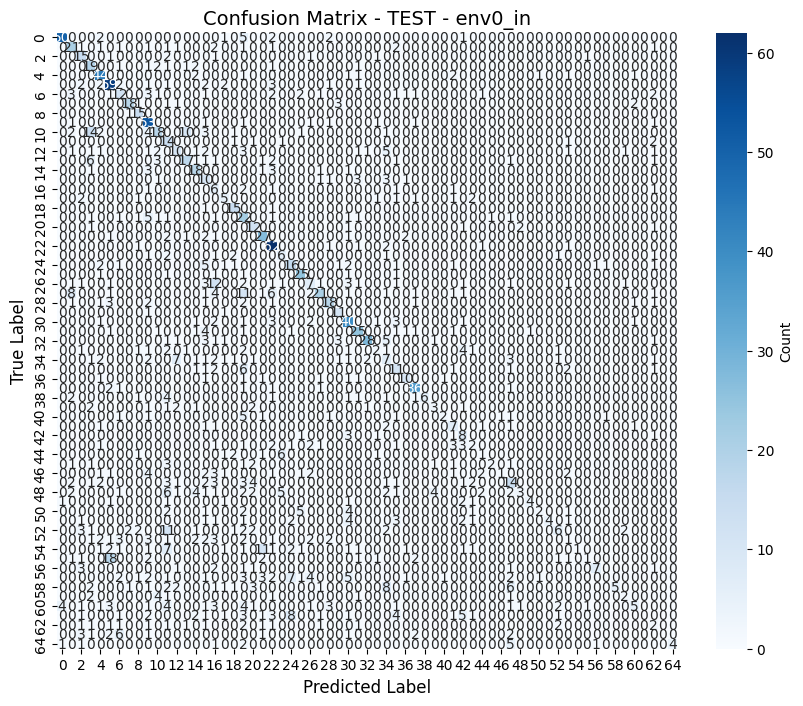


TRAIN - env1_in:
  Loss: 0.0472
  Accuracy: 0.9870, Precision: 0.9848, Recall: 0.9870, F1: 0.9856
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.png


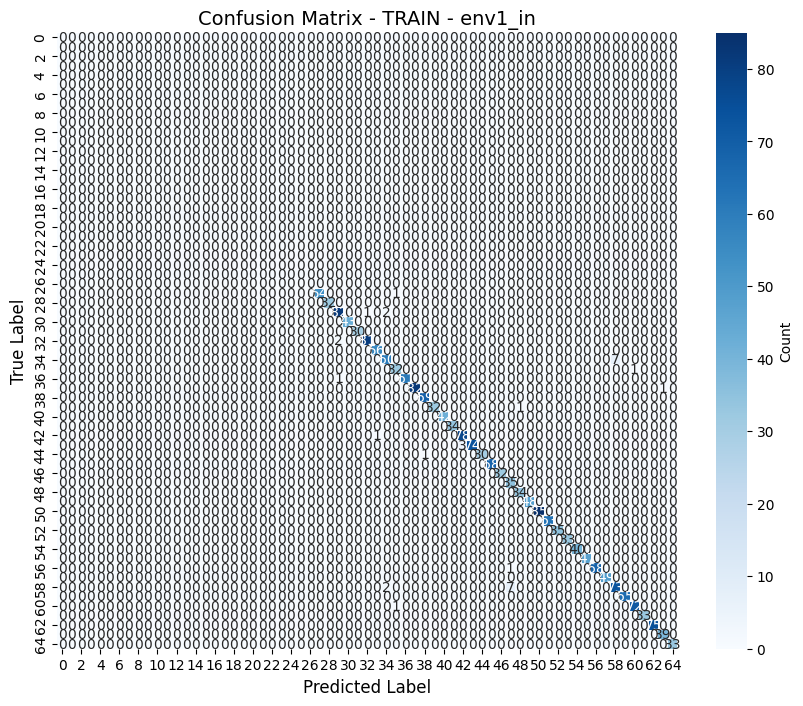

In [ ]:


fit_simple(
exp_dir=str(exp_dir),
logger=logger,
seed=config.get("seed", 0),
trial_seed=config.get("trial_seed", 0),
hparams_seed=config.get("hparams_seed", 0),
algorithm_name=config["algo"],
dataset_name=dataset_name,
data_dir=config["data_dir"][dataset_name],
num_workers=config.get("num_workers", 4),
test_envs=[config["test_set_id"]],
overlap_type=config.get("overlap", "none"),
holdout_fraction=config.get("holdout_fraction", 0.2),
n_steps=config.get("n_epochs"),  # Changed to epochs!
checkpoint_freq=config.get("checkpoint_freq"),  # In epochs
model_checkpoint=config.get("model_checkpoint", {
    "metric": "val/acc",
    "maximize": True
}),
num_domain_linked_classes=config.get("num_domain_linked_classes"),
num_classes=config.get("num_classes"),
# AutoAugmentation specific
auto_augment=config.get("auto_augment", False),
augment_search_epochs=config.get("augment_search_epochs", 10),
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_oh.csv'}")
print(f"  Best model: {exp_dir / 'best_model_oh.ckpt'}")
print(f"  Config: {exp_dir / 'config_oh.json'}")

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_oh}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# Display training curves
print("\n\nTRAINING CURVES:")
print("="*60)
display(Image(filename=os.path.join(log_dir, 'training_curves_OfficeHome.png')))




## PACS

In [22]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_pacs = input()
config["name"] = exp_name_pacs

exp_name_pacs = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_pacs
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_pacs}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)## VLCS

 third_experiment


In [23]:
dataset_name_pacs = config["dataset"][0]
dataset_name_pacs

'PACS'

Seed set to 0


/kaggle/input/pacs-dataset/kfold
num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2, 3], [2, 3, 4, 5], [4, 5, 6, 0]]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 39.8MB/s]


Model checkpoint frequency: 300


  0%|          | 0/5001 [00:42<?, ?it/s]

...


=== Step 4500 (Epoch 212.39) ===
step_time: 38.8774s
TRAIN: loss=0.6547, acc=0.9328, precision=0.9330, recall=0.9328, f1=0.9329
VAL: loss=0.1111, acc=0.9112, precision=0.9129, recall=0.9112, f1=0.9119
TEST: loss=3.1625, acc=0.6011, precision=0.7880, recall=0.6011, f1=0.5620
OTHER: loss=3.5046, acc=0.6294, precision=0.6414, recall=0.6294, f1=0.5851


 96%|█████████▌| 4801/5001 [43:57<40:00, 12.00s/it]  


=== Step 4800 (Epoch 226.55) ===
step_time: 39.0158s
TRAIN: loss=0.6659, acc=0.9990, precision=0.9992, recall=0.9990, f1=0.9991
VAL: loss=0.1417, acc=0.9672, precision=0.9690, recall=0.9672, f1=0.9678
TEST: loss=2.4453, acc=0.6542, precision=0.7673, recall=0.6542, f1=0.6085
OTHER: loss=3.0362, acc=0.6542, precision=0.6177, recall=0.6542, f1=0.5929


100%|██████████| 5001/5001 [45:58<00:00,  1.81it/s]



=== Step 5000 (Epoch 235.99) ===
step_time: 38.6094s
TRAIN: loss=0.6588, acc=0.9995, precision=0.9996, recall=0.9995, f1=0.9996
VAL: loss=0.1293, acc=0.8552, precision=0.8575, recall=0.8552, f1=0.8558
TEST: loss=2.4925, acc=0.6220, precision=0.8033, recall=0.6220, f1=0.5928
OTHER: loss=3.0085, acc=0.6406, precision=0.7934, recall=0.6406, f1=0.5992

TRAINING COMPLETED
Total training time: 2758.79s (45.98 minutes)
Average time per epoch: 11.97s
Total epochs: 227


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 2.4675
  Accuracy: 0.6220, Precision: 0.8033, Recall: 0.6220, F1: 0.5928
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.png


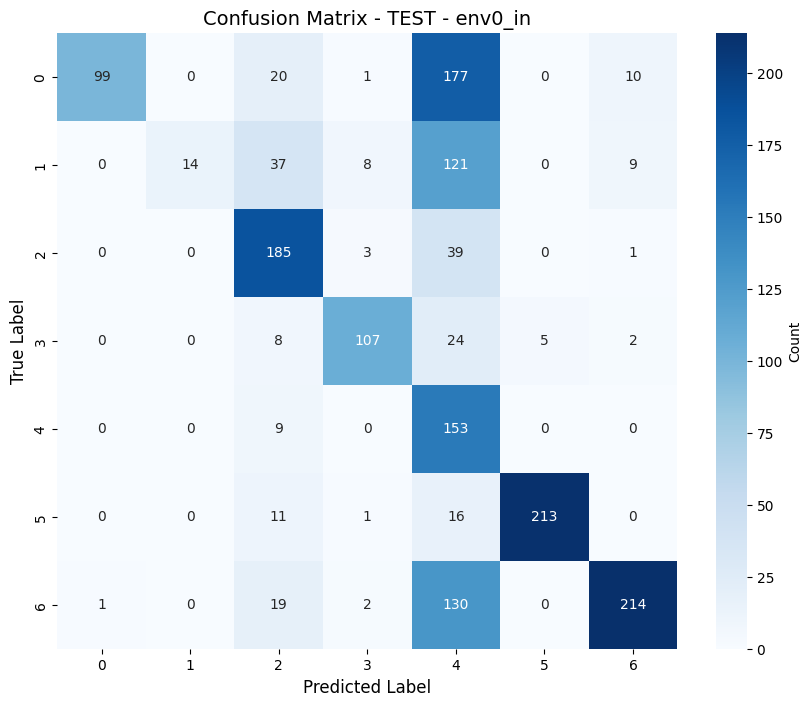


TRAIN - env1_in:
  Loss: 0.0024
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.png


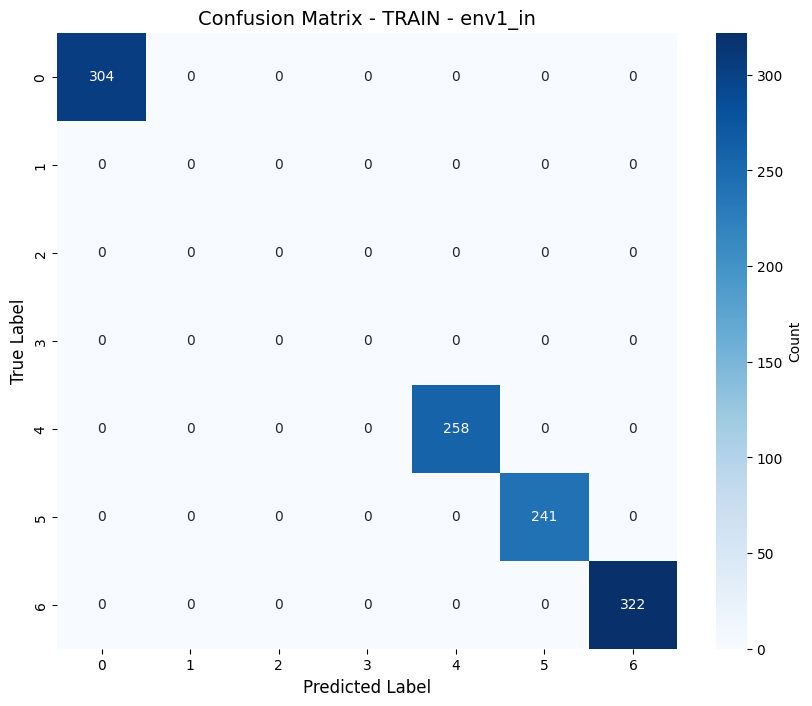


TRAIN - env2_in:
  Loss: 0.0000
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env2_in.png


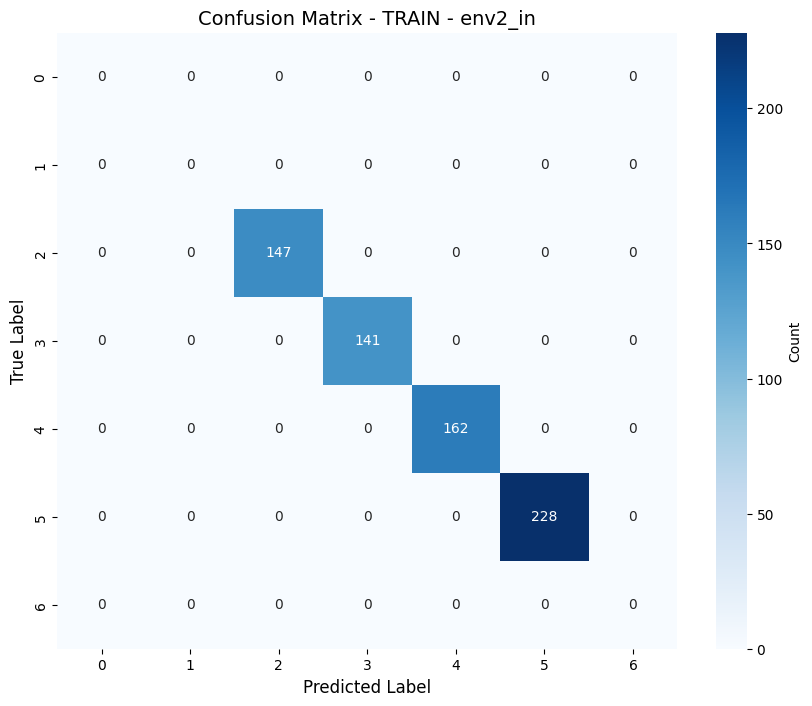


TRAIN - env3_in:
  Loss: 0.0012
  Accuracy: 0.9996, Precision: 0.9996, Recall: 0.9996, F1: 0.9996
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env3_in.png


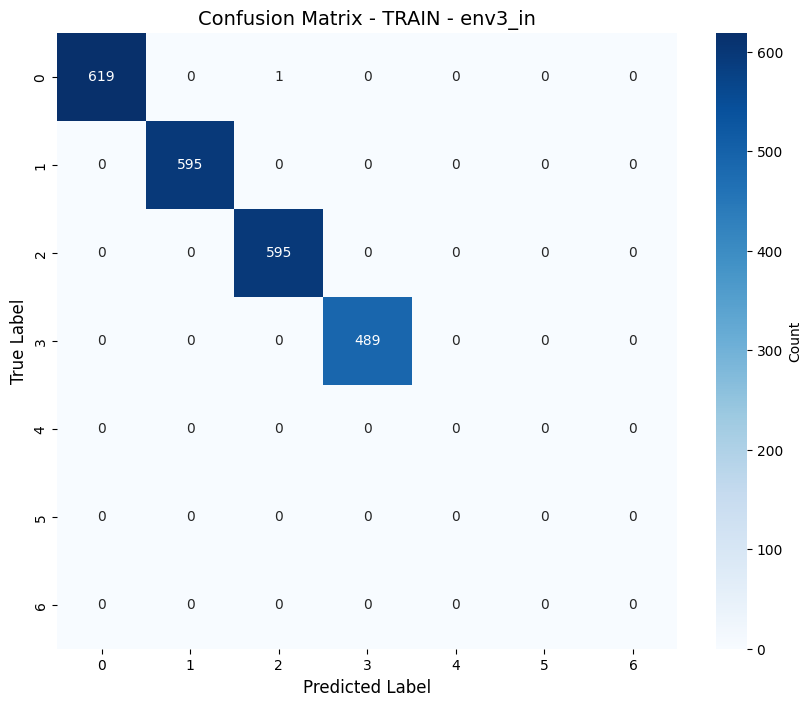


OTHER - env0_out:
  Loss: 2.9946
  Accuracy: 0.6406, Precision: 0.7934, Recall: 0.6406, F1: 0.5992
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_OTHER_env0_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_OTHER_env0_out.png


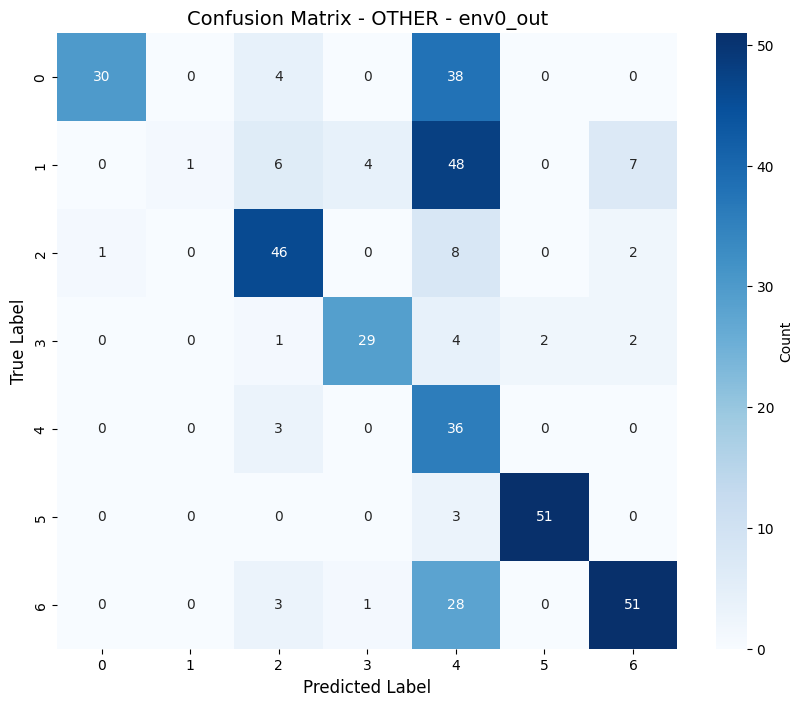


VAL - env1_out:
  Loss: 0.2022
  Accuracy: 0.6362, Precision: 0.6406, Recall: 0.6362, F1: 0.6381
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env1_out.png


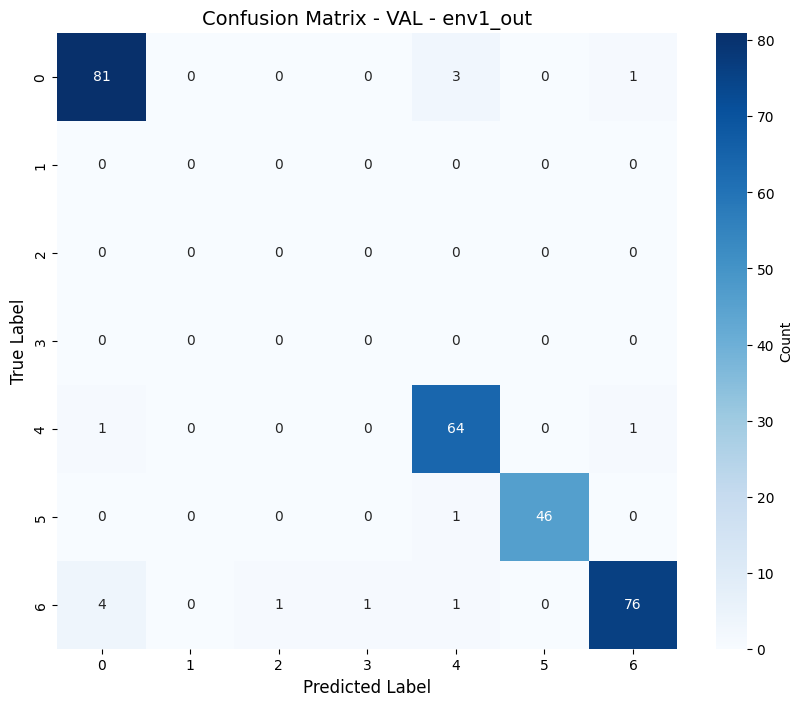


VAL - env2_out:
  Loss: 0.0318
  Accuracy: 0.9809, Precision: 0.9795, Recall: 0.9809, F1: 0.9800
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env2_out.png


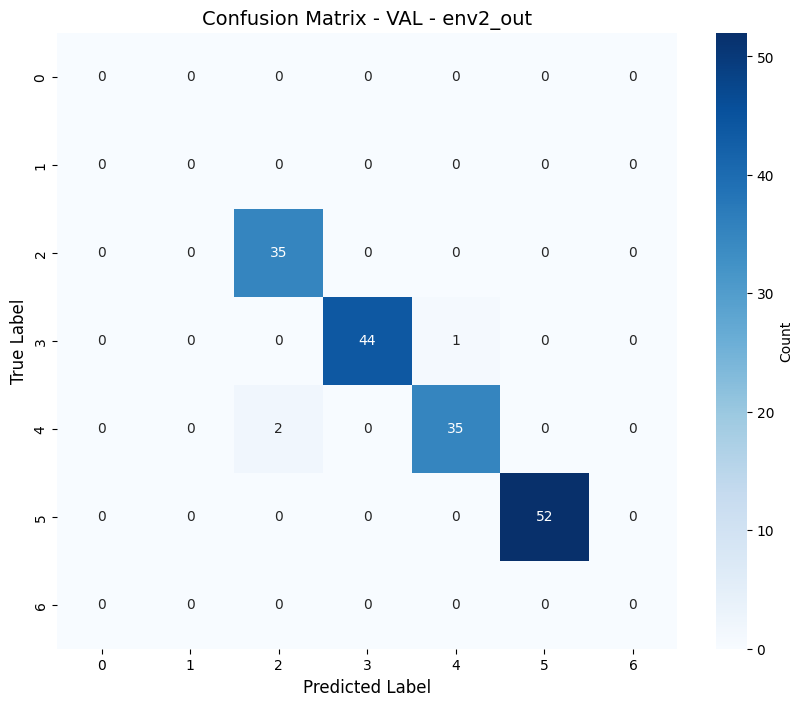


VAL - env3_out:
  Loss: 0.1133
  Accuracy: 0.9680, Precision: 0.9686, Recall: 0.9680, F1: 0.9682
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env3_out.png


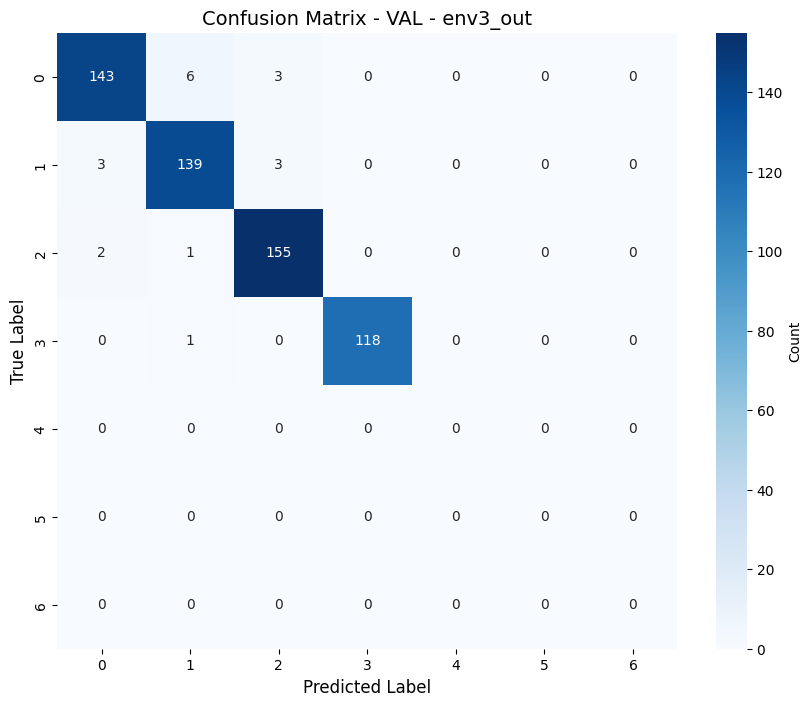


Training curves saved to: /kaggle/working/experiments/third_experiment/logs/training_curves_PACS.png


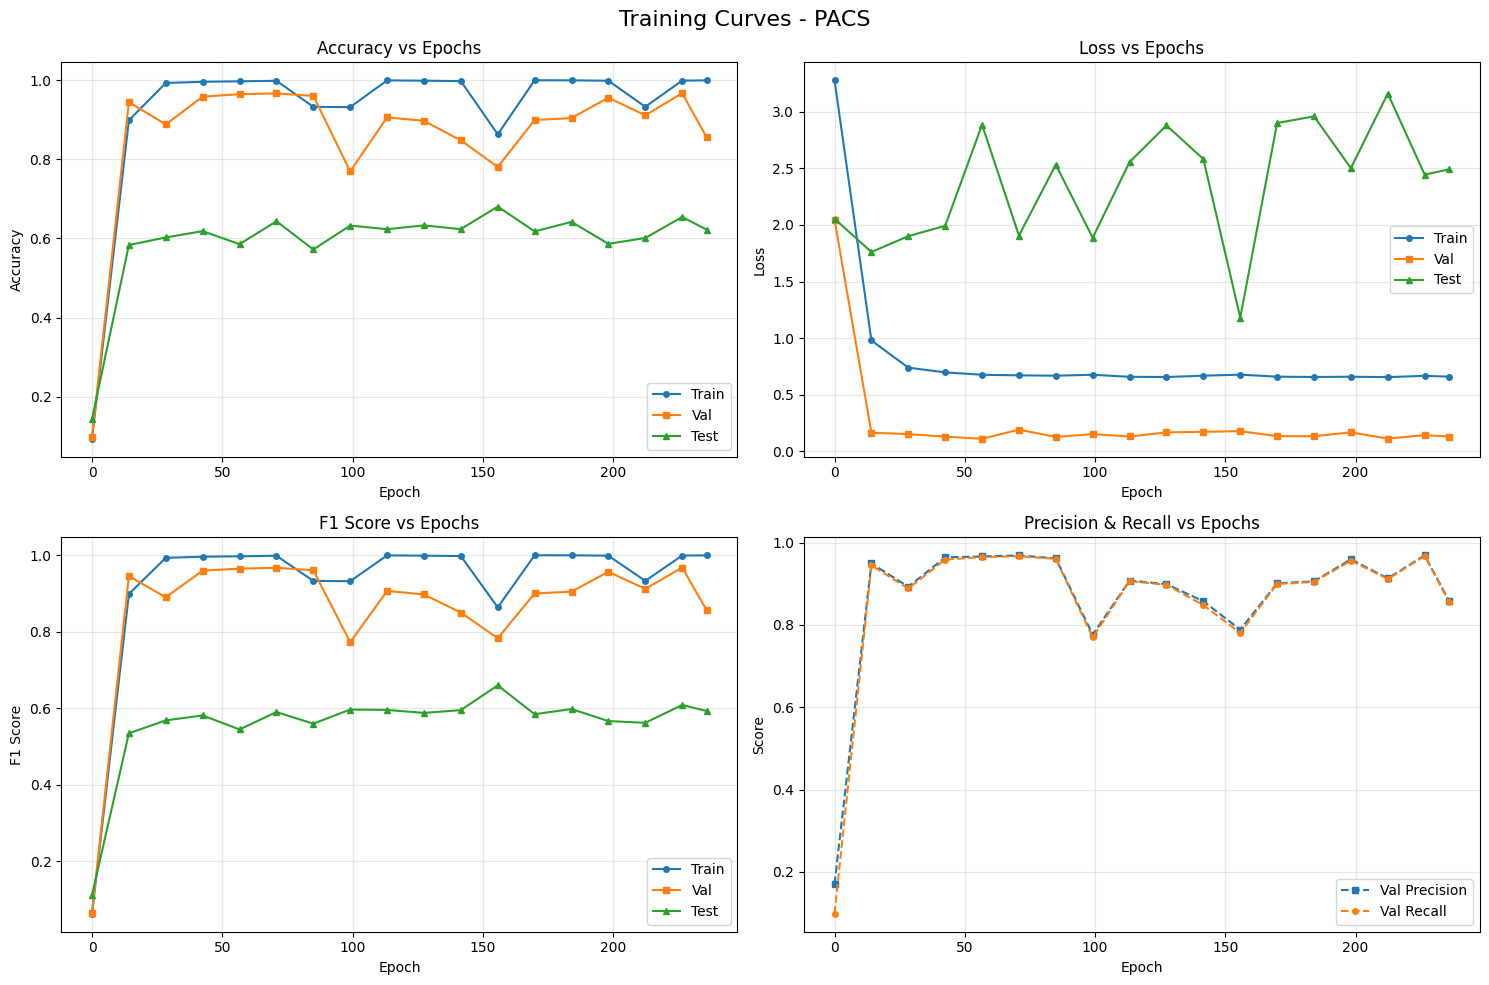

Epoch time plot saved to: /kaggle/working/experiments/third_experiment/logs/epoch_times_PACS.png


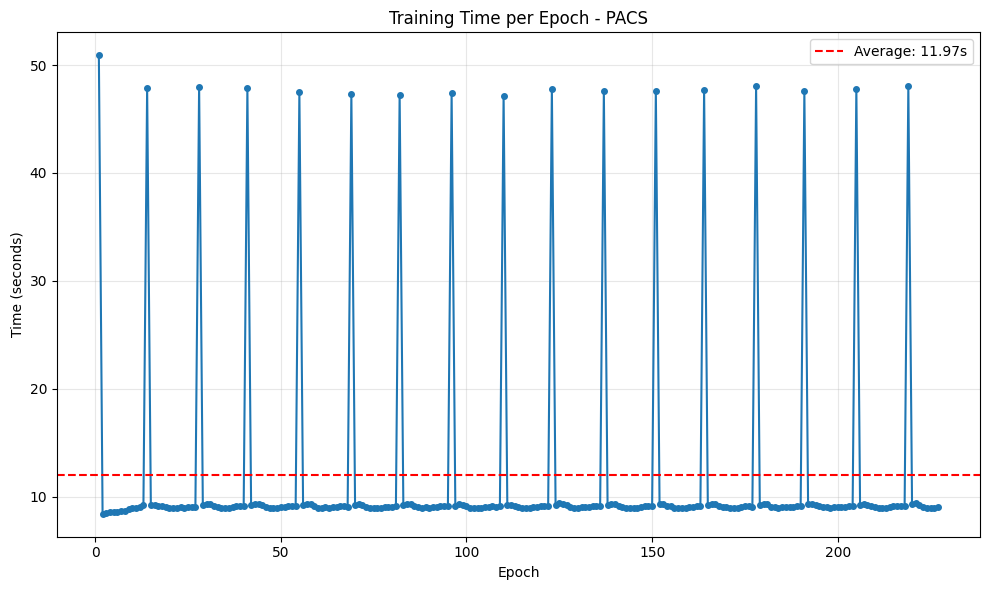


All results saved to: /kaggle/working/experiments/third_experiment/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_PACS.png
  - epoch_times_PACS.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)

✓ Experiment complete!
  Results: /kaggle/working/experiments/third_experiment/metrics_pacs.csv
  Best model: /kaggle/working/experiments/third_experiment/best_model_pacs.ckpt
  Config: /kaggle/working/experiments/third_experiment/config_pacs.json
CONFUSION MATRICES:

confusion_matrix_OTHER_env0_out.png


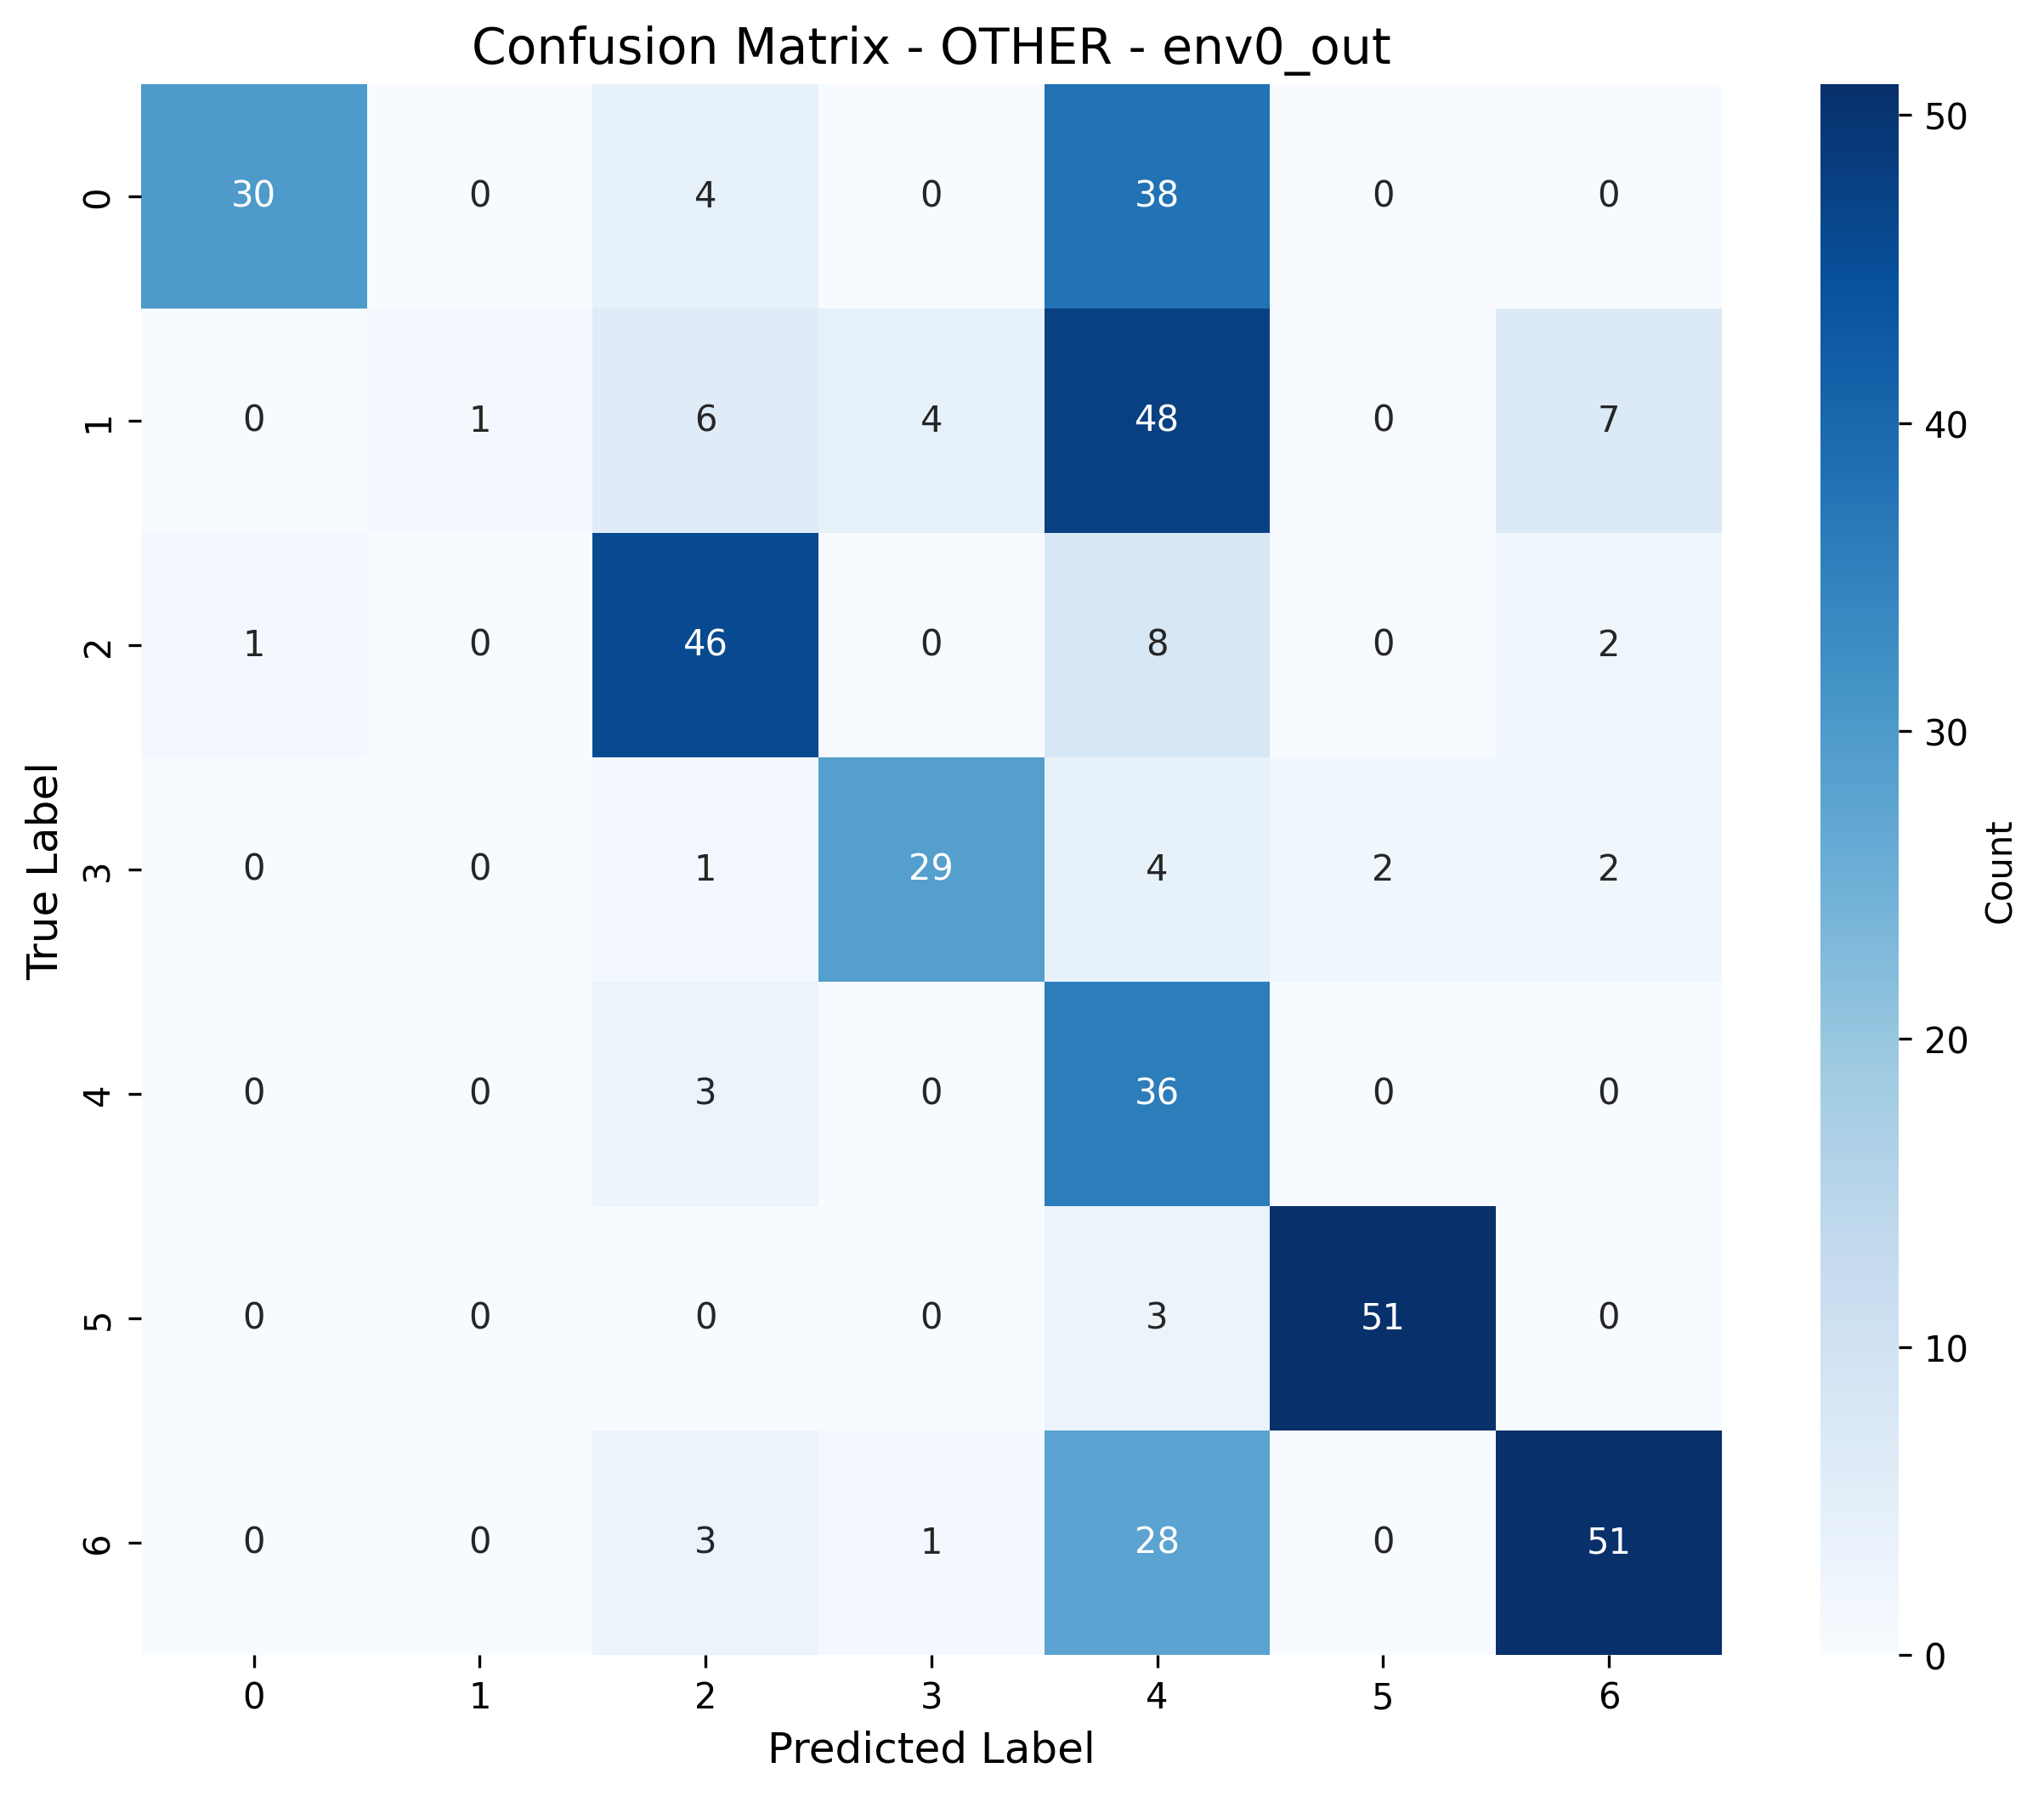


confusion_matrix_TEST_env0_in.png


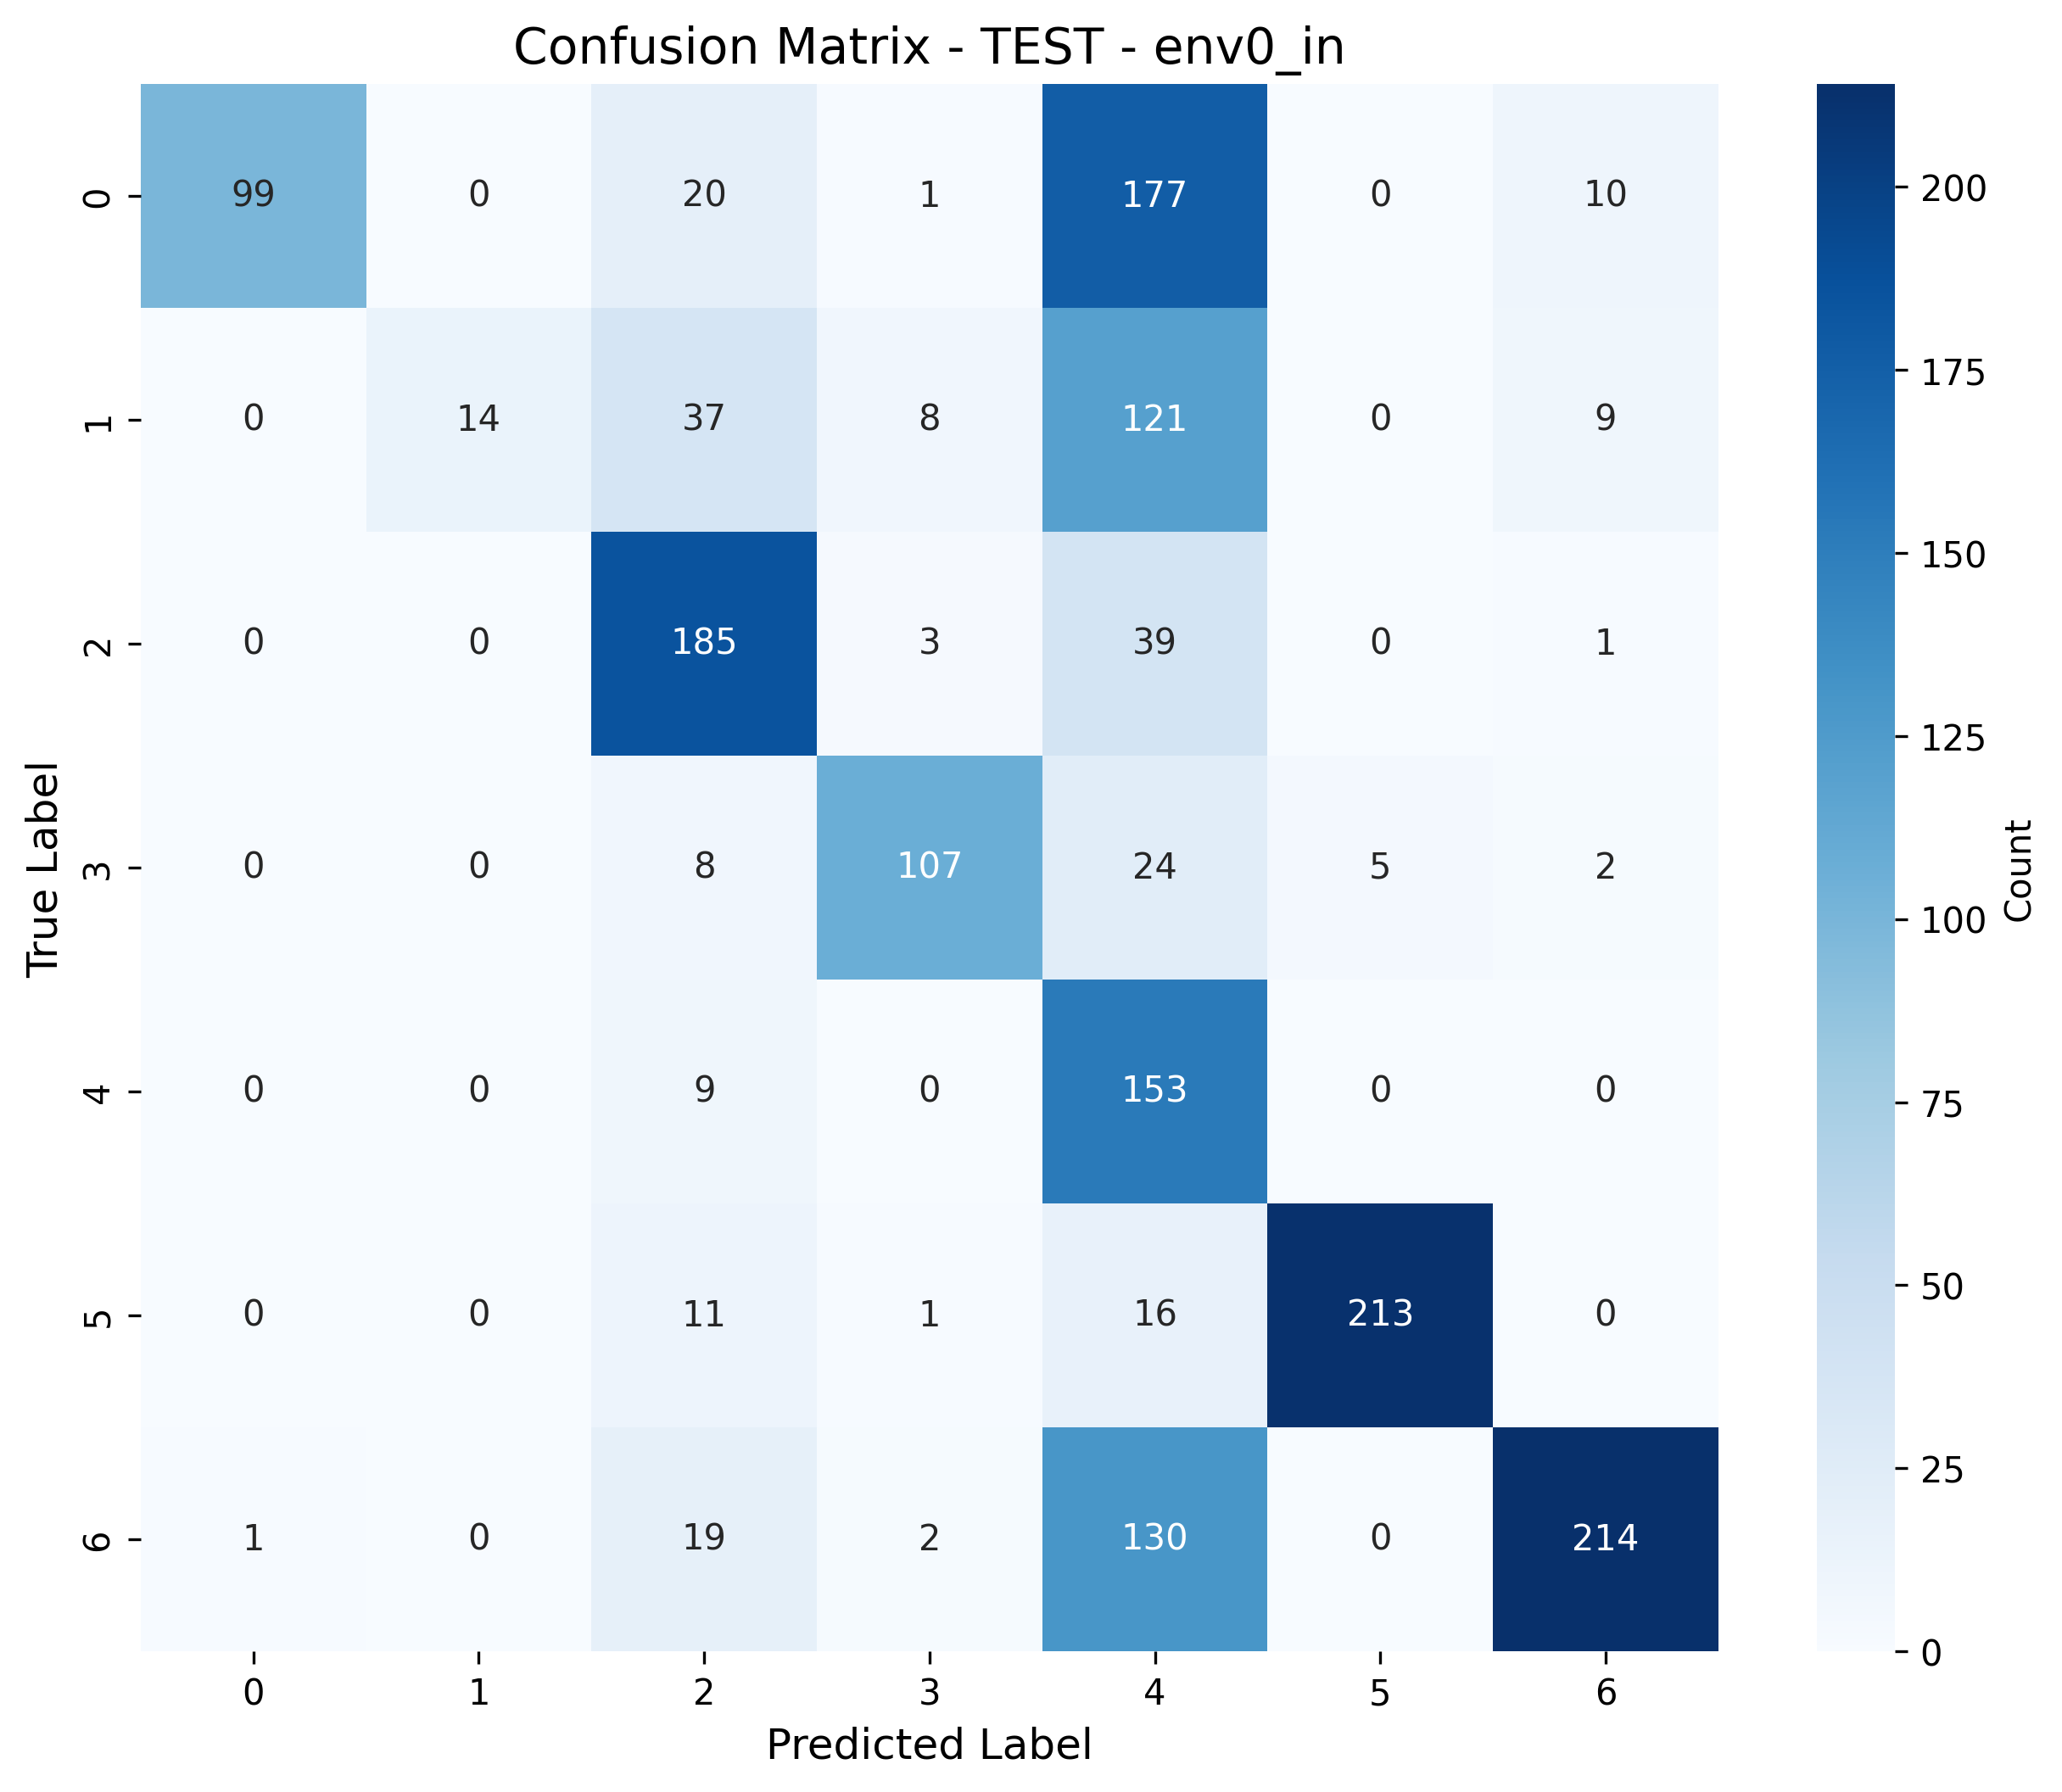


confusion_matrix_TRAIN_env1_in.png


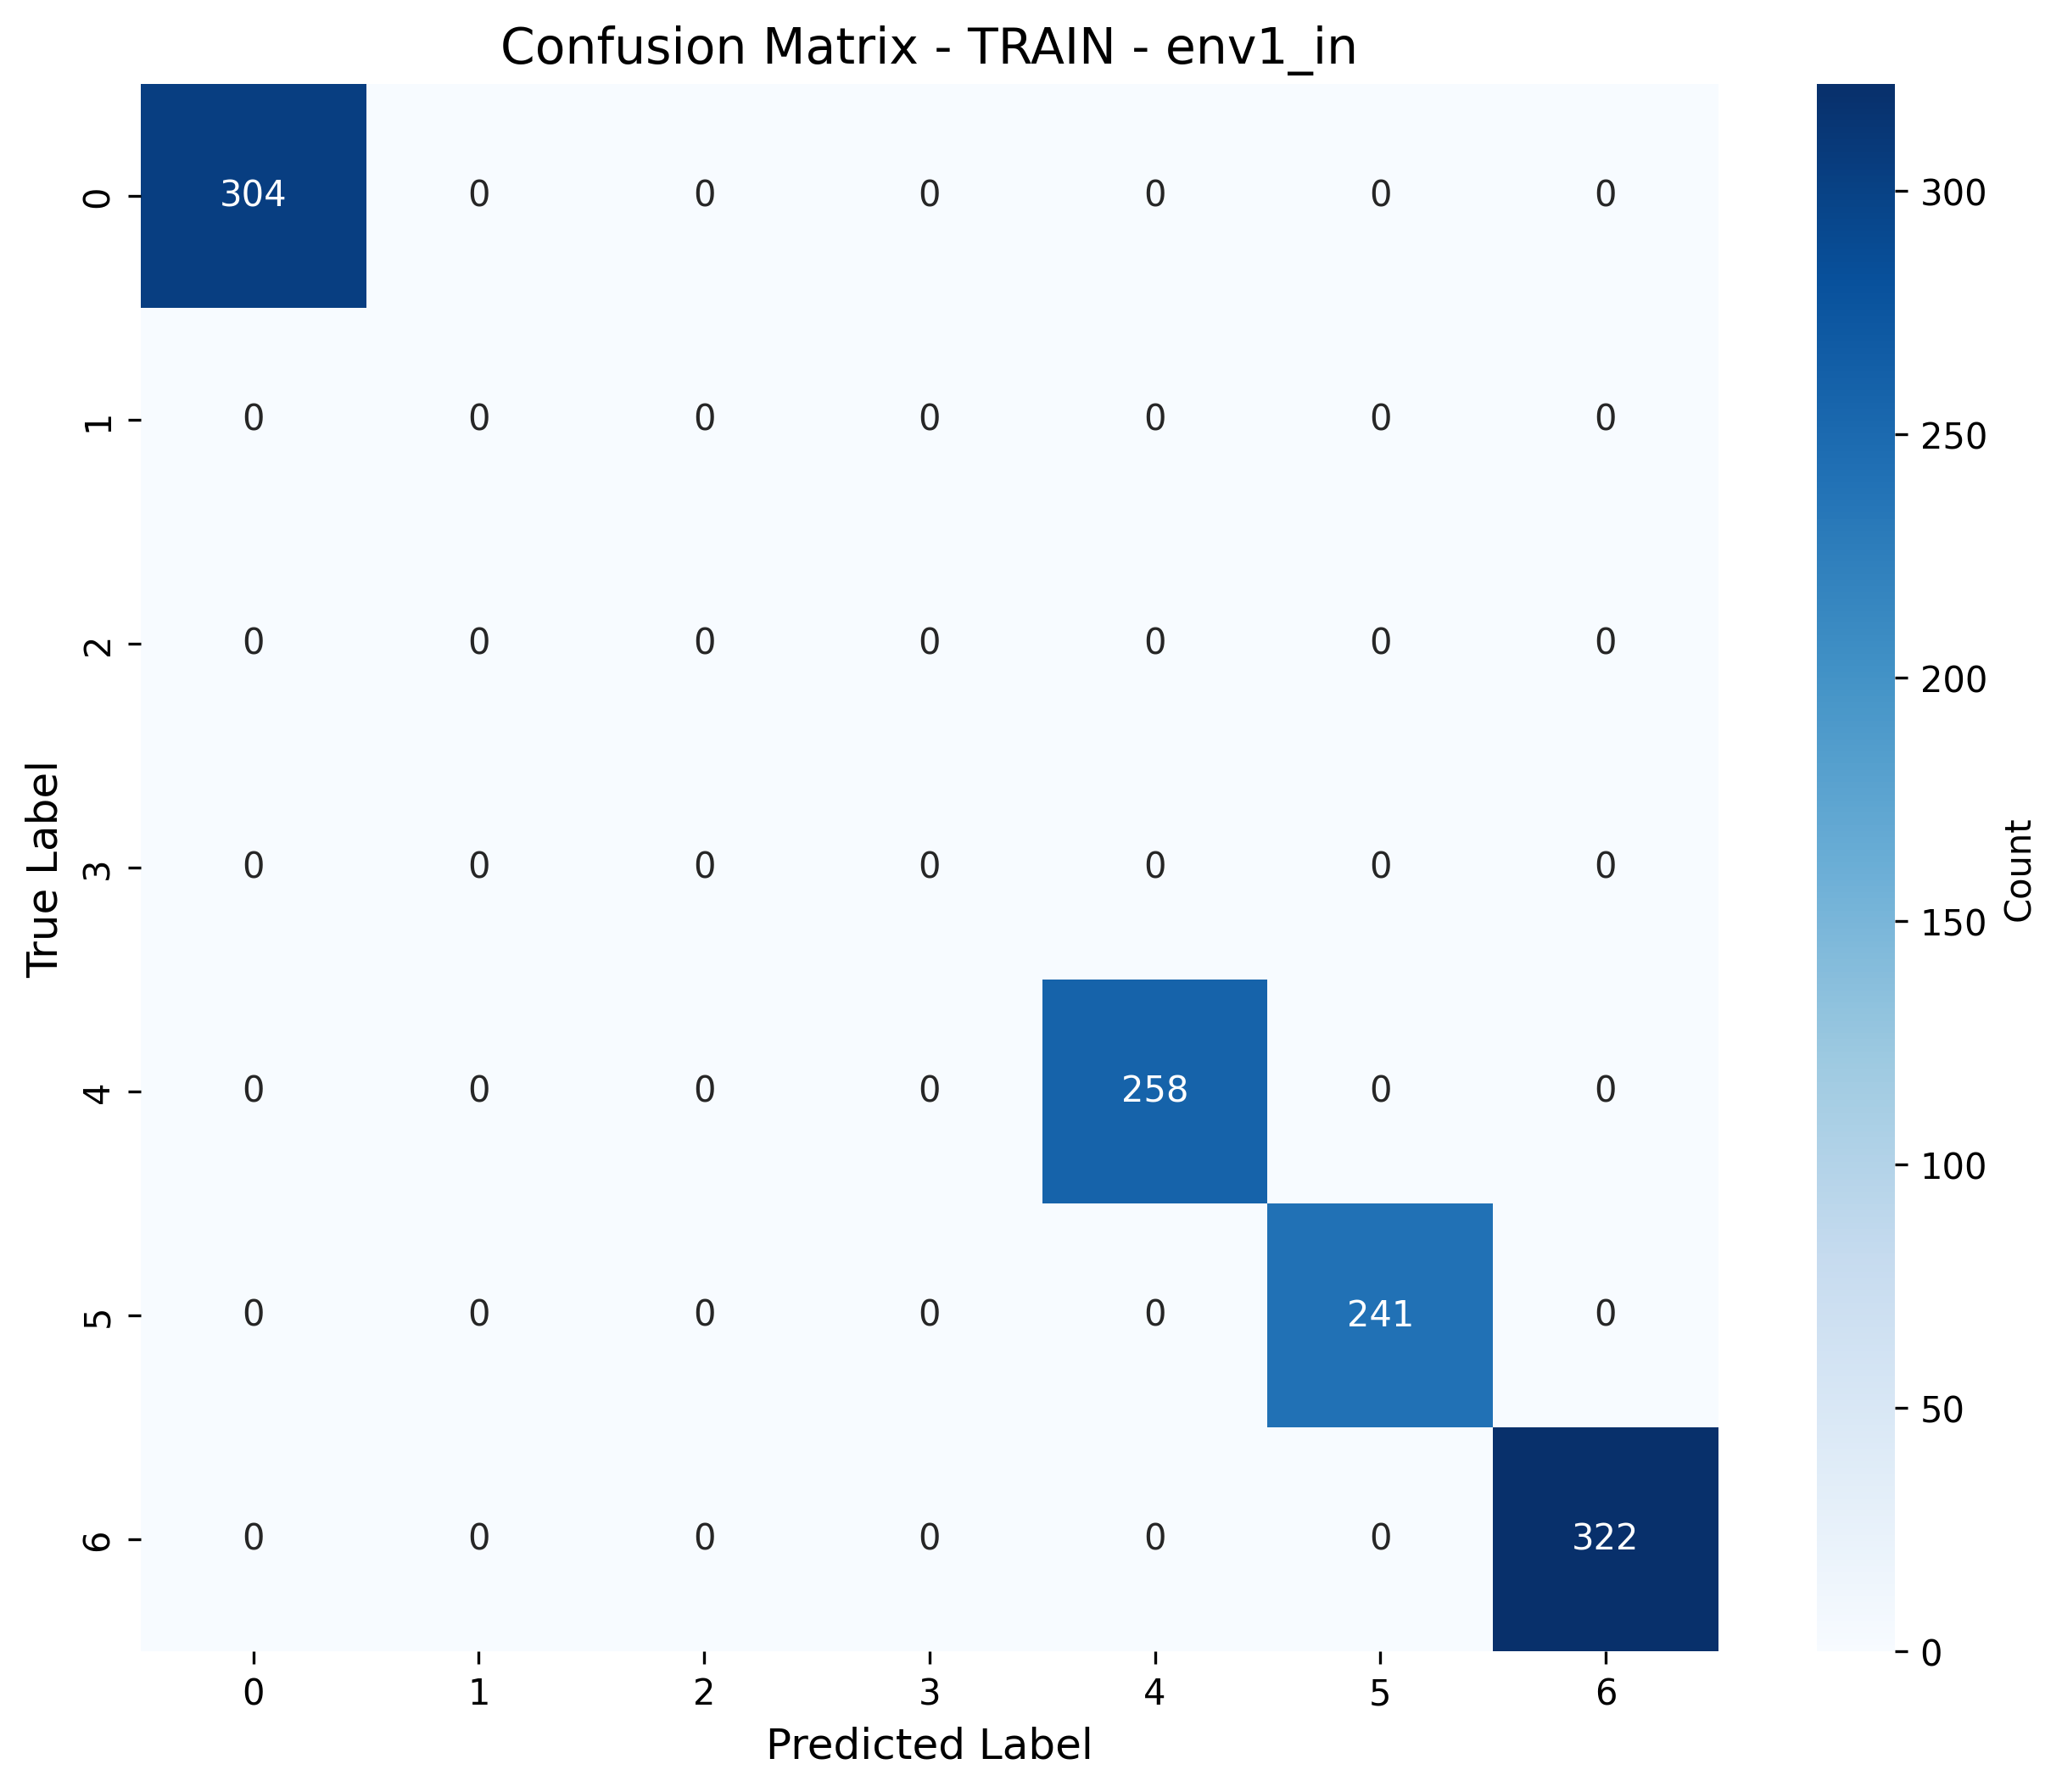


confusion_matrix_TRAIN_env2_in.png


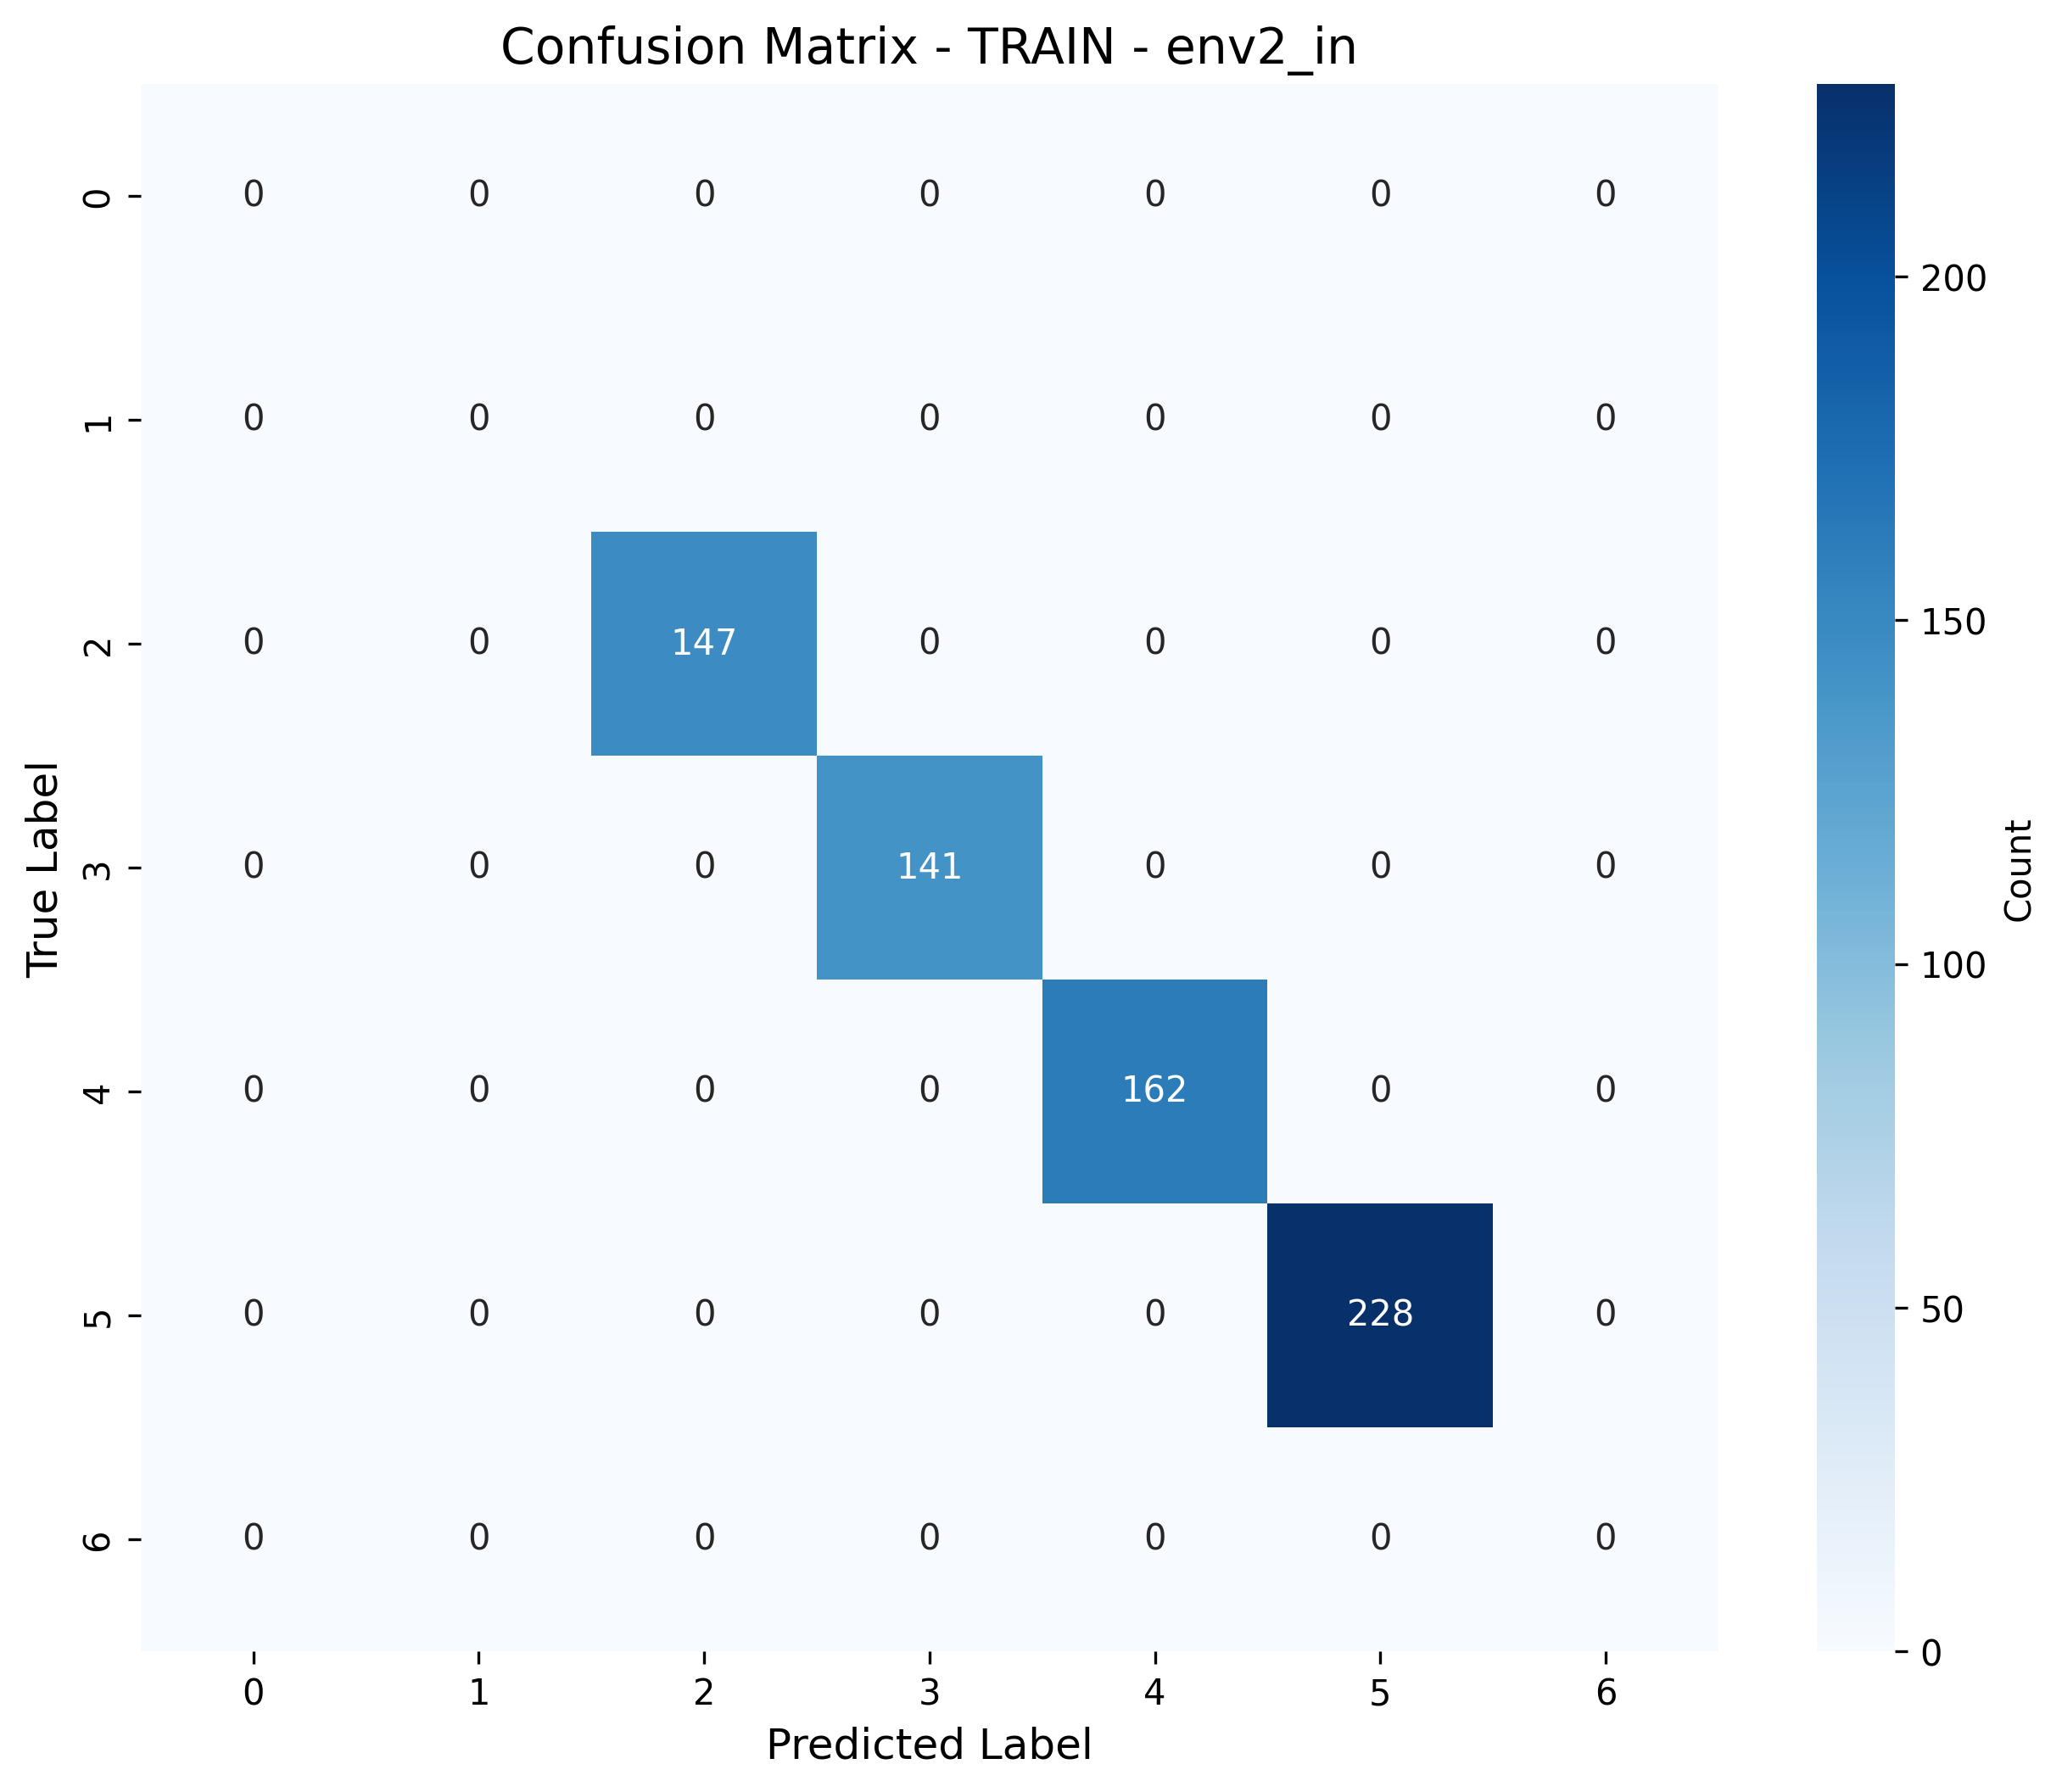


confusion_matrix_TRAIN_env3_in.png


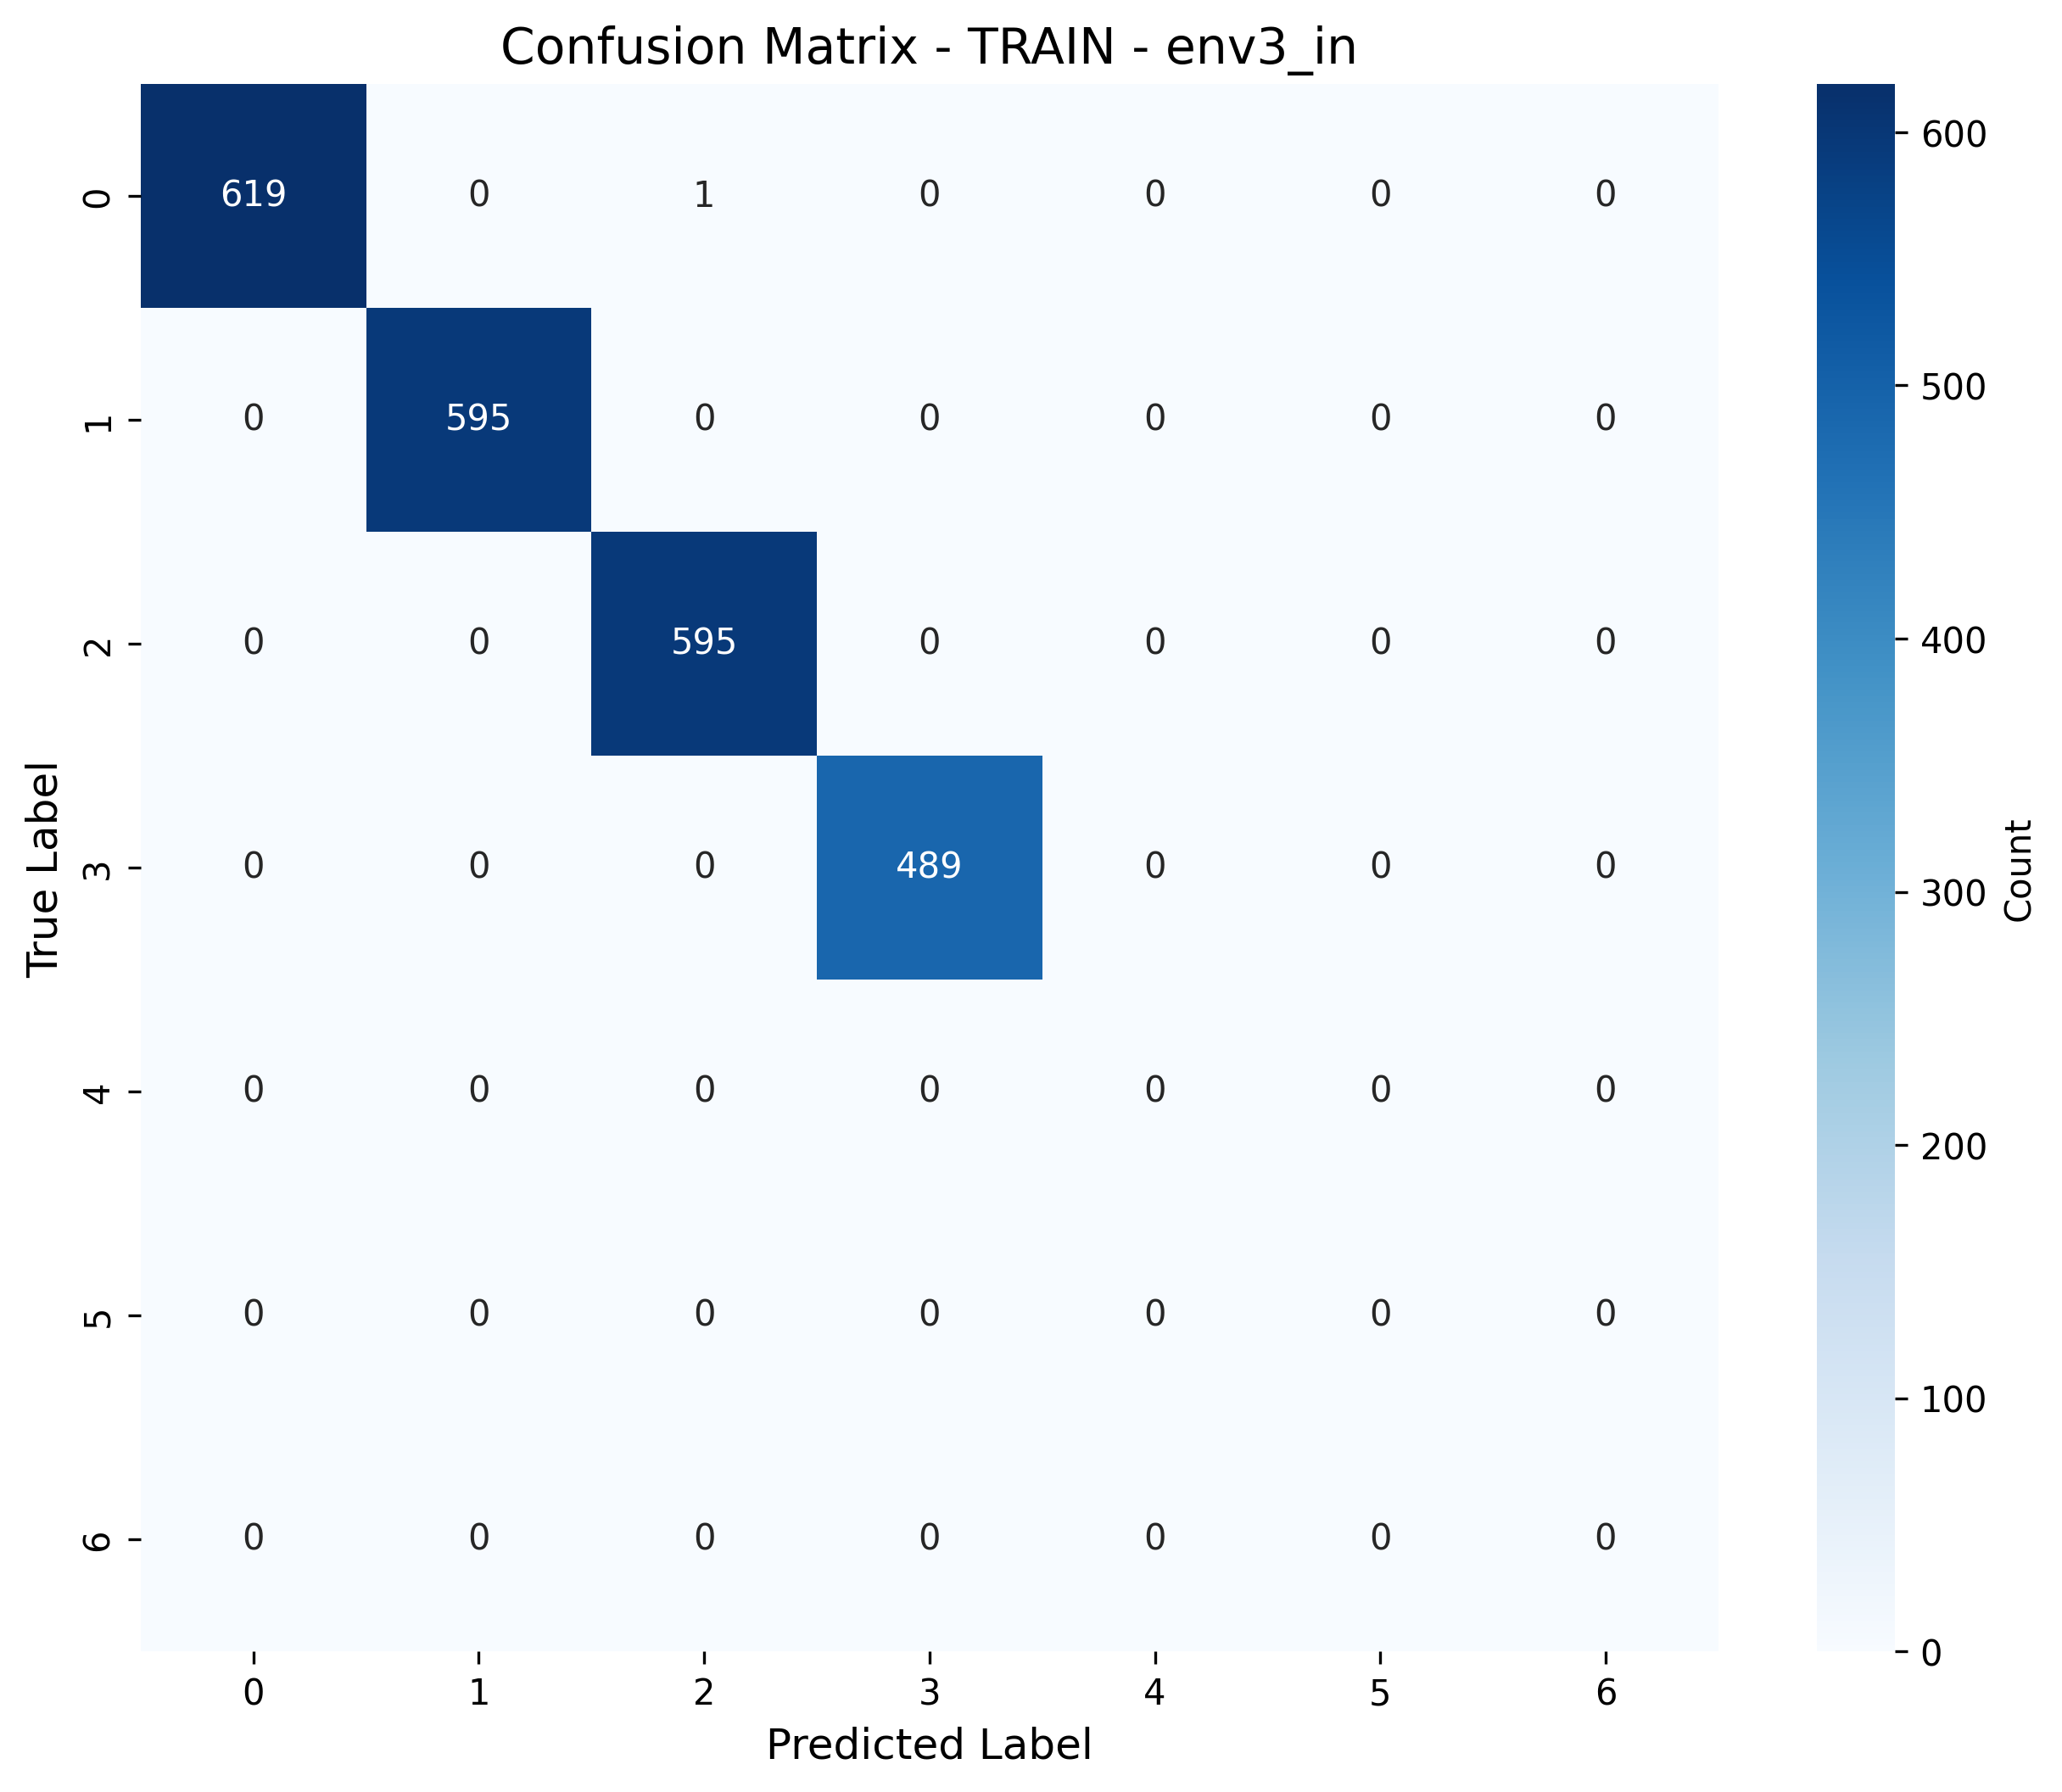


confusion_matrix_VAL_env1_out.png


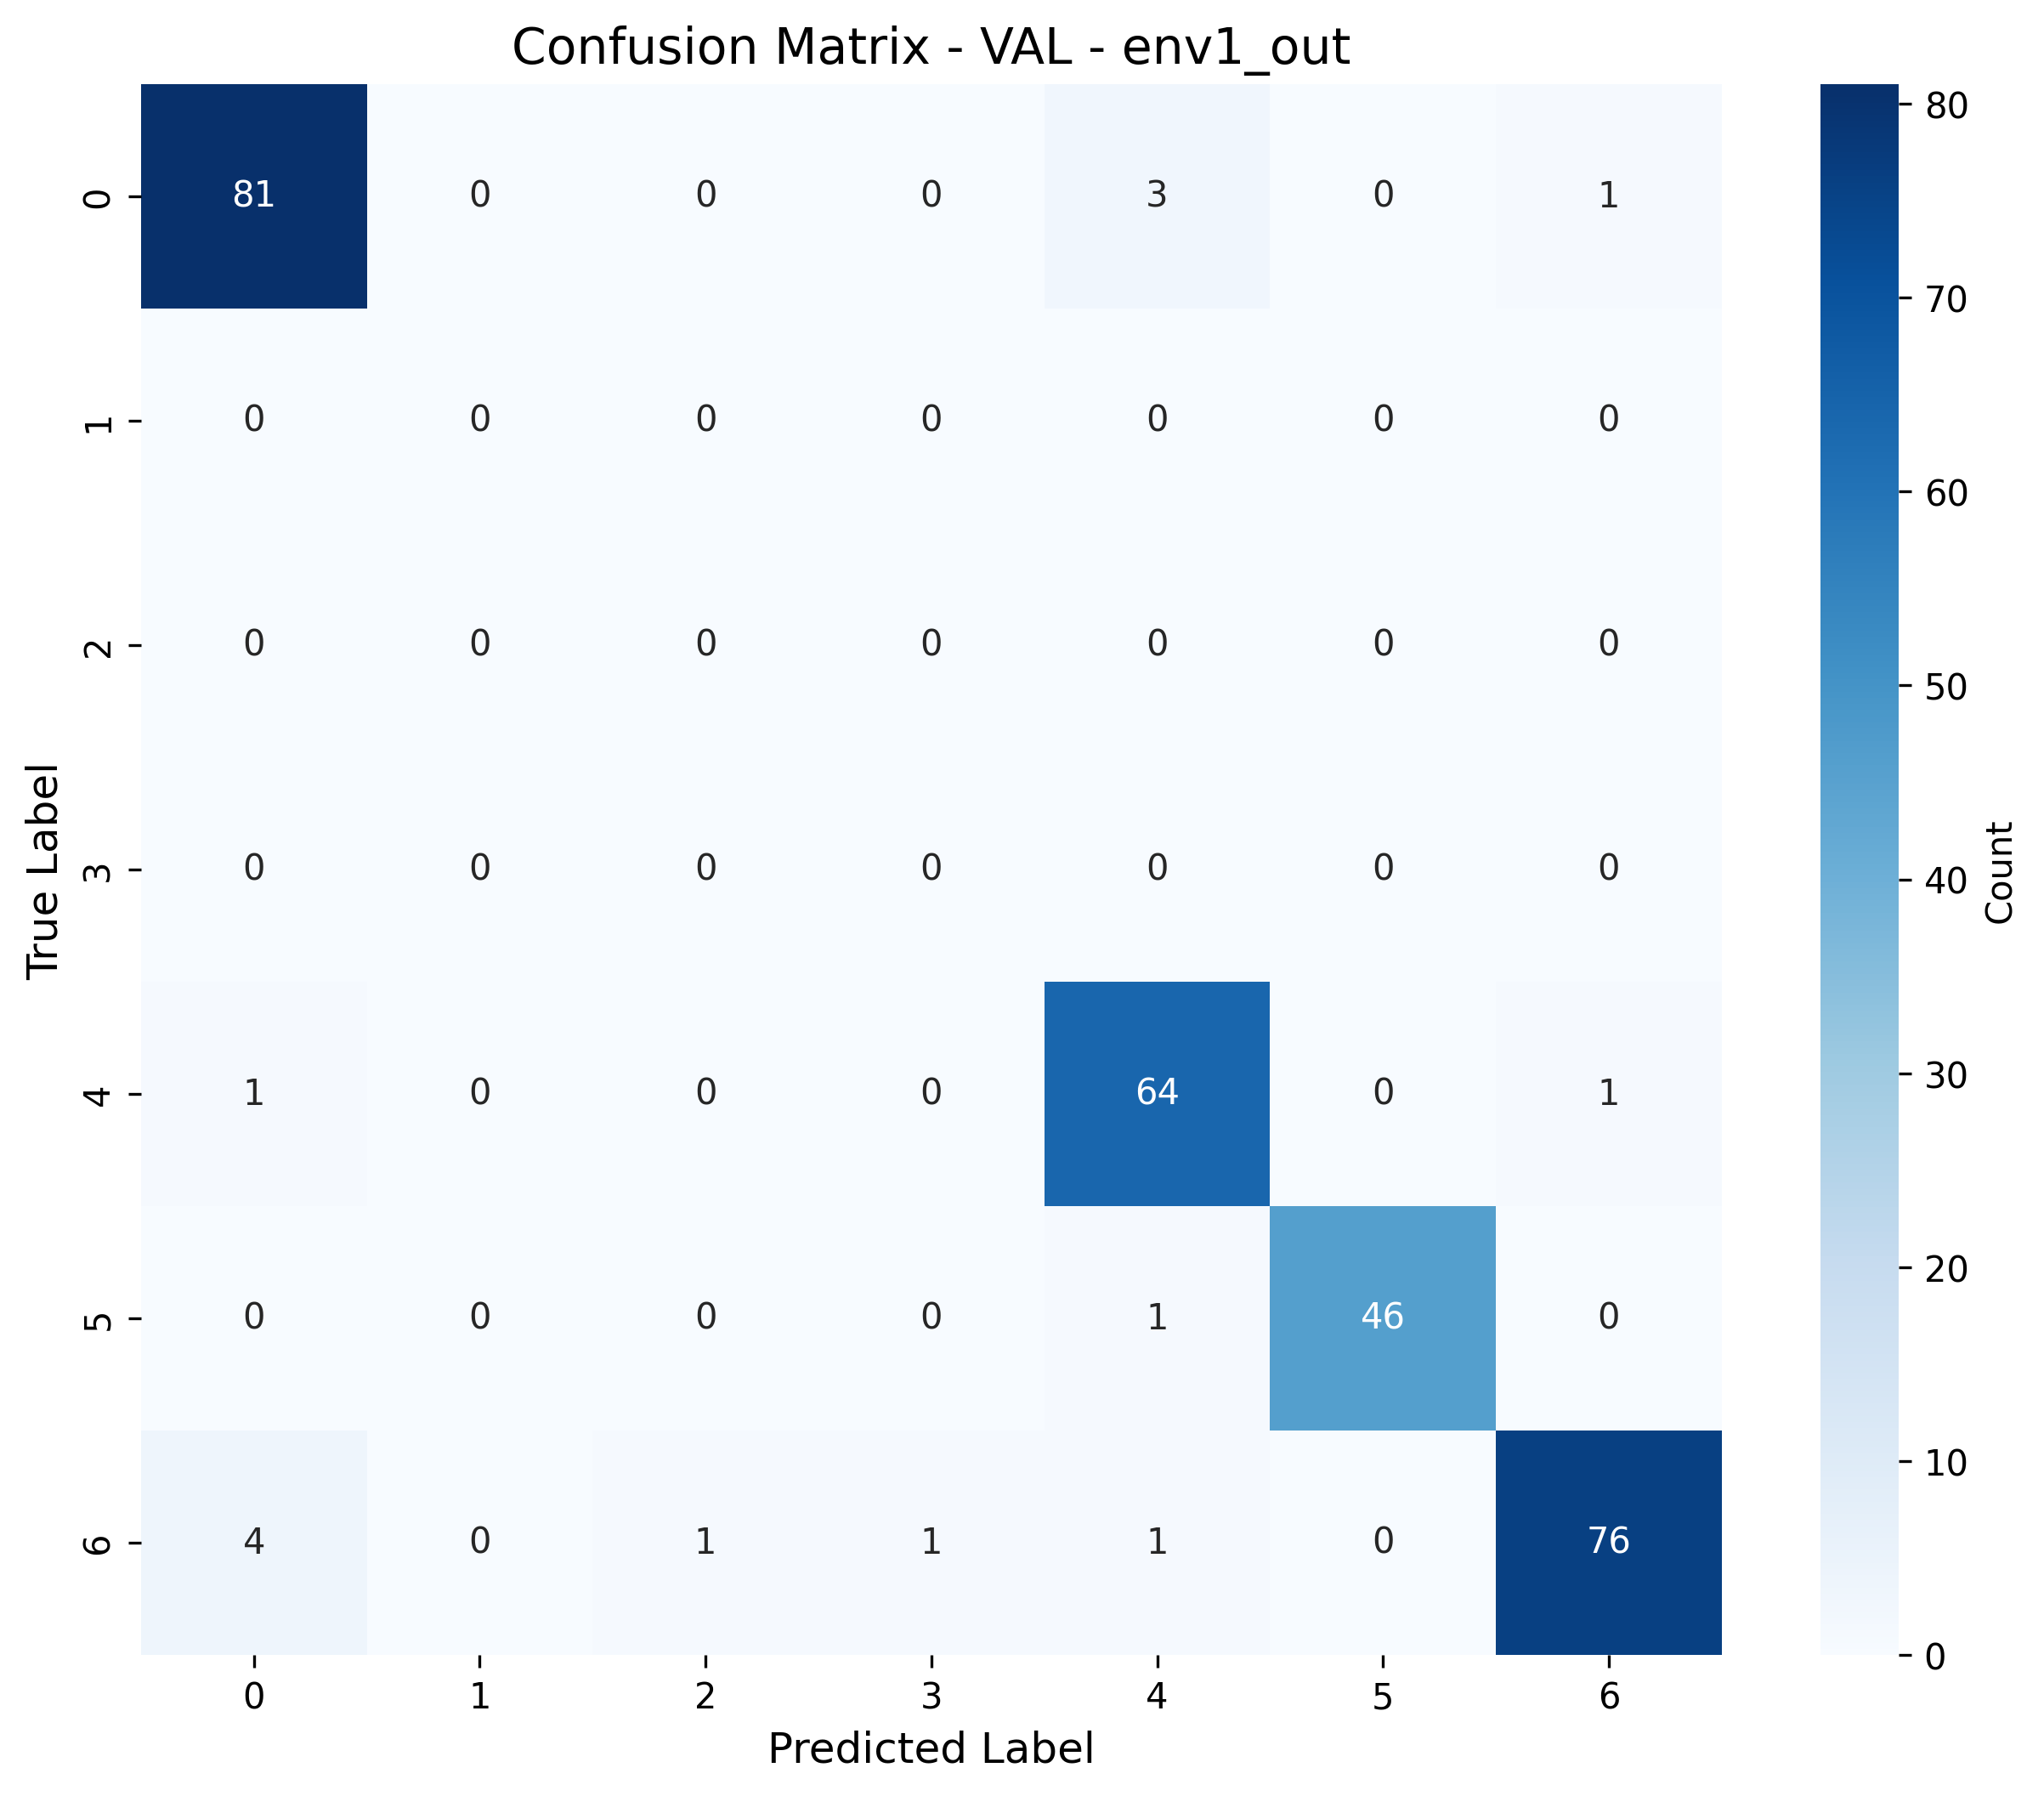


confusion_matrix_VAL_env2_out.png


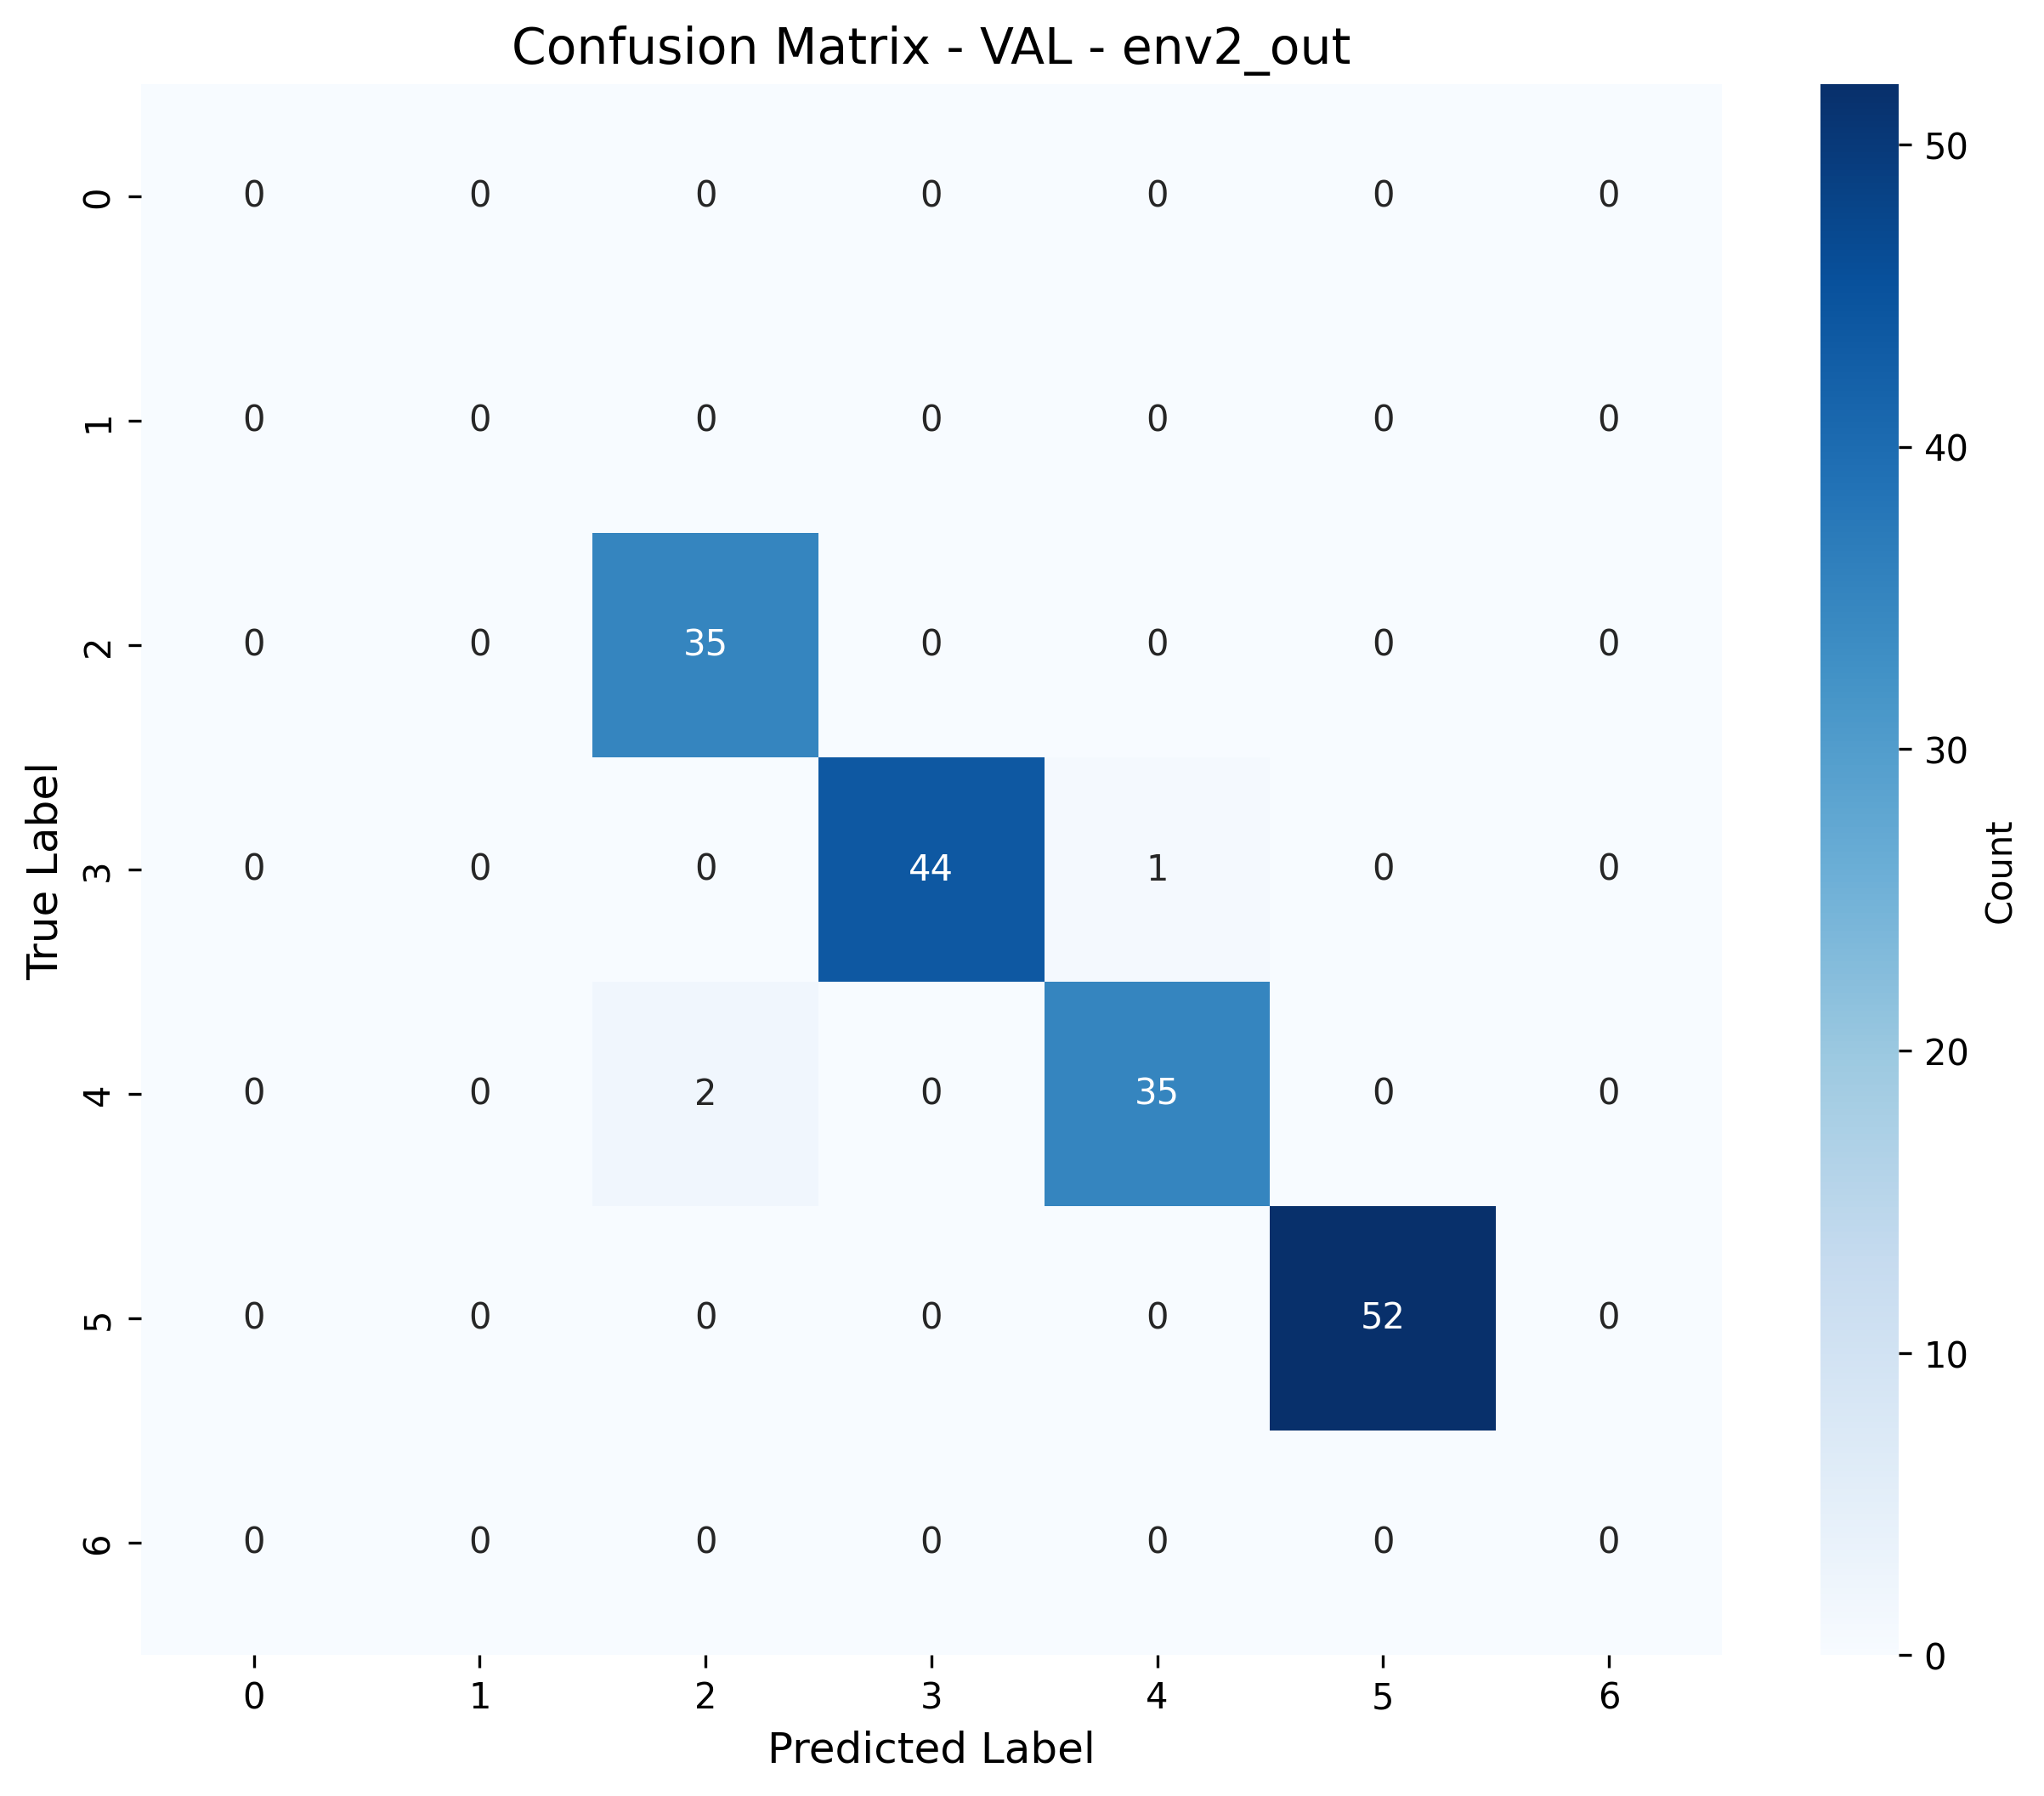


confusion_matrix_VAL_env3_out.png


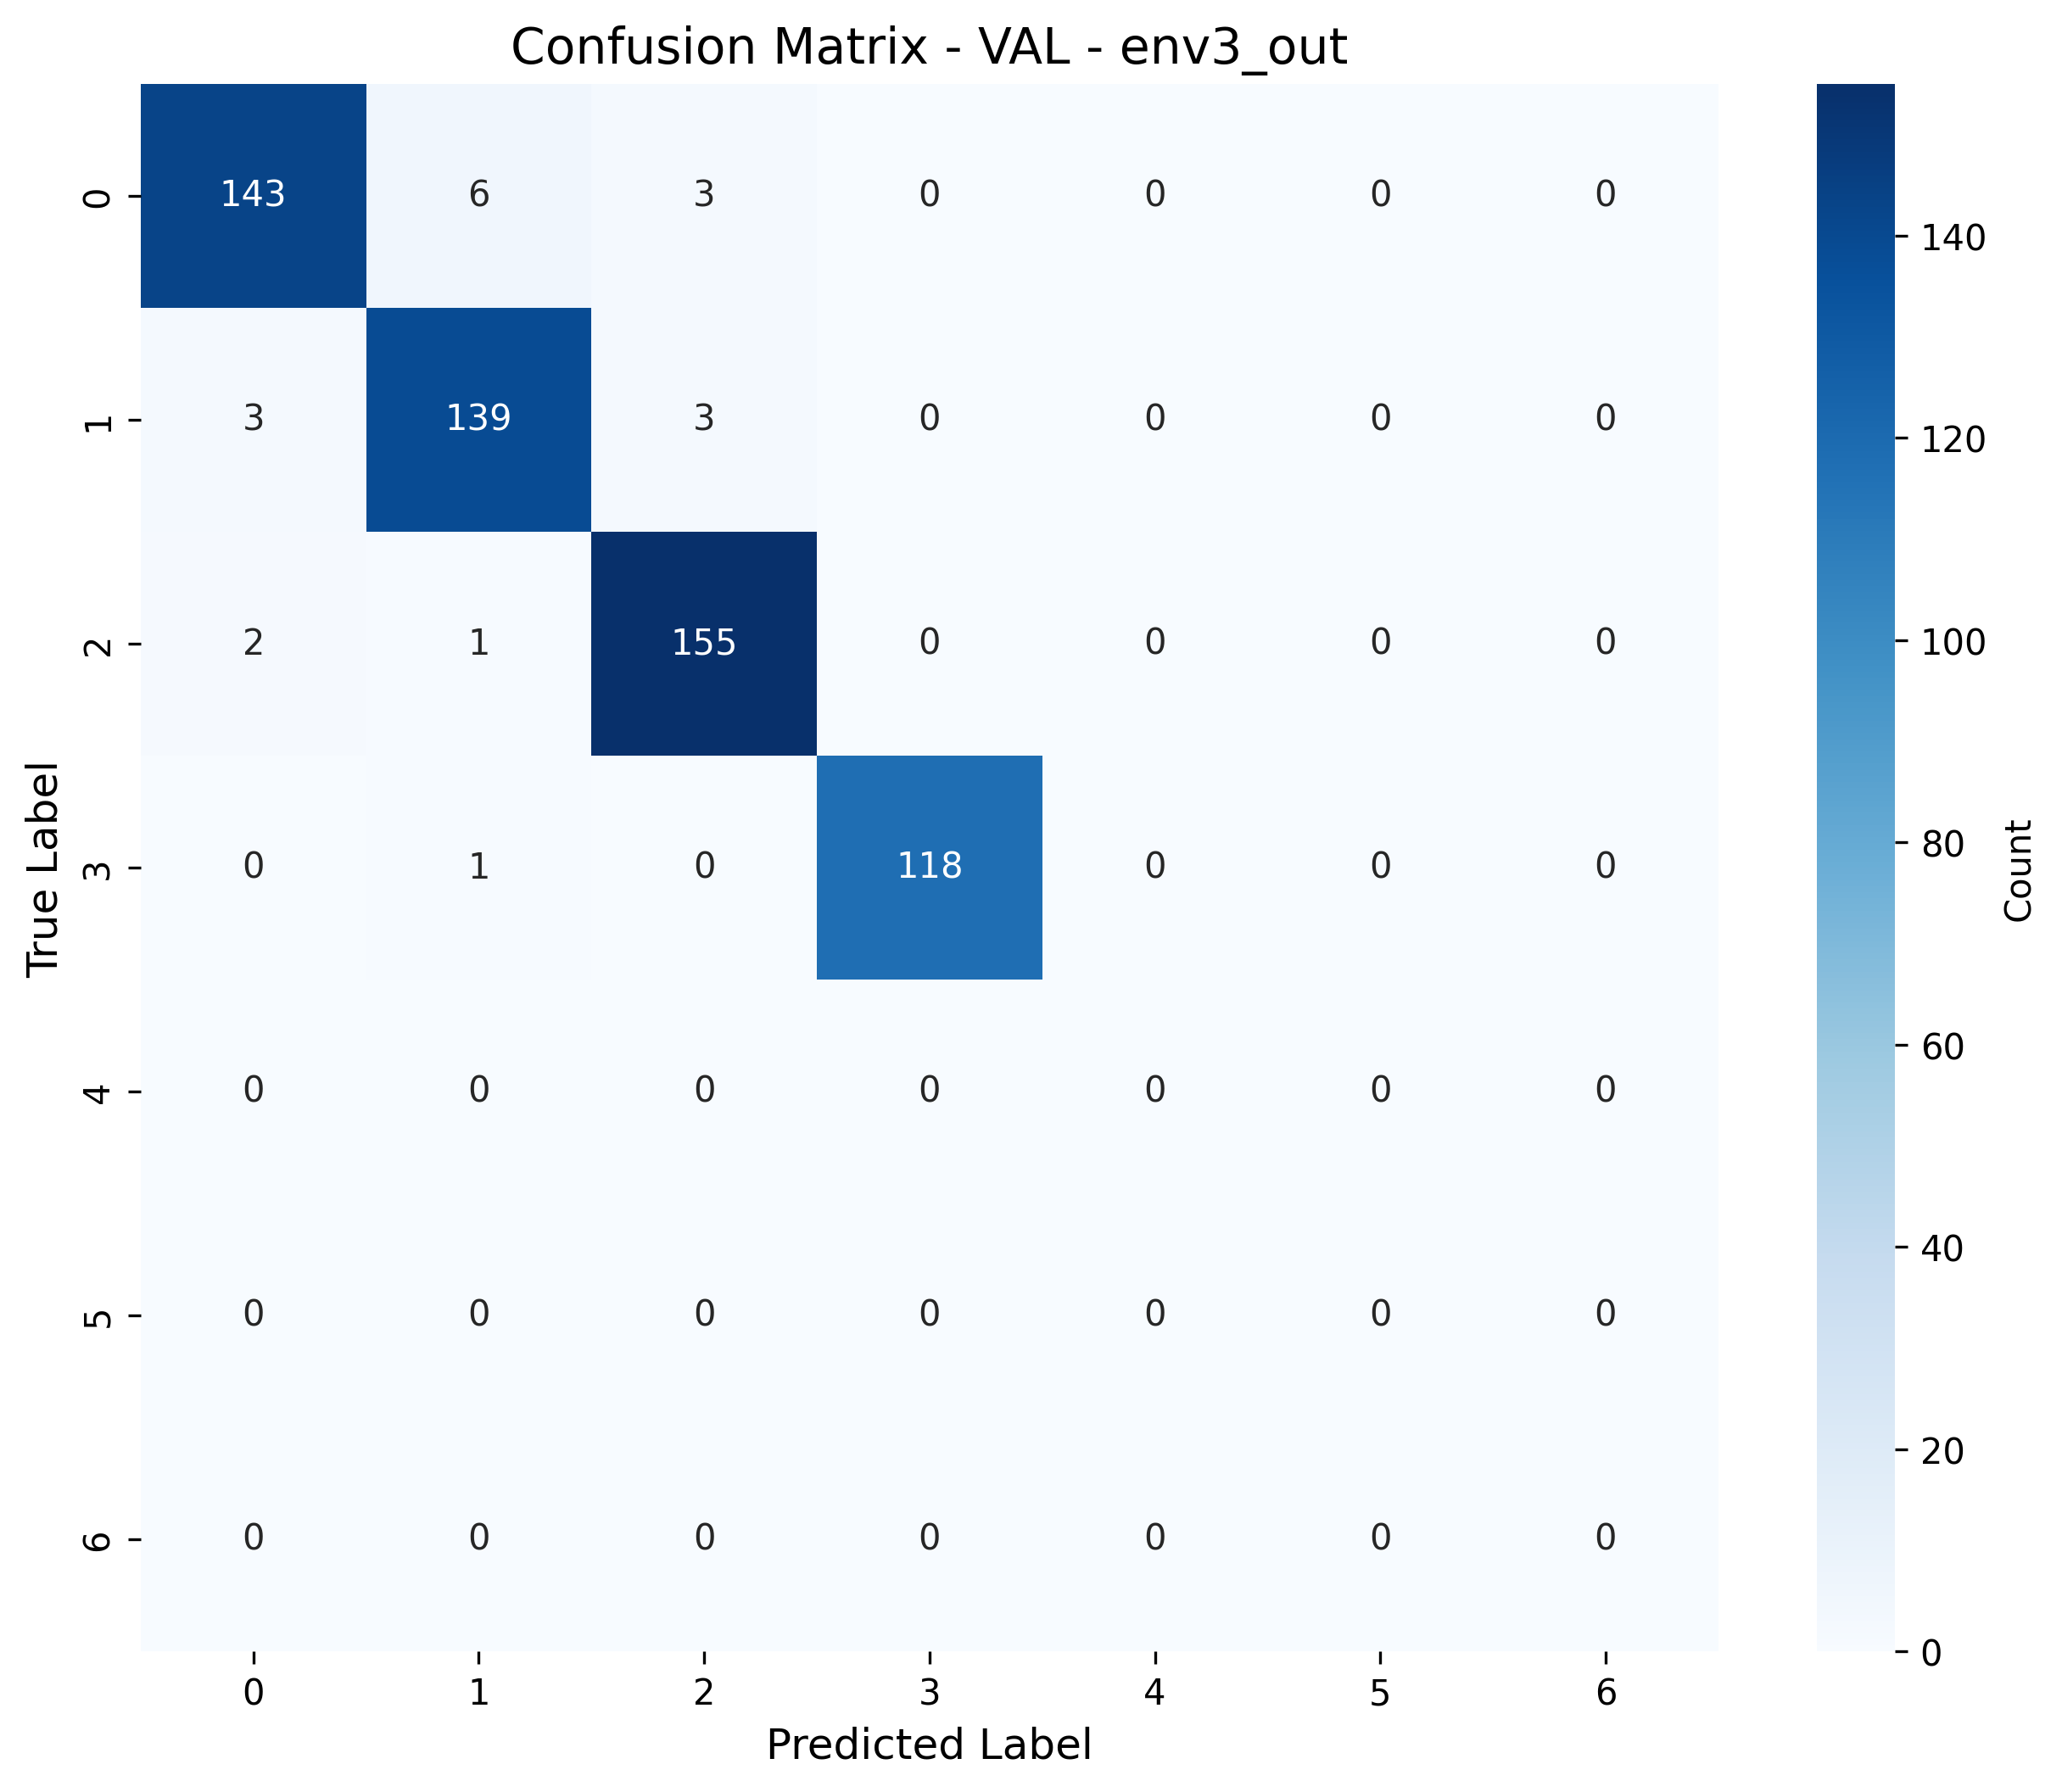



TRAINING CURVES:


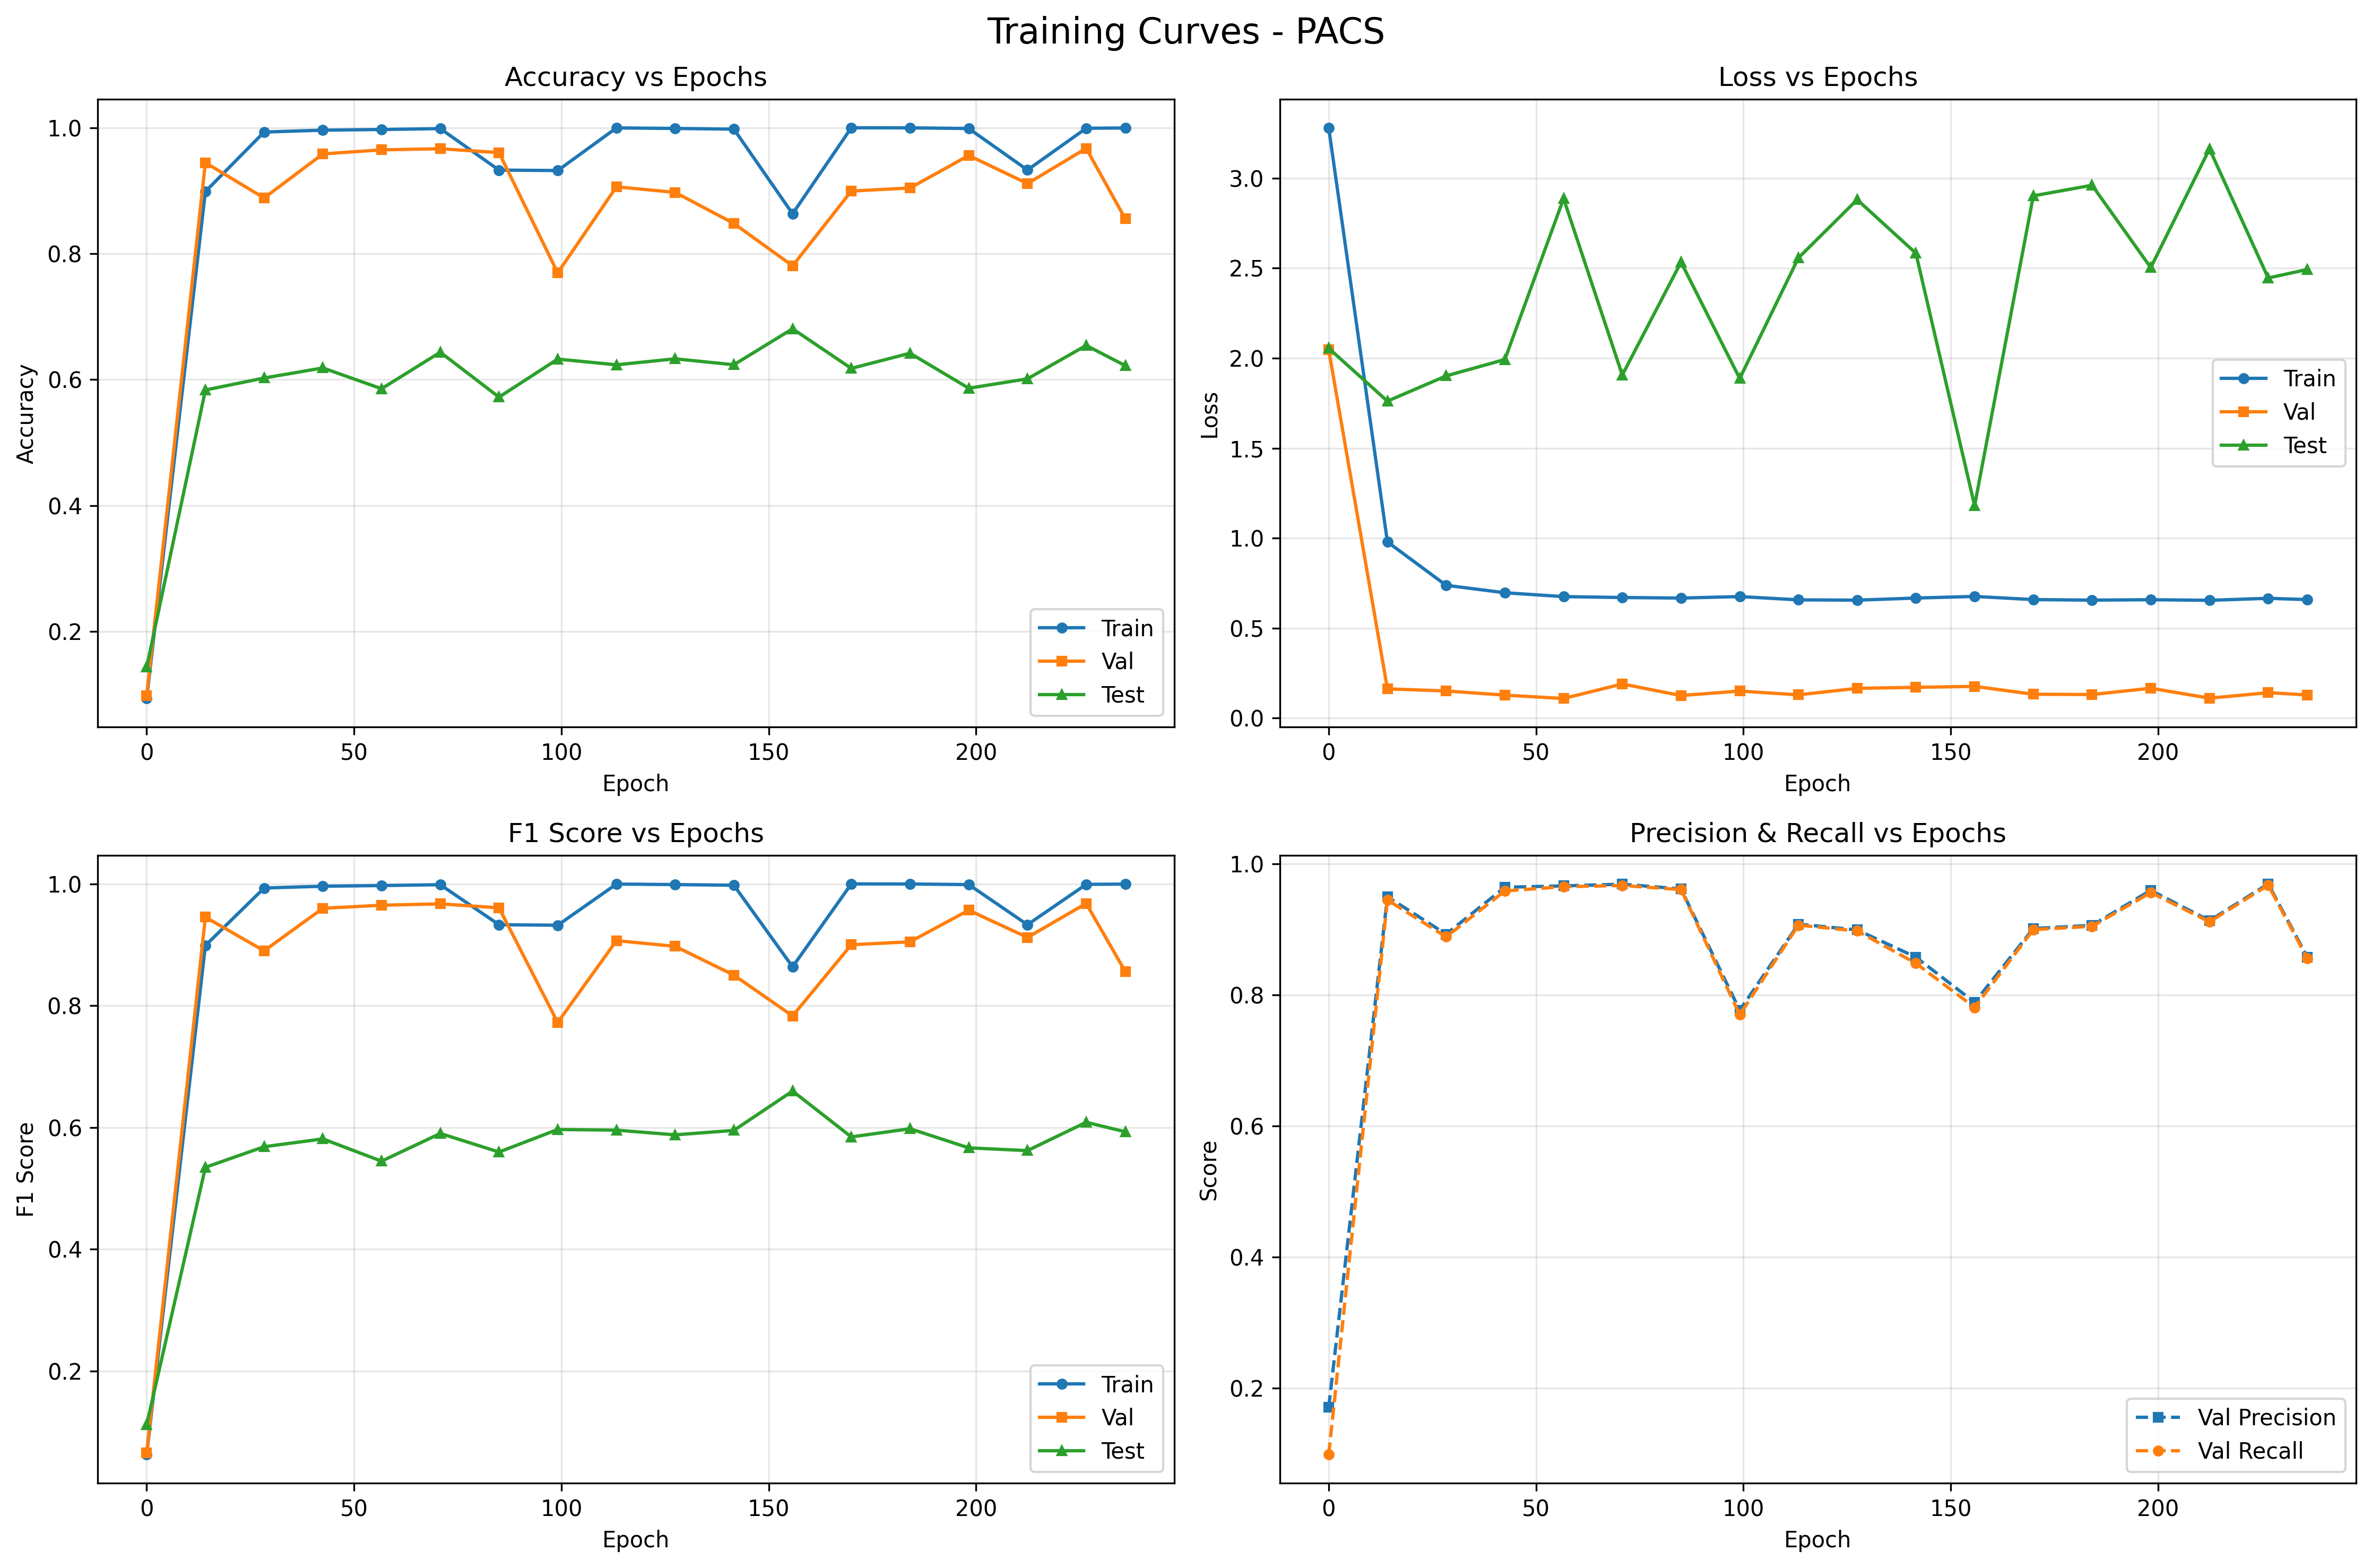

In [24]:


fit_simple(
exp_dir=str(exp_dir),
logger=logger,
seed=config.get("seed", 0),
trial_seed=config.get("trial_seed", 0),
hparams_seed=config.get("hparams_seed", 0),
algorithm_name=config["algo"],
dataset_name=dataset_name_pacs,
data_dir=config["data_dir"][dataset_name_pacs],
num_workers=config.get("num_workers", 4),
test_envs=[config["test_set_id"]],
overlap_type=config.get("overlap", "none"),
holdout_fraction=config.get("holdout_fraction", 0.2),
n_steps=config.get("n_epochs"),  # Changed to epochs!
checkpoint_freq=config.get("checkpoint_freq"),  # In epochs
model_checkpoint=config.get("model_checkpoint", {
    "metric": "val/acc",
    "maximize": True
}),
num_domain_linked_classes=config.get("num_domain_linked_classes"),
num_classes=config.get("num_classes"),
# AutoAugmentation specific
auto_augment=config.get("auto_augment", False),
augment_search_epochs=config.get("augment_search_epochs", 10),
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_pacs.csv'}")
print(f"  Best model: {exp_dir / 'best_model_pacs.ckpt'}")
print(f"  Config: {exp_dir / 'config_pacs.json'}")


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_pacs}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# Display training curves
print("\n\nTRAINING CURVES:")
print("="*60)
display(Image(filename=os.path.join(log_dir, 'training_curves_PACS.png')))

# # Display epoch times
# print("\n\nEPOCH TIMES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'epoch_times_PACS.png')))


## VLCS

In [25]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_vlcs = input()
config["name"] = exp_name_vlcs

exp_name_vlcs = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_vlcs
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_vlcs}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)## VLCS

 third_experiment


In [26]:
dataset_name_vlcs = config["dataset"][1]
dataset_name_vlcs

'VLCS'

Seed set to 0


num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2], [2, 3, 4], [3, 4, 0]]
Model checkpoint frequency: 300


  0%|          | 0/5001 [02:09<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 129.3472s
TRAIN: loss=3.0466, acc=0.0848, precision=0.1775, recall=0.0848, f1=0.0783
VAL: loss=1.8302, acc=0.0709, precision=0.0739, recall=0.0709, f1=0.0608
TEST: loss=2.1761, acc=0.2941, precision=0.1105, recall=0.2941, f1=0.1229
OTHER: loss=2.1912, acc=0.2824, precision=0.1432, recall=0.2824, f1=0.1295


  6%|▌         | 301/5001 [09:36<46:22:43, 35.52s/it]

...


=== Step 4800 (Epoch 141.18) ===
step_time: 111.1810s
TRAIN: loss=0.8358, acc=0.8324, precision=0.8329, recall=0.8324, f1=0.8327
VAL: loss=0.8483, acc=0.4340, precision=0.5420, recall=0.4340, f1=0.4605
TEST: loss=4.2911, acc=0.5123, precision=0.4501, recall=0.5123, f1=0.4170
OTHER: loss=4.3804, acc=0.5752, precision=0.4900, recall=0.5752, f1=0.4478


100%|█████████▉| 5000/5001 [2:04:45<00:00,  1.00it/s]  


=== Step 5000 (Epoch 147.06) ===
step_time: 113.4985s
TRAIN: loss=0.8230, acc=0.9165, precision=0.9165, recall=0.9165, f1=0.9165
VAL: loss=0.8584, acc=0.4446, precision=0.5420, recall=0.4446, f1=0.4671
TEST: loss=5.3480, acc=0.5077, precision=0.4295, recall=0.5077, f1=0.4129
OTHER: loss=5.6419, acc=0.5634, precision=0.4254, recall=0.5634, f1=0.4288


100%|██████████| 5001/5001 [2:04:45<00:00,  1.50s/it]



TRAINING COMPLETED
Total training time: 7485.91s (124.77 minutes)
Average time per epoch: 50.14s
Total epochs: 147


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 5.3553
  Accuracy: 0.5077, Precision: 0.4295, Recall: 0.5077, F1: 0.4129
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.png


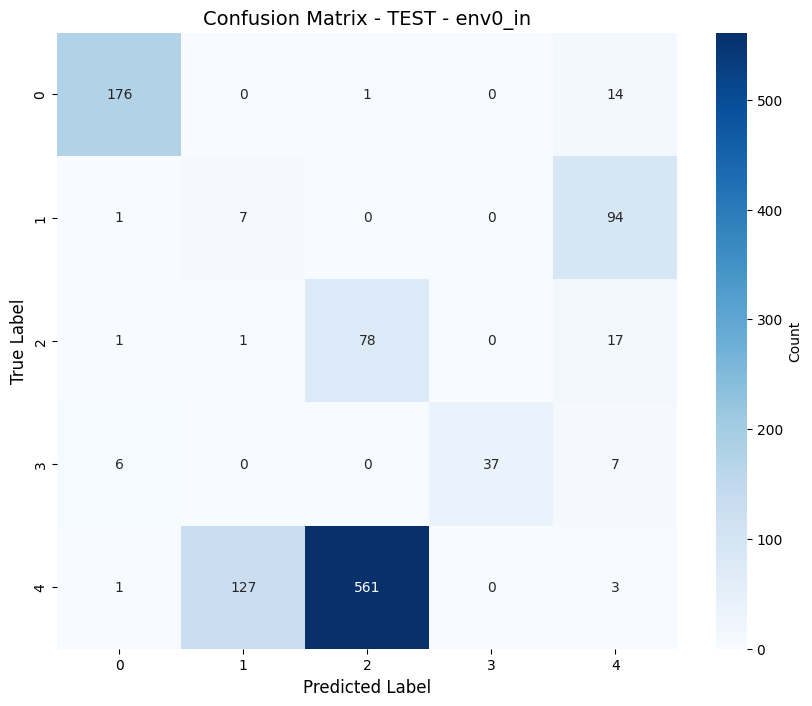


TRAIN - env1_in:
  Loss: 0.0011
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.png


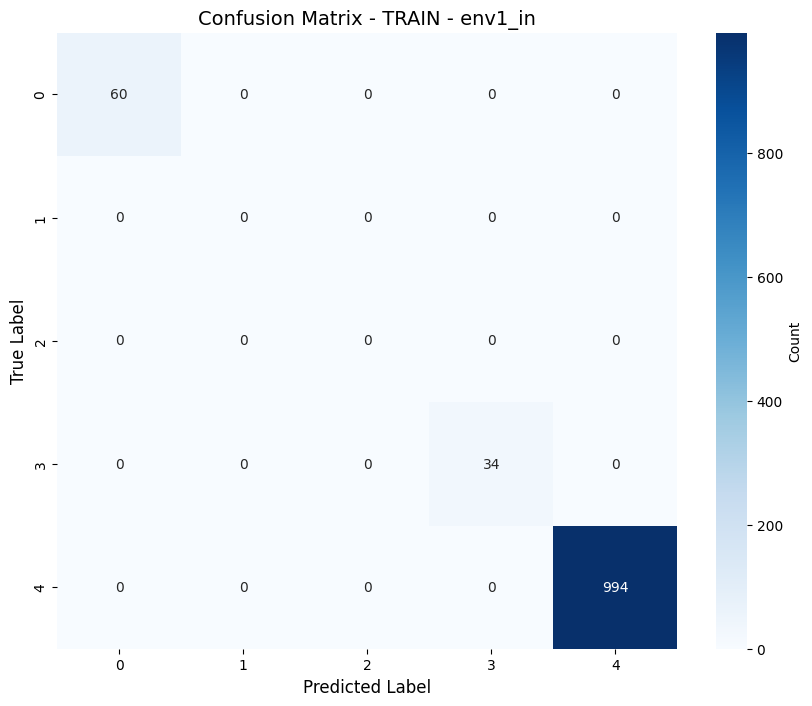


TRAIN - env2_in:
  Loss: 0.0032
  Accuracy: 0.9986, Precision: 0.9985, Recall: 0.9986, F1: 0.9985
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env2_in.png


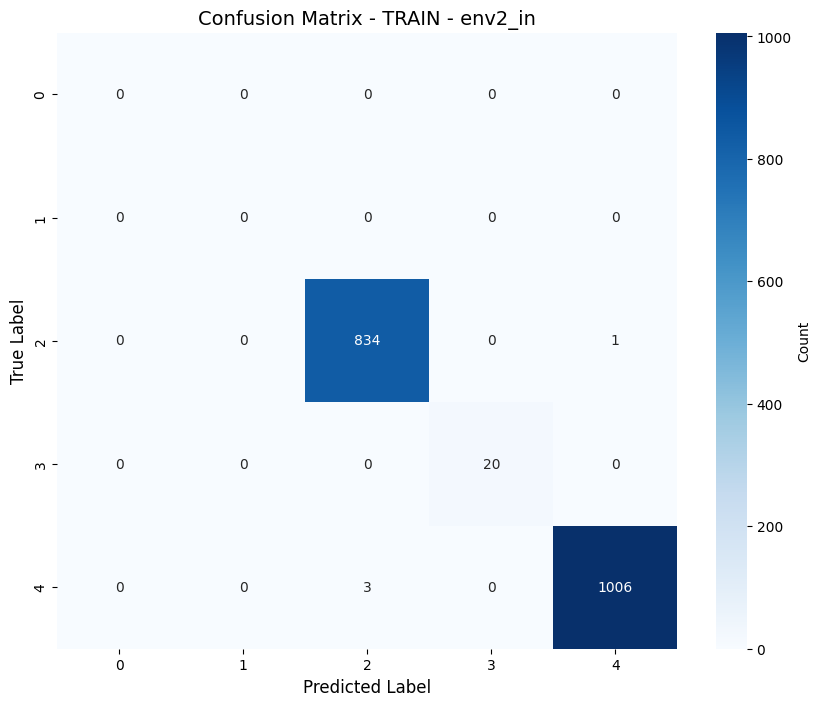


TRAIN - env3_in:
  Loss: 0.0005
  Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env3_in.png


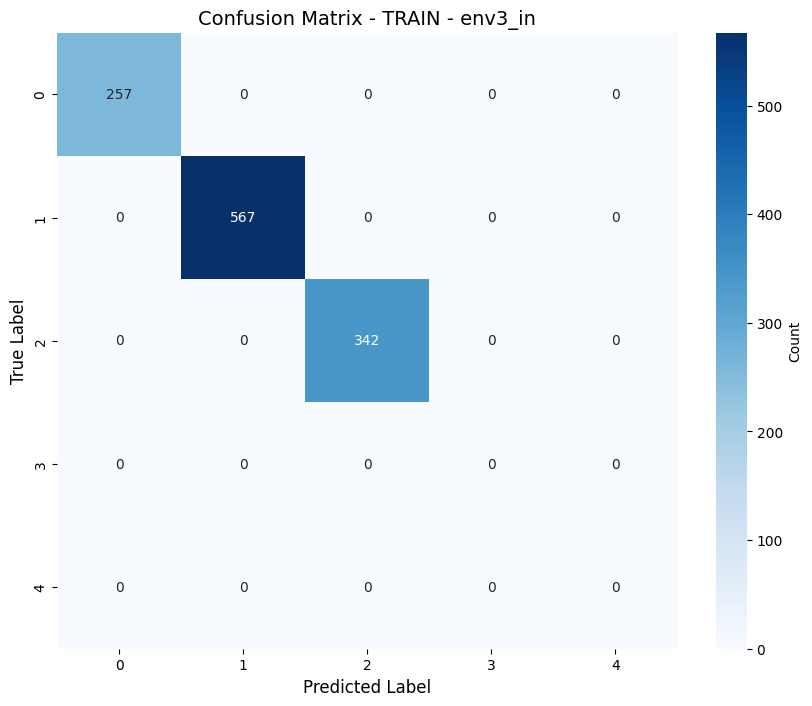


OTHER - env0_out:
  Loss: 5.6844
  Accuracy: 0.5634, Precision: 0.4254, Recall: 0.5634, F1: 0.4288
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_OTHER_env0_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_OTHER_env0_out.png


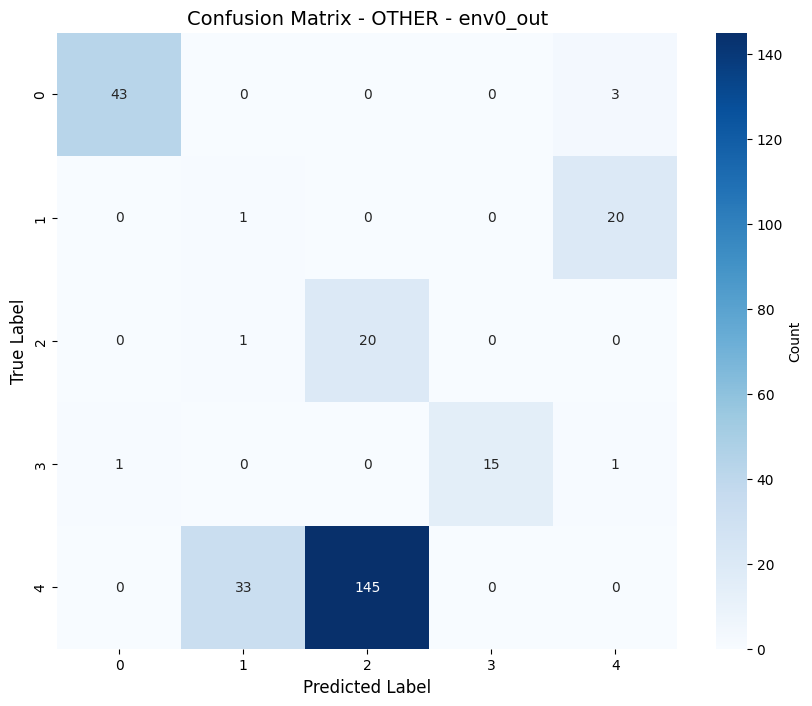


VAL - env1_out:
  Loss: 0.6965
  Accuracy: 0.3385, Precision: 0.3775, Recall: 0.3385, F1: 0.3559
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env1_out.png


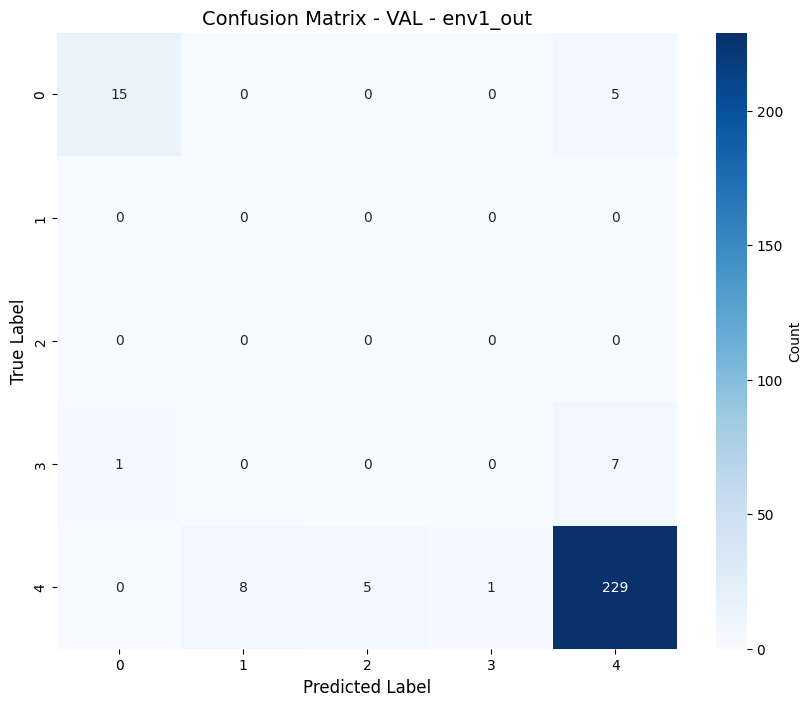


VAL - env2_out:
  Loss: 1.0612
  Accuracy: 0.3873, Precision: 0.5262, Recall: 0.3873, F1: 0.4190
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env2_out.png


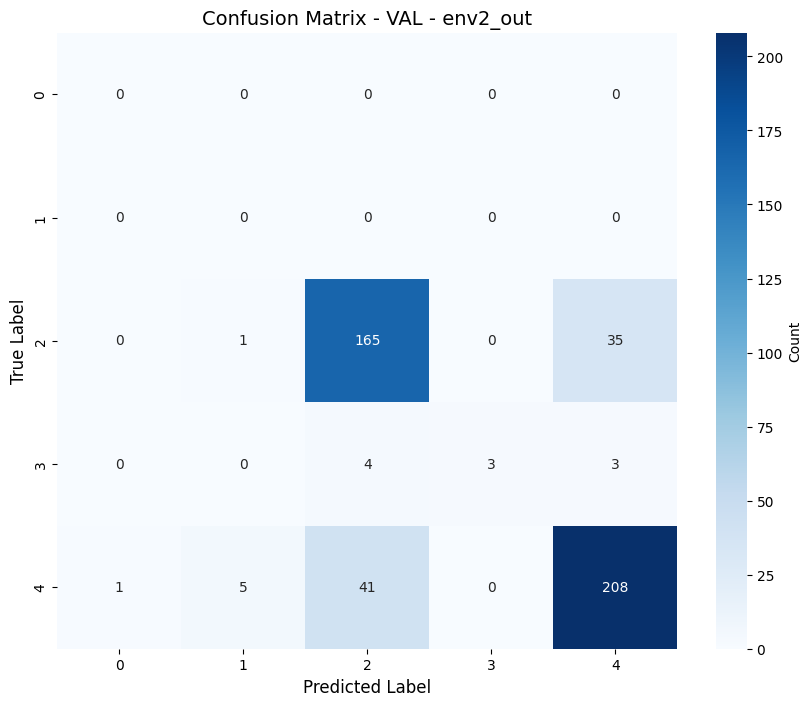


VAL - env3_out:
  Loss: 0.8129
  Accuracy: 0.4968, Precision: 0.5677, Recall: 0.4968, F1: 0.5292
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env3_out.png


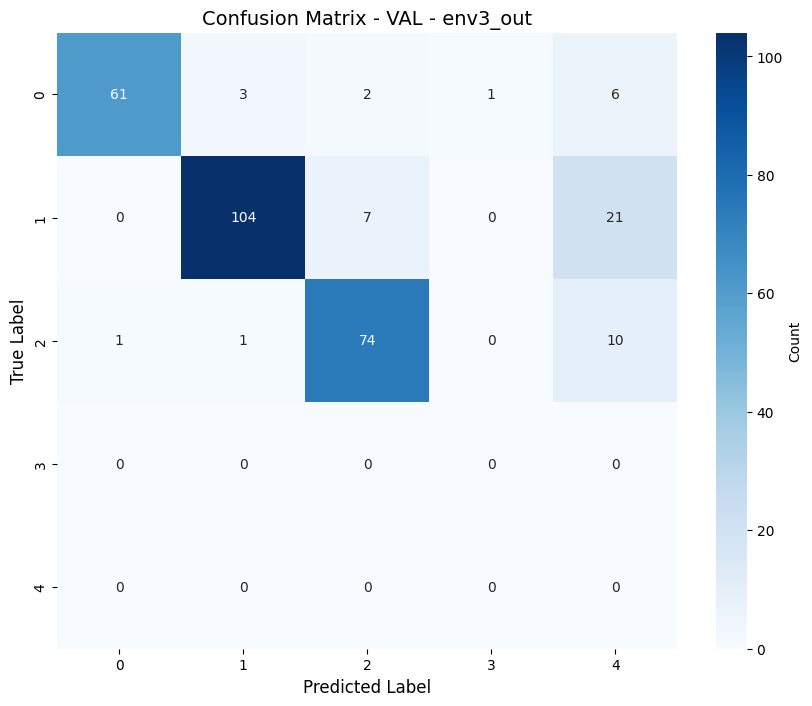


Training curves saved to: /kaggle/working/experiments/third_experiment/logs/training_curves_VLCS.png


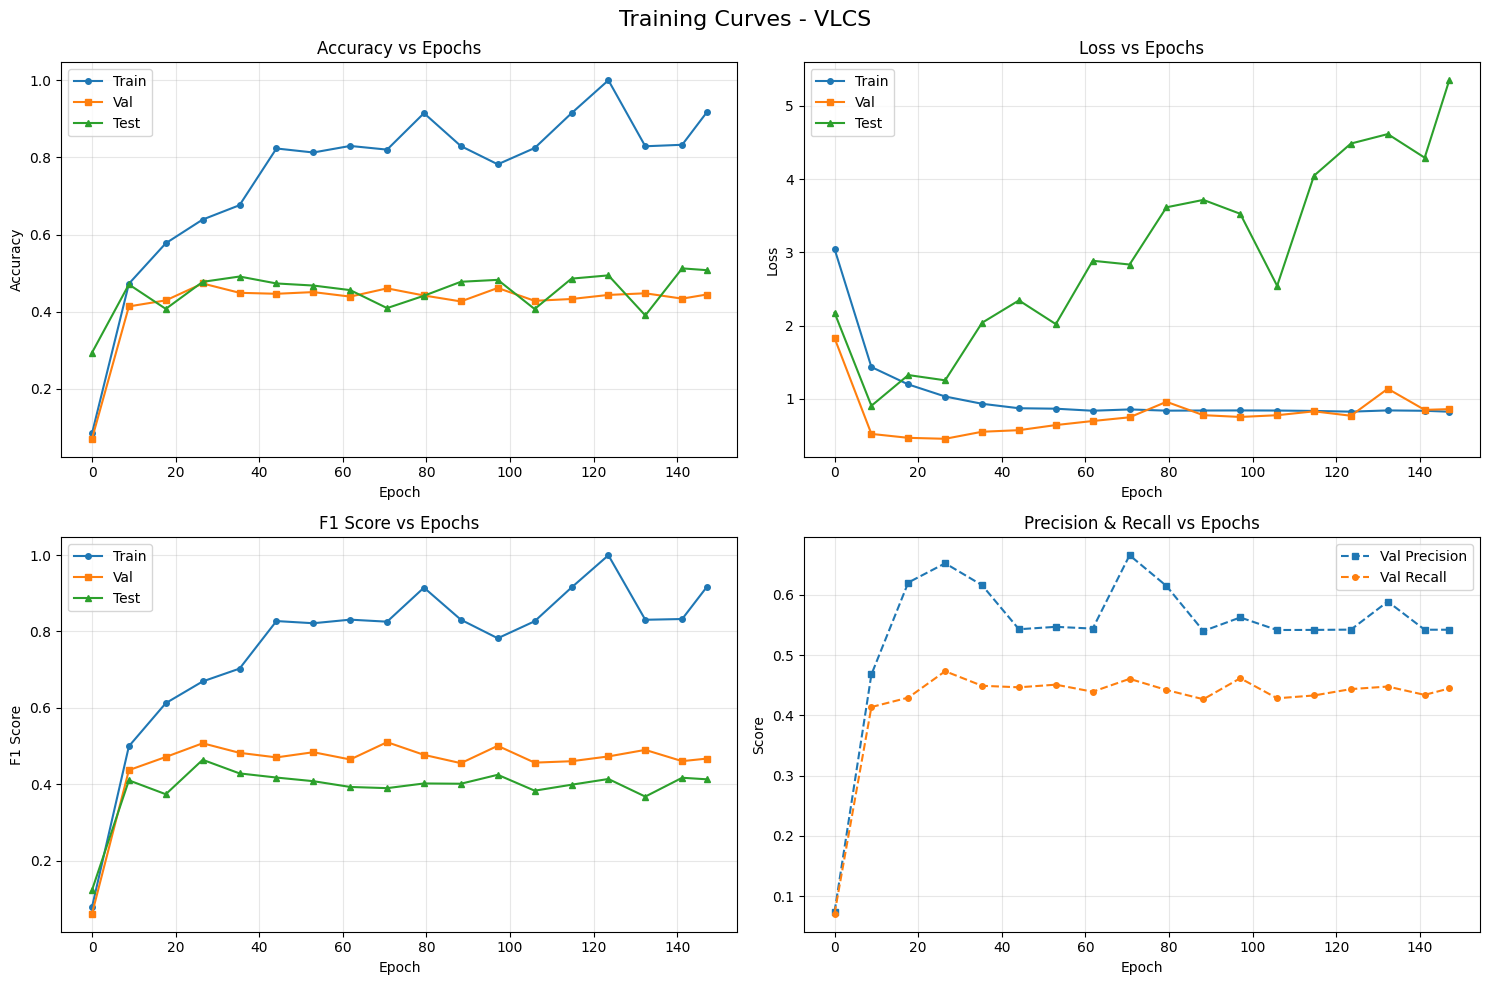

Epoch time plot saved to: /kaggle/working/experiments/third_experiment/logs/epoch_times_VLCS.png


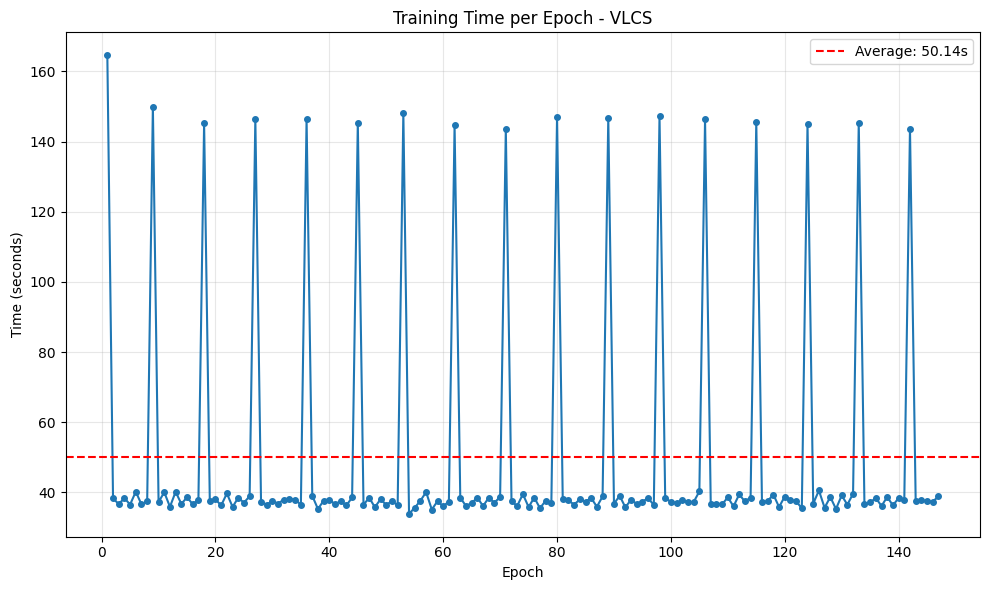


All results saved to: /kaggle/working/experiments/third_experiment/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_VLCS.png
  - epoch_times_VLCS.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)

✓ Experiment complete!
  Results: /kaggle/working/experiments/third_experiment/metrics_vlcs.csv
  Best model: /kaggle/working/experiments/third_experiment/best_model_vlcs.ckpt
  Config: /kaggle/working/experiments/third_experiment/config_vlcs.json
CONFUSION MATRICES:

confusion_matrix_OTHER_env0_out.png


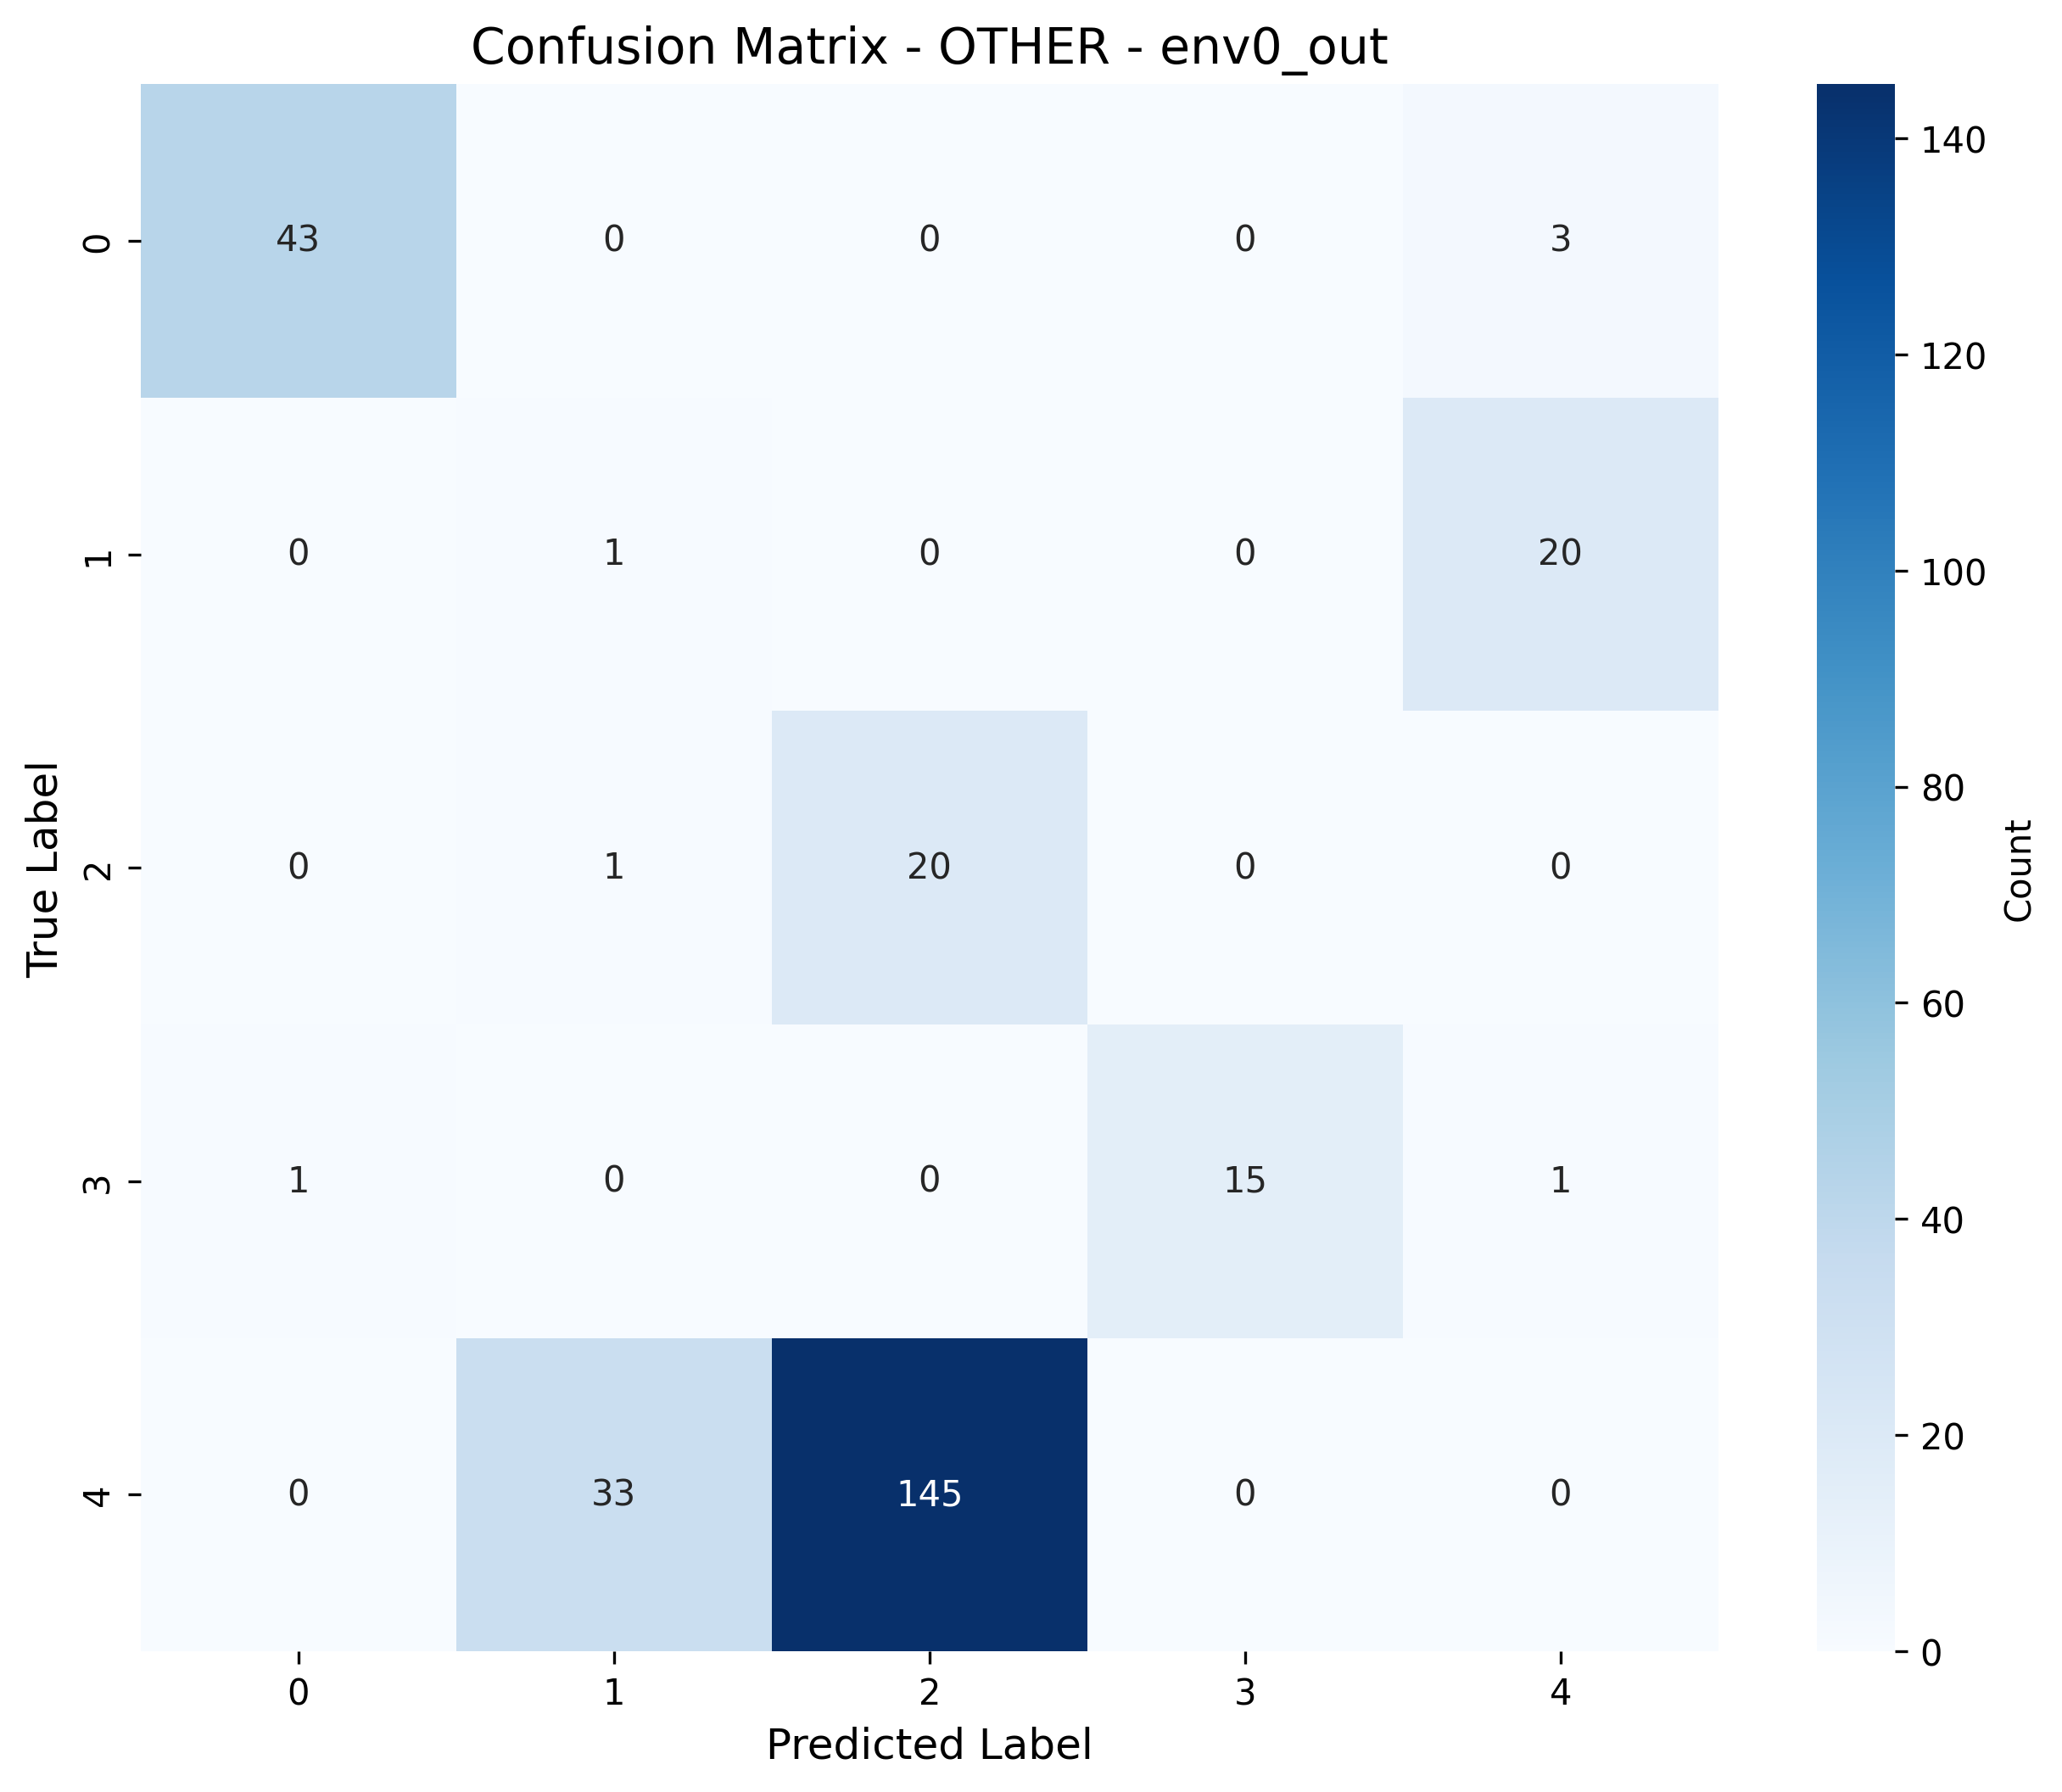


confusion_matrix_TEST_env0_in.png


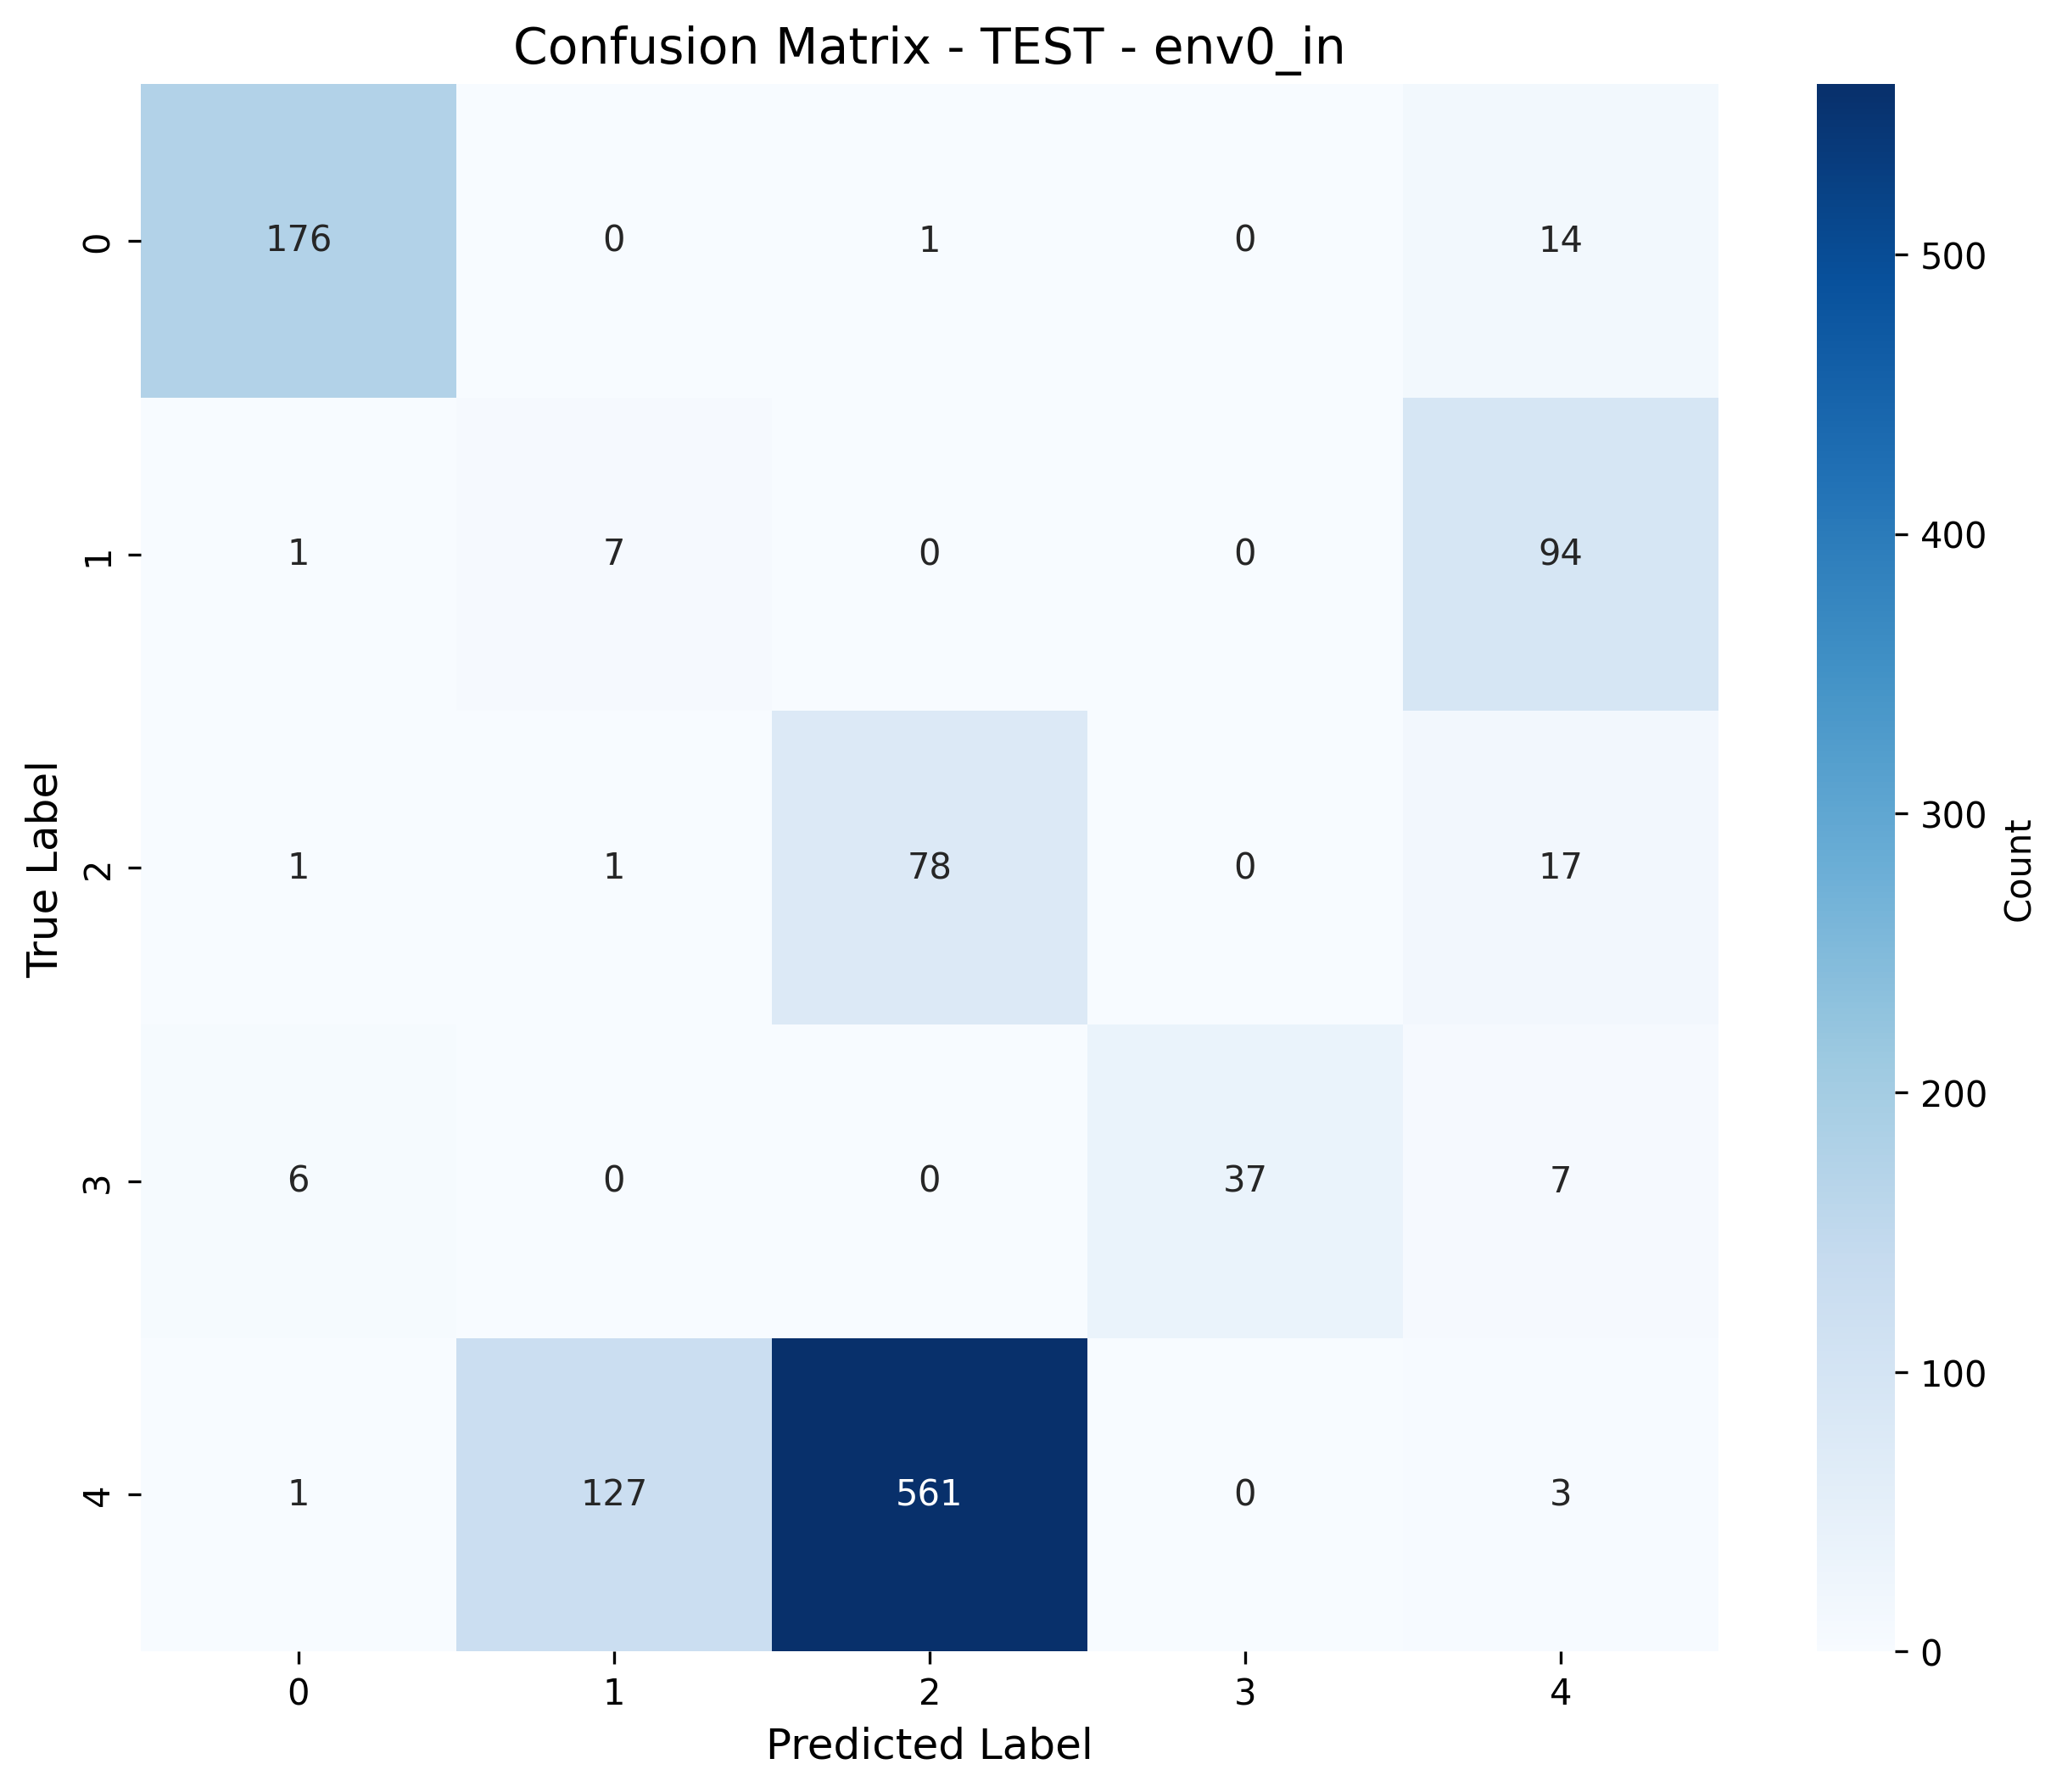


confusion_matrix_TRAIN_env1_in.png


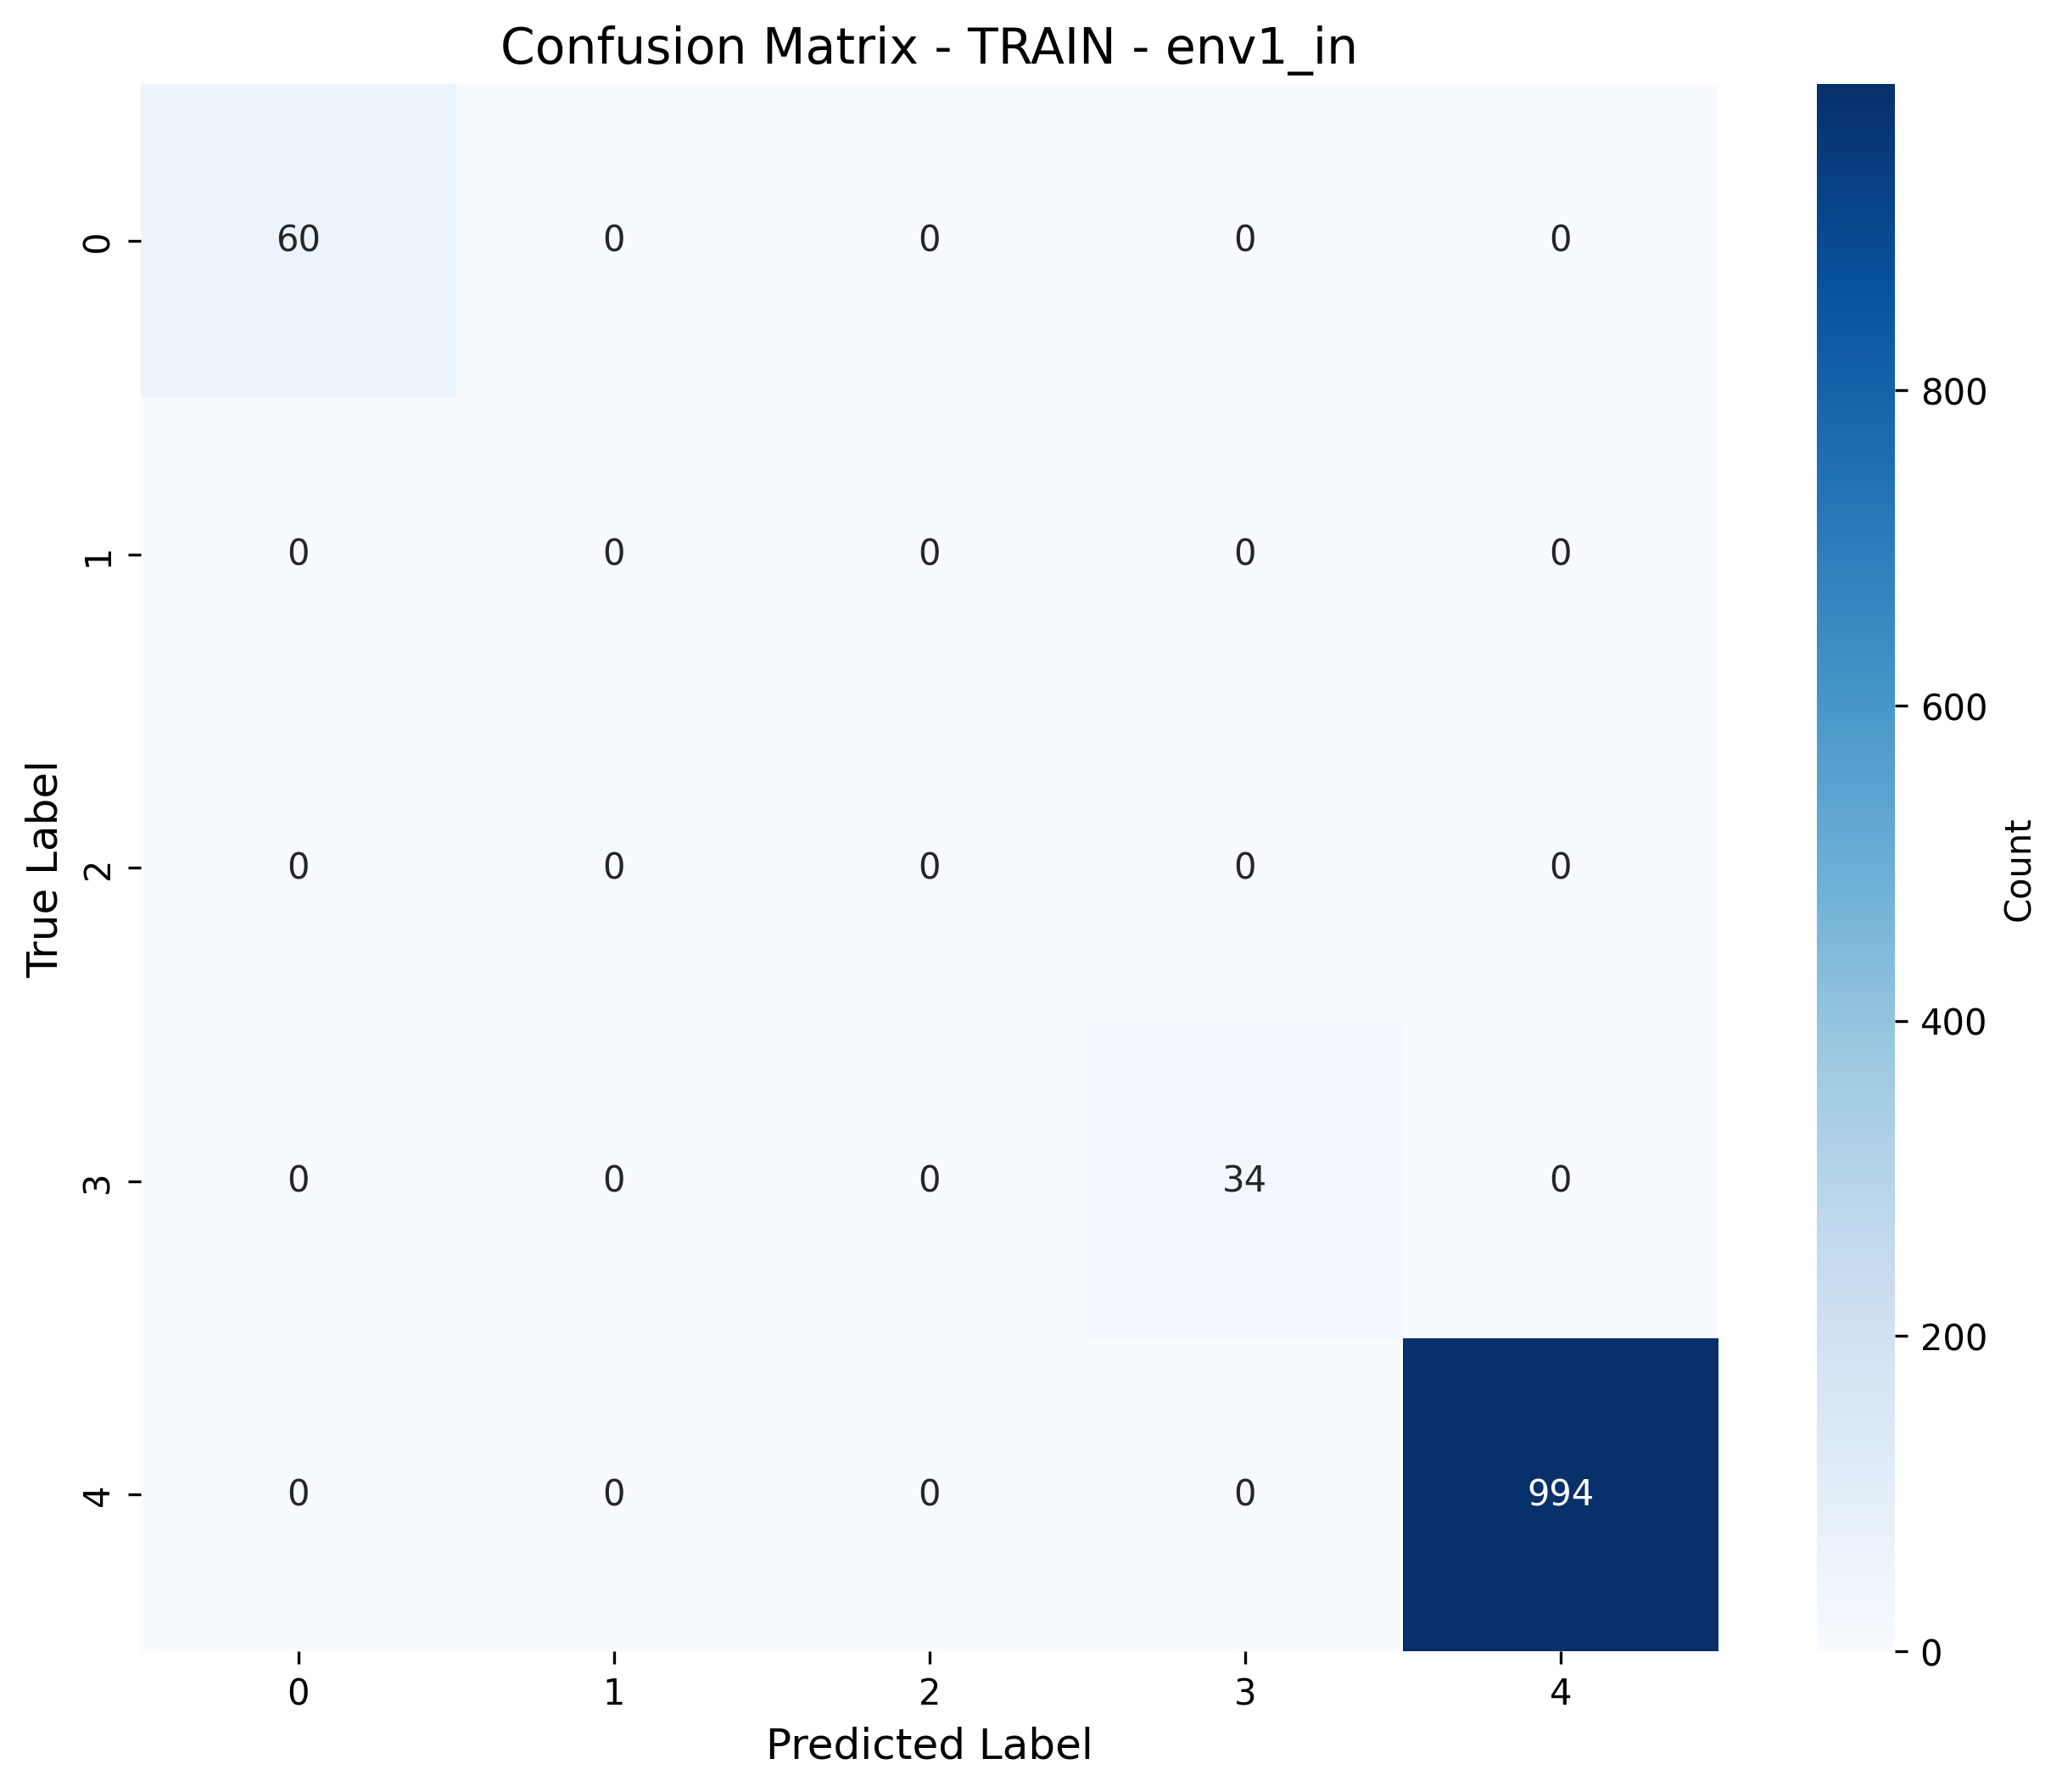


confusion_matrix_TRAIN_env2_in.png


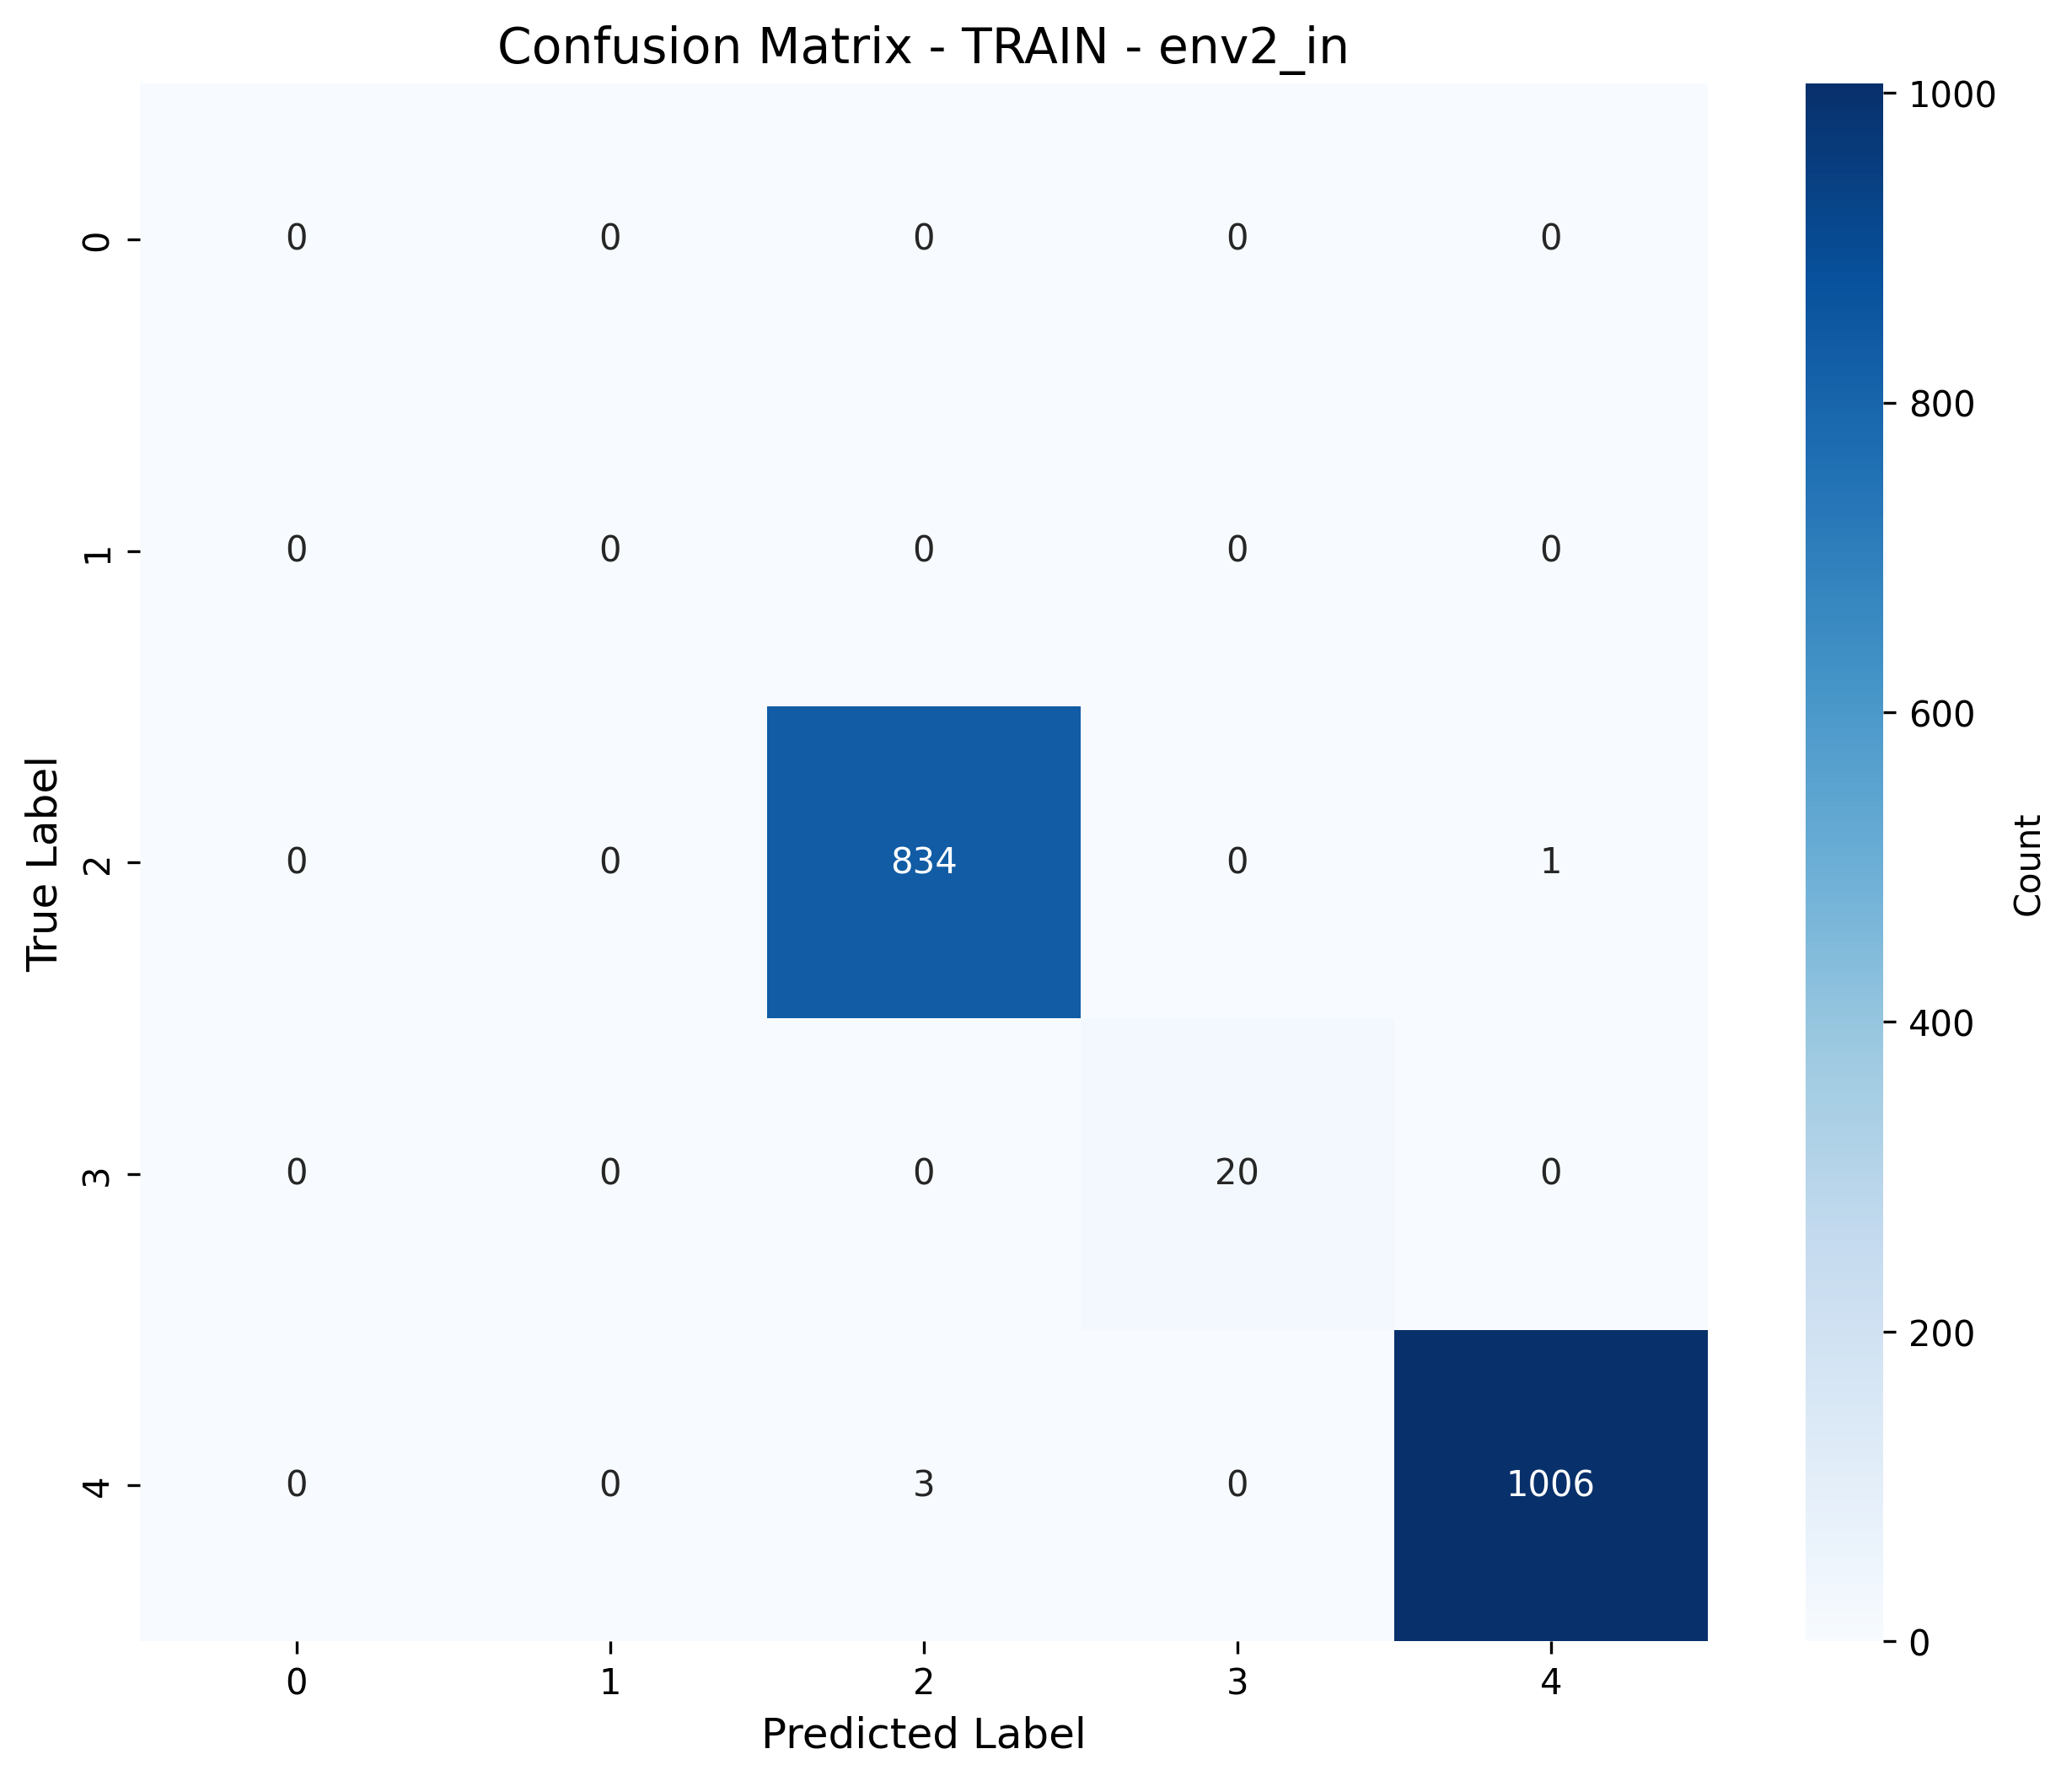


confusion_matrix_TRAIN_env3_in.png


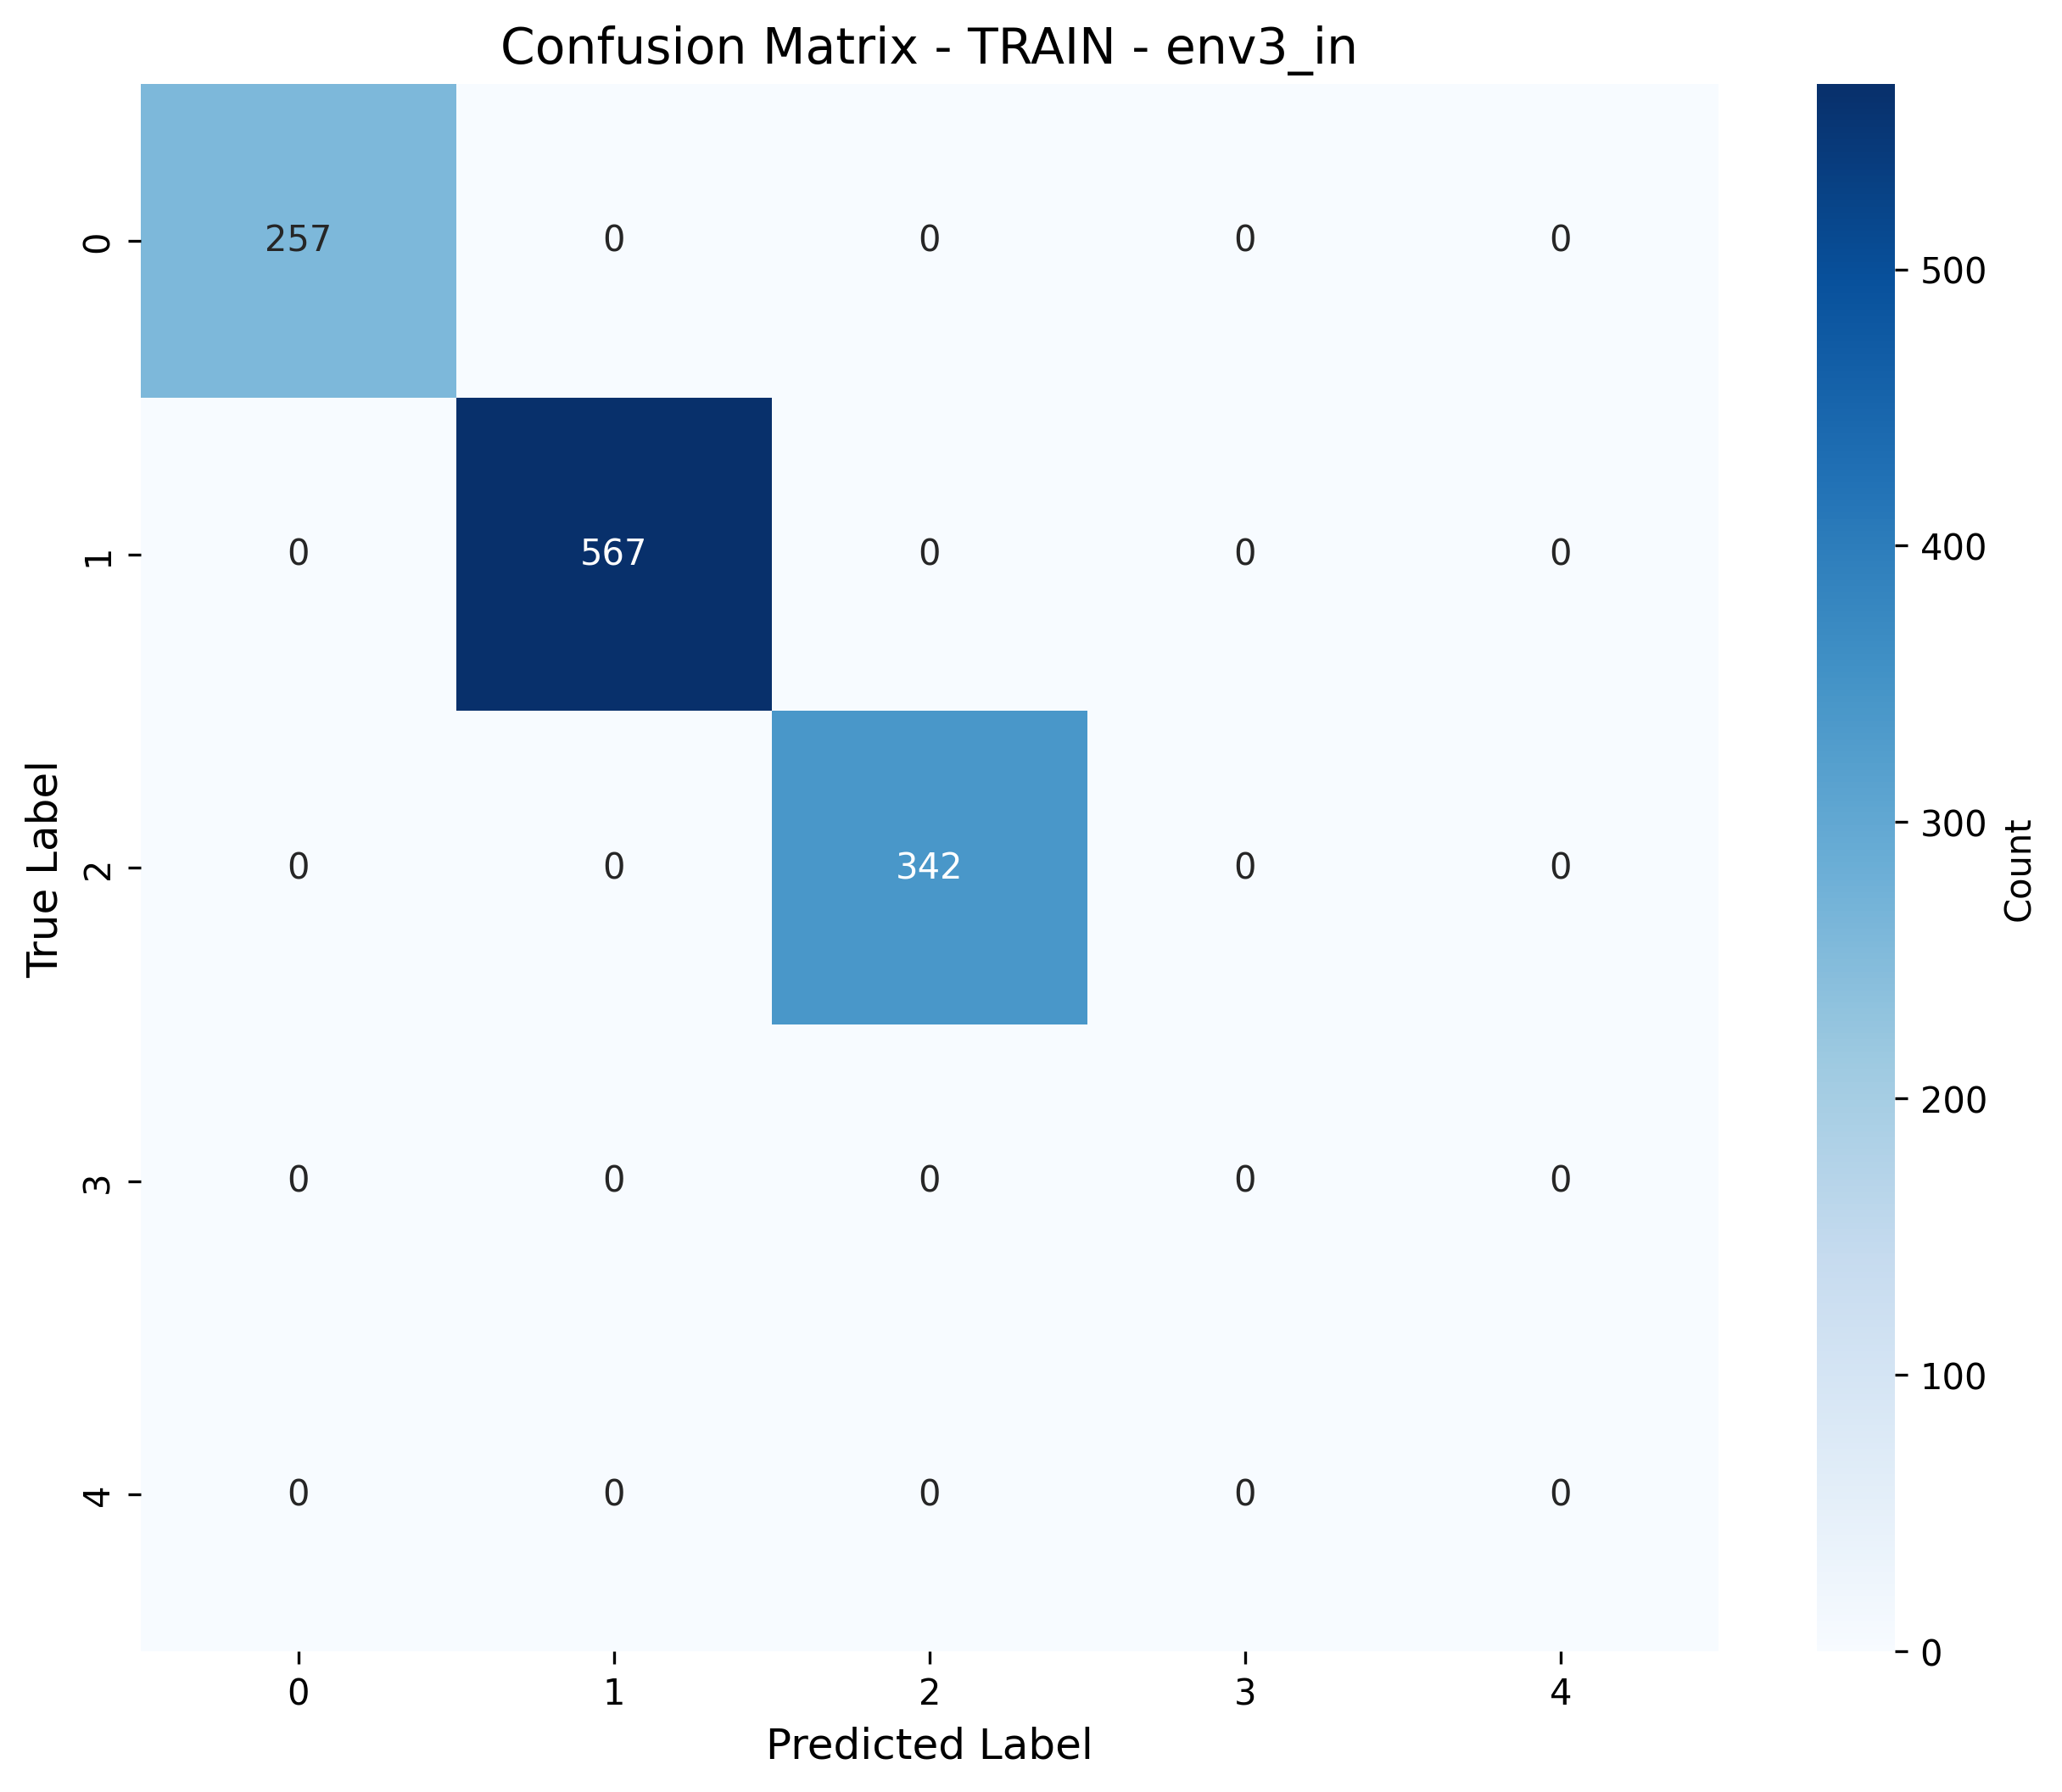


confusion_matrix_VAL_env1_out.png


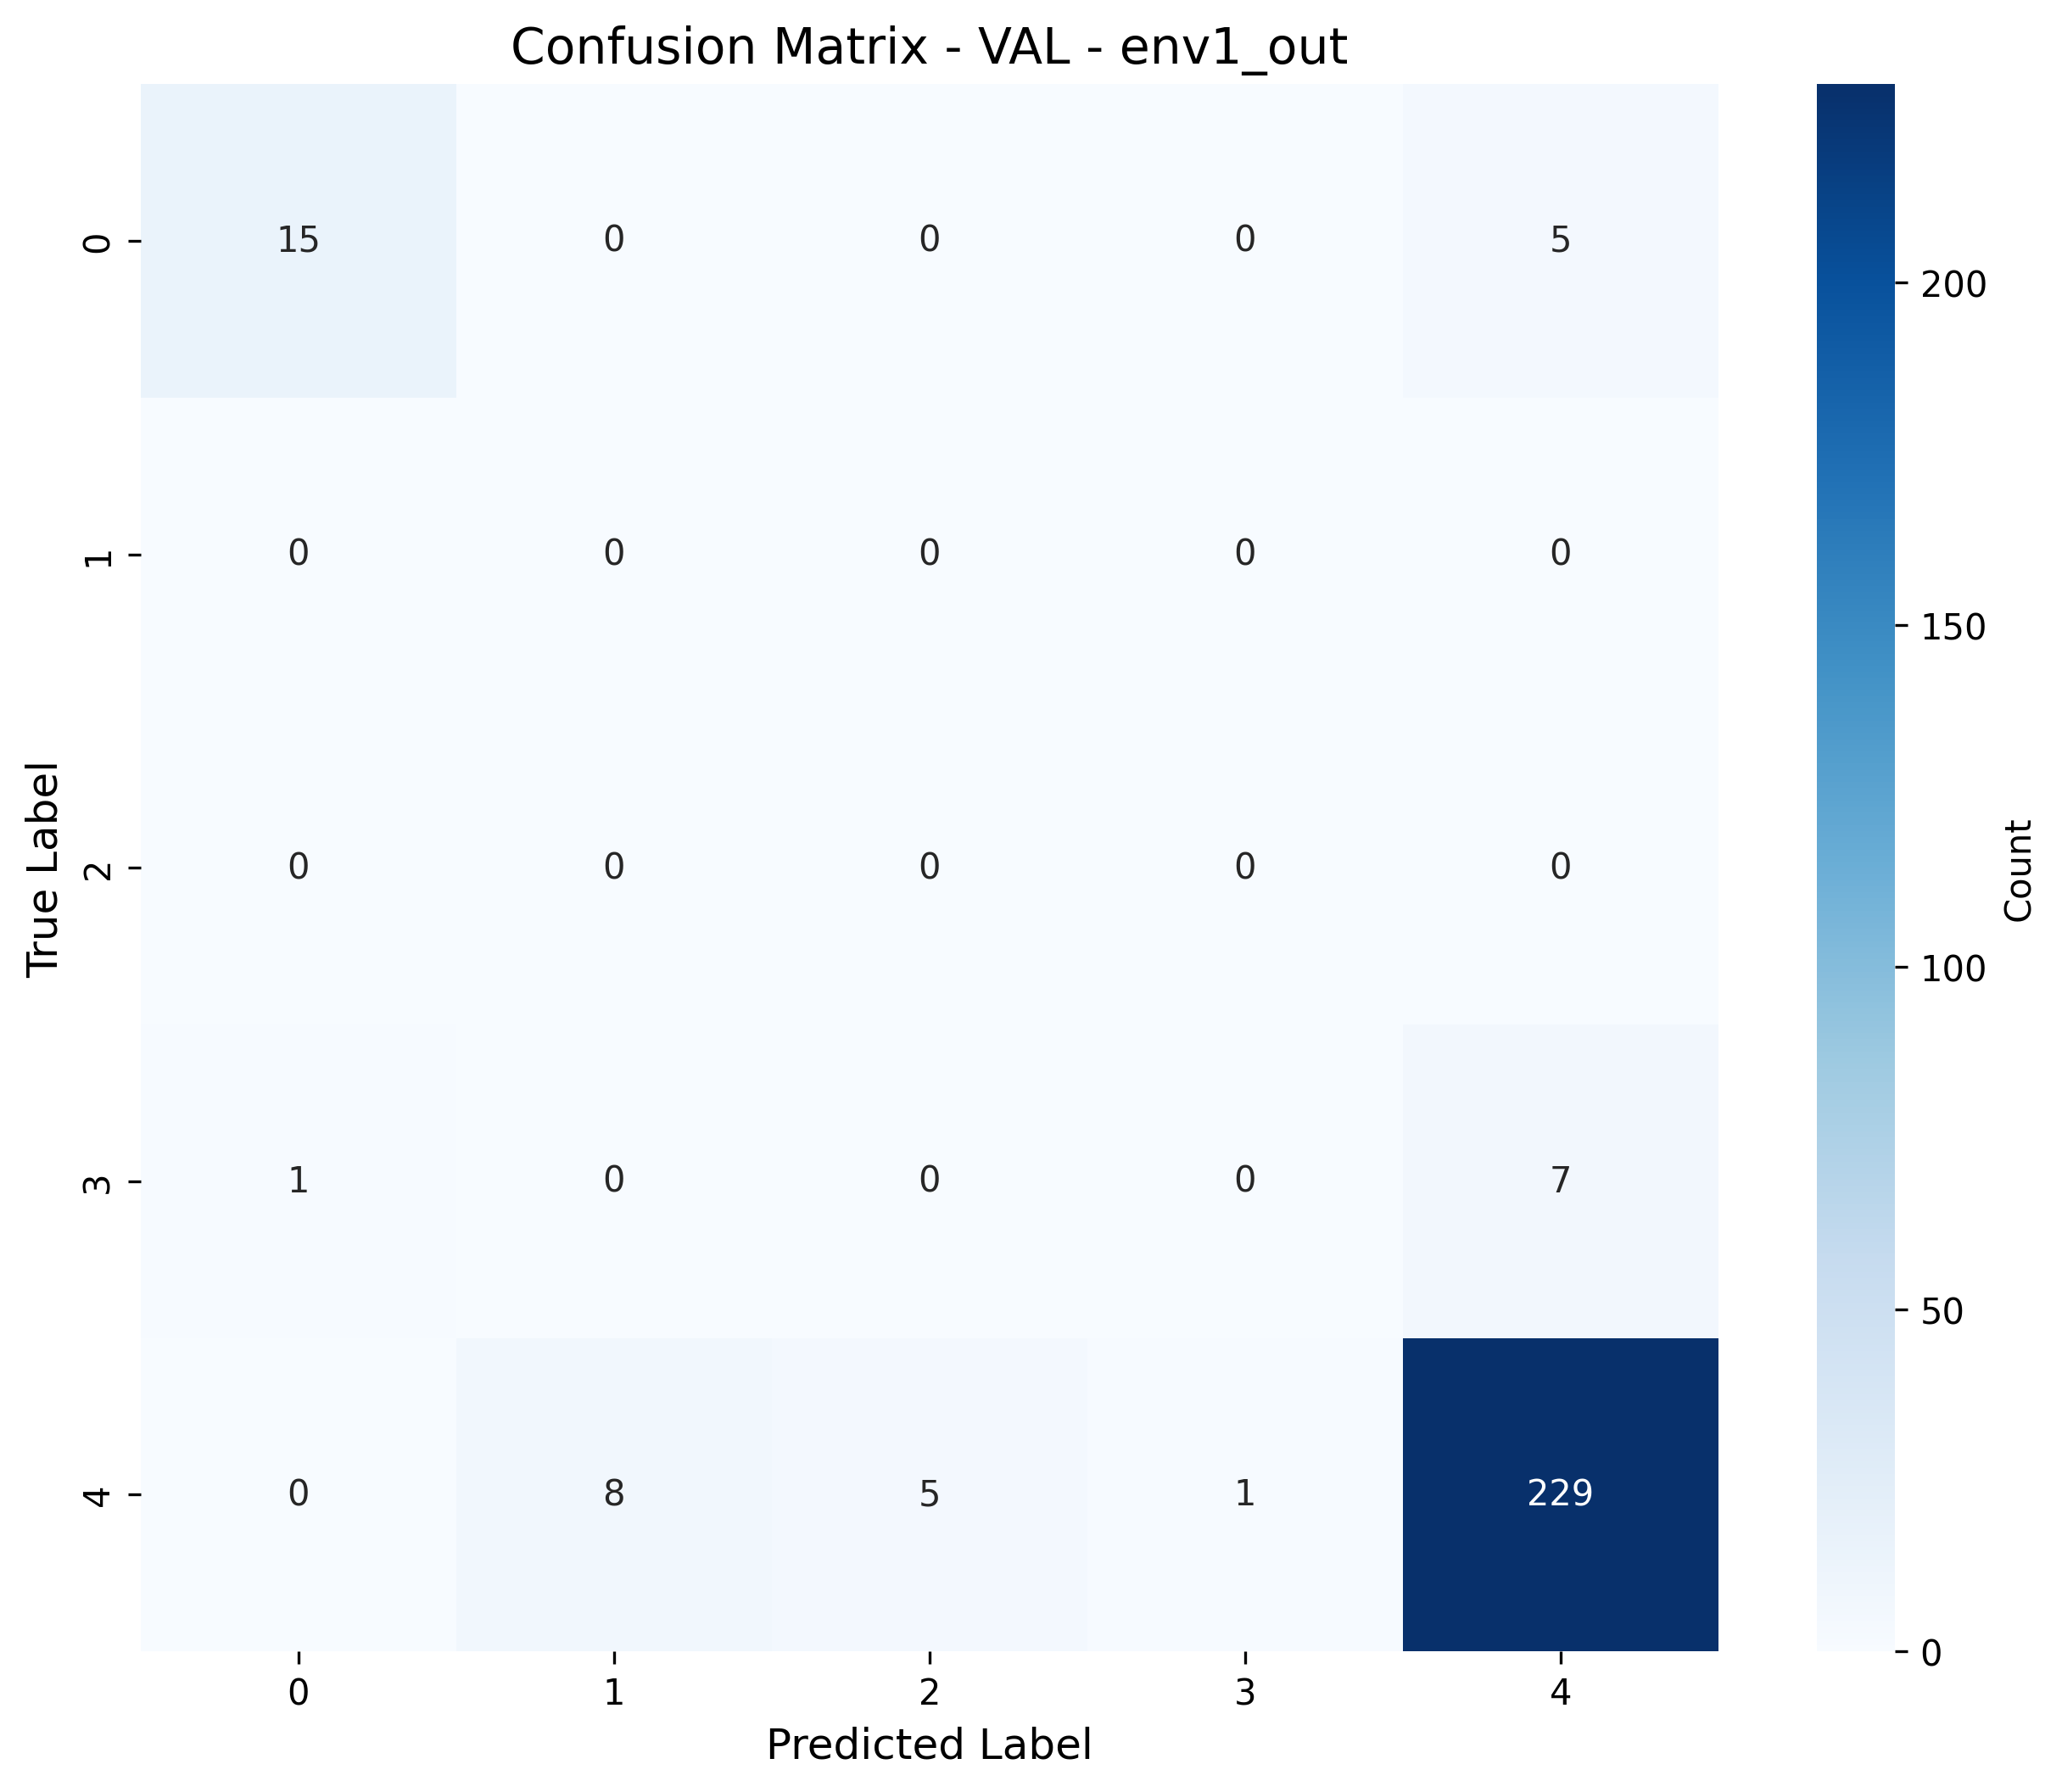


confusion_matrix_VAL_env2_out.png


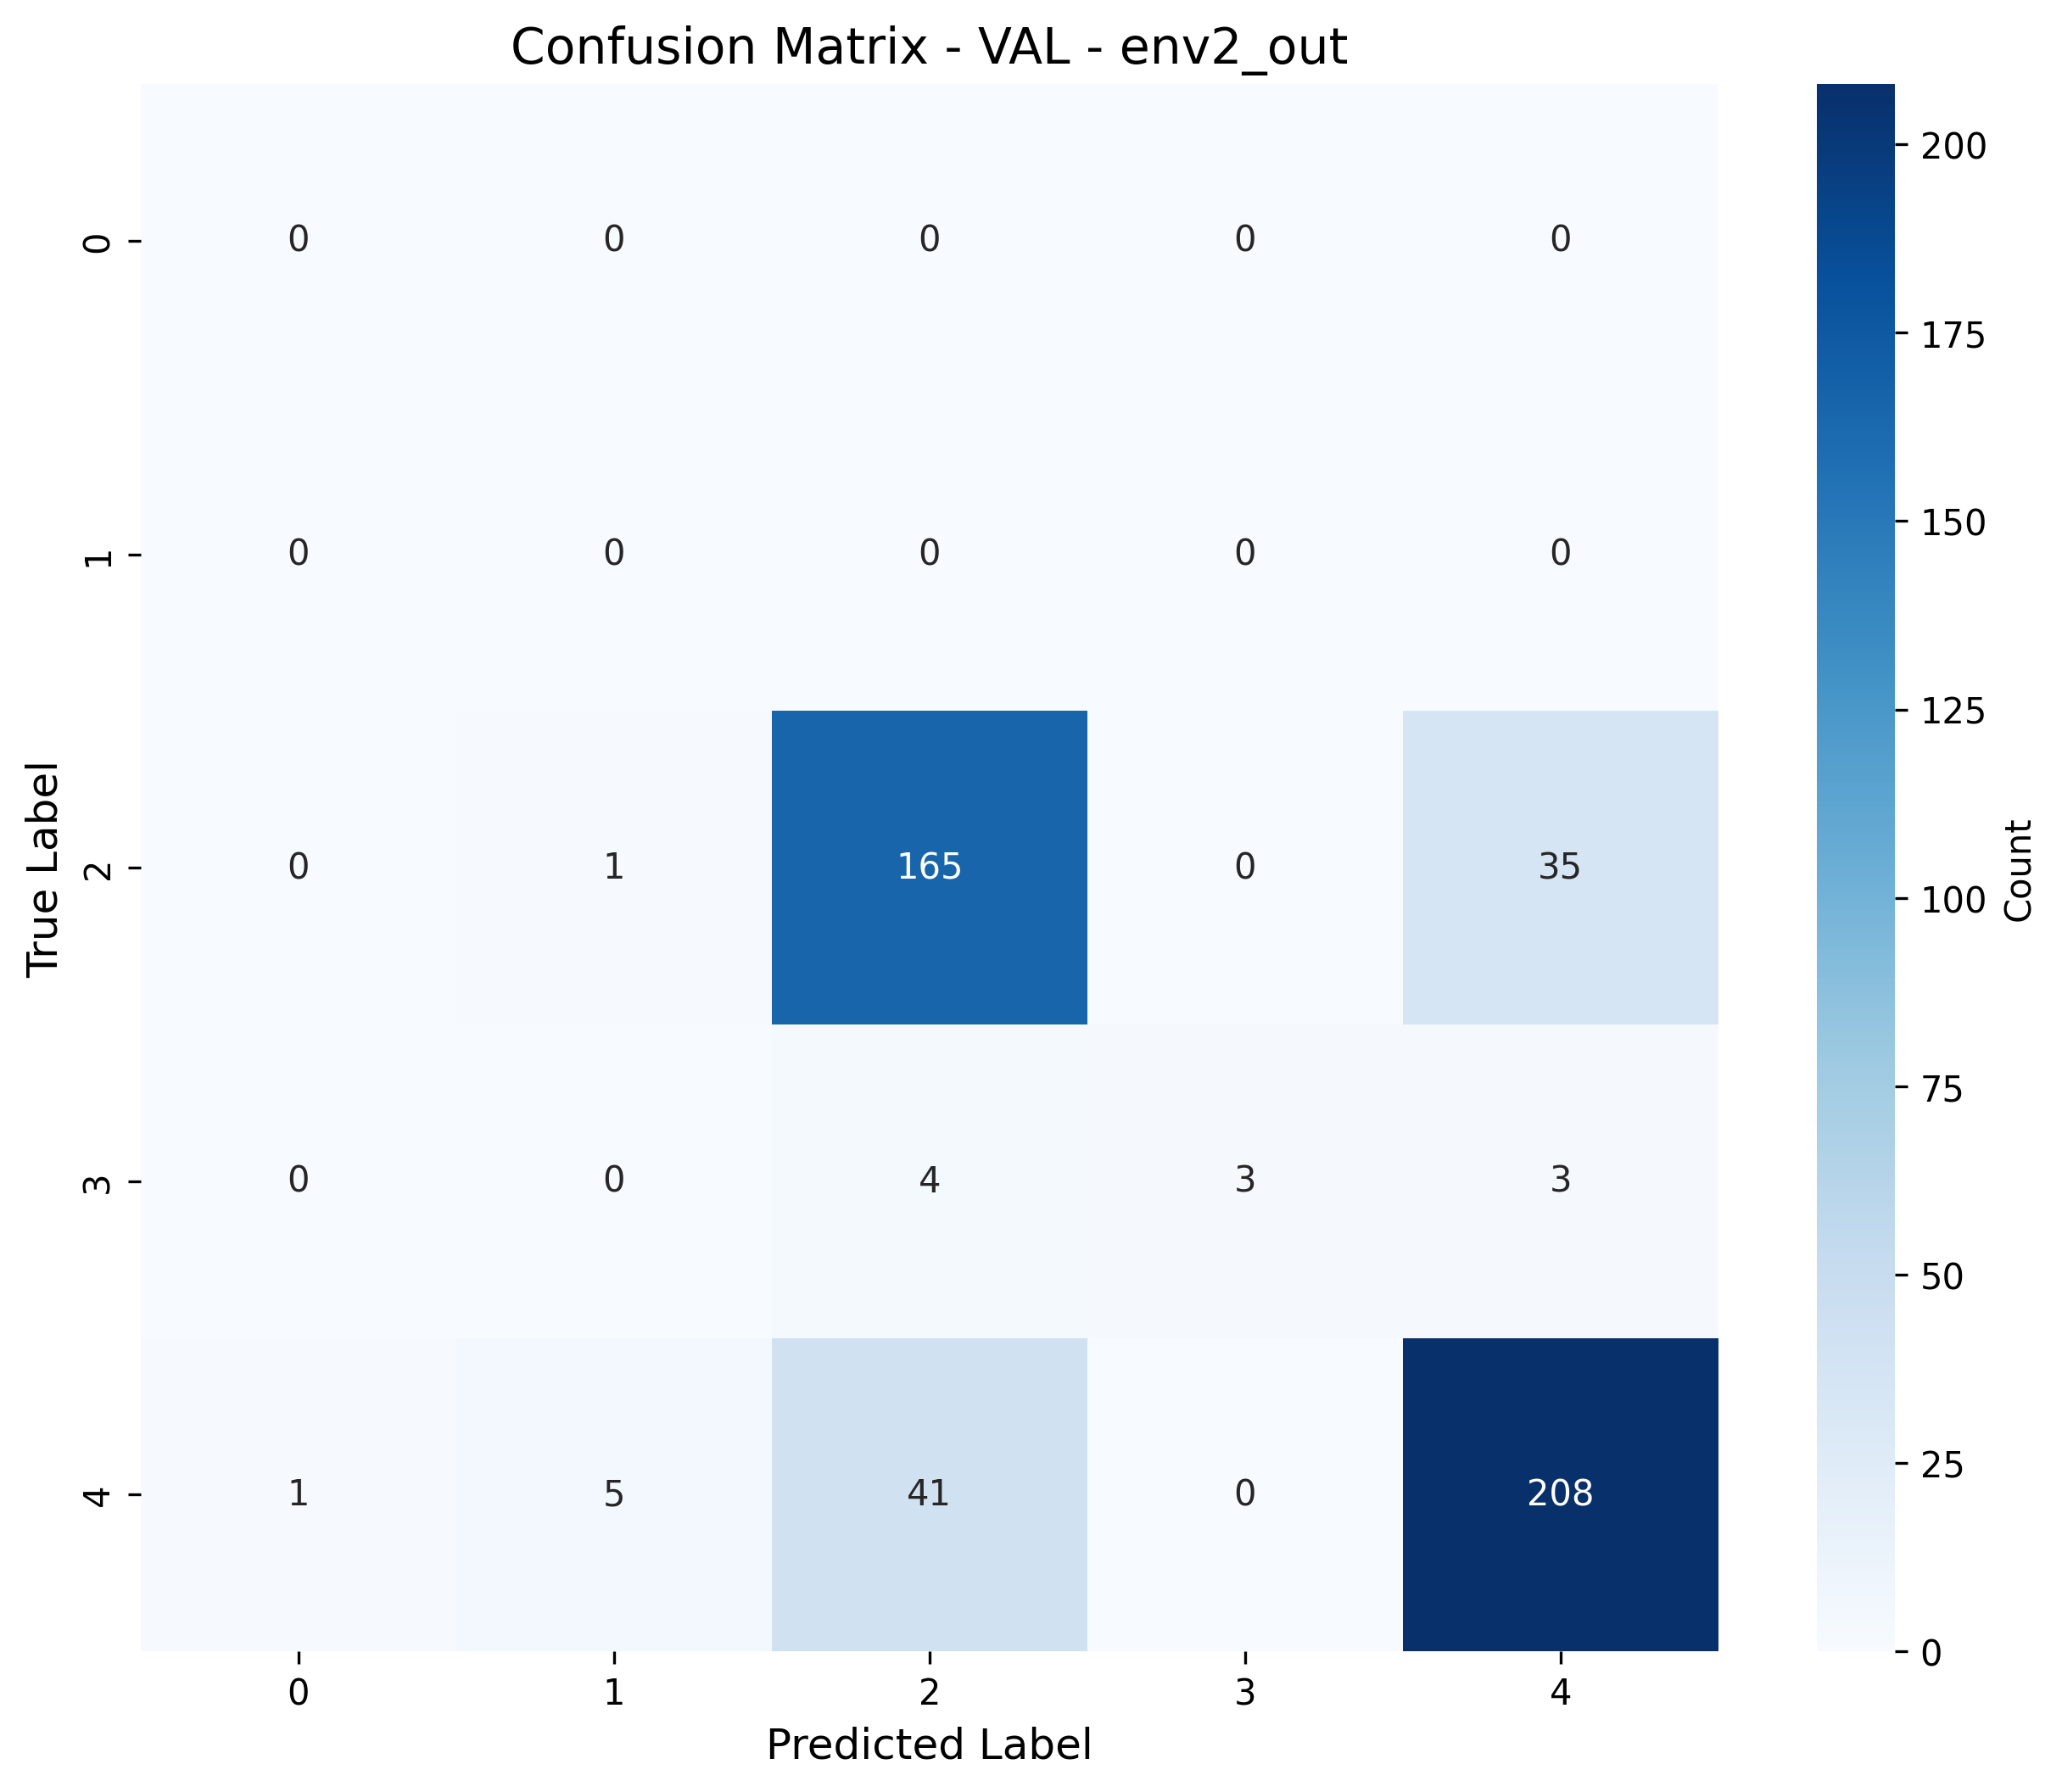


confusion_matrix_VAL_env3_out.png


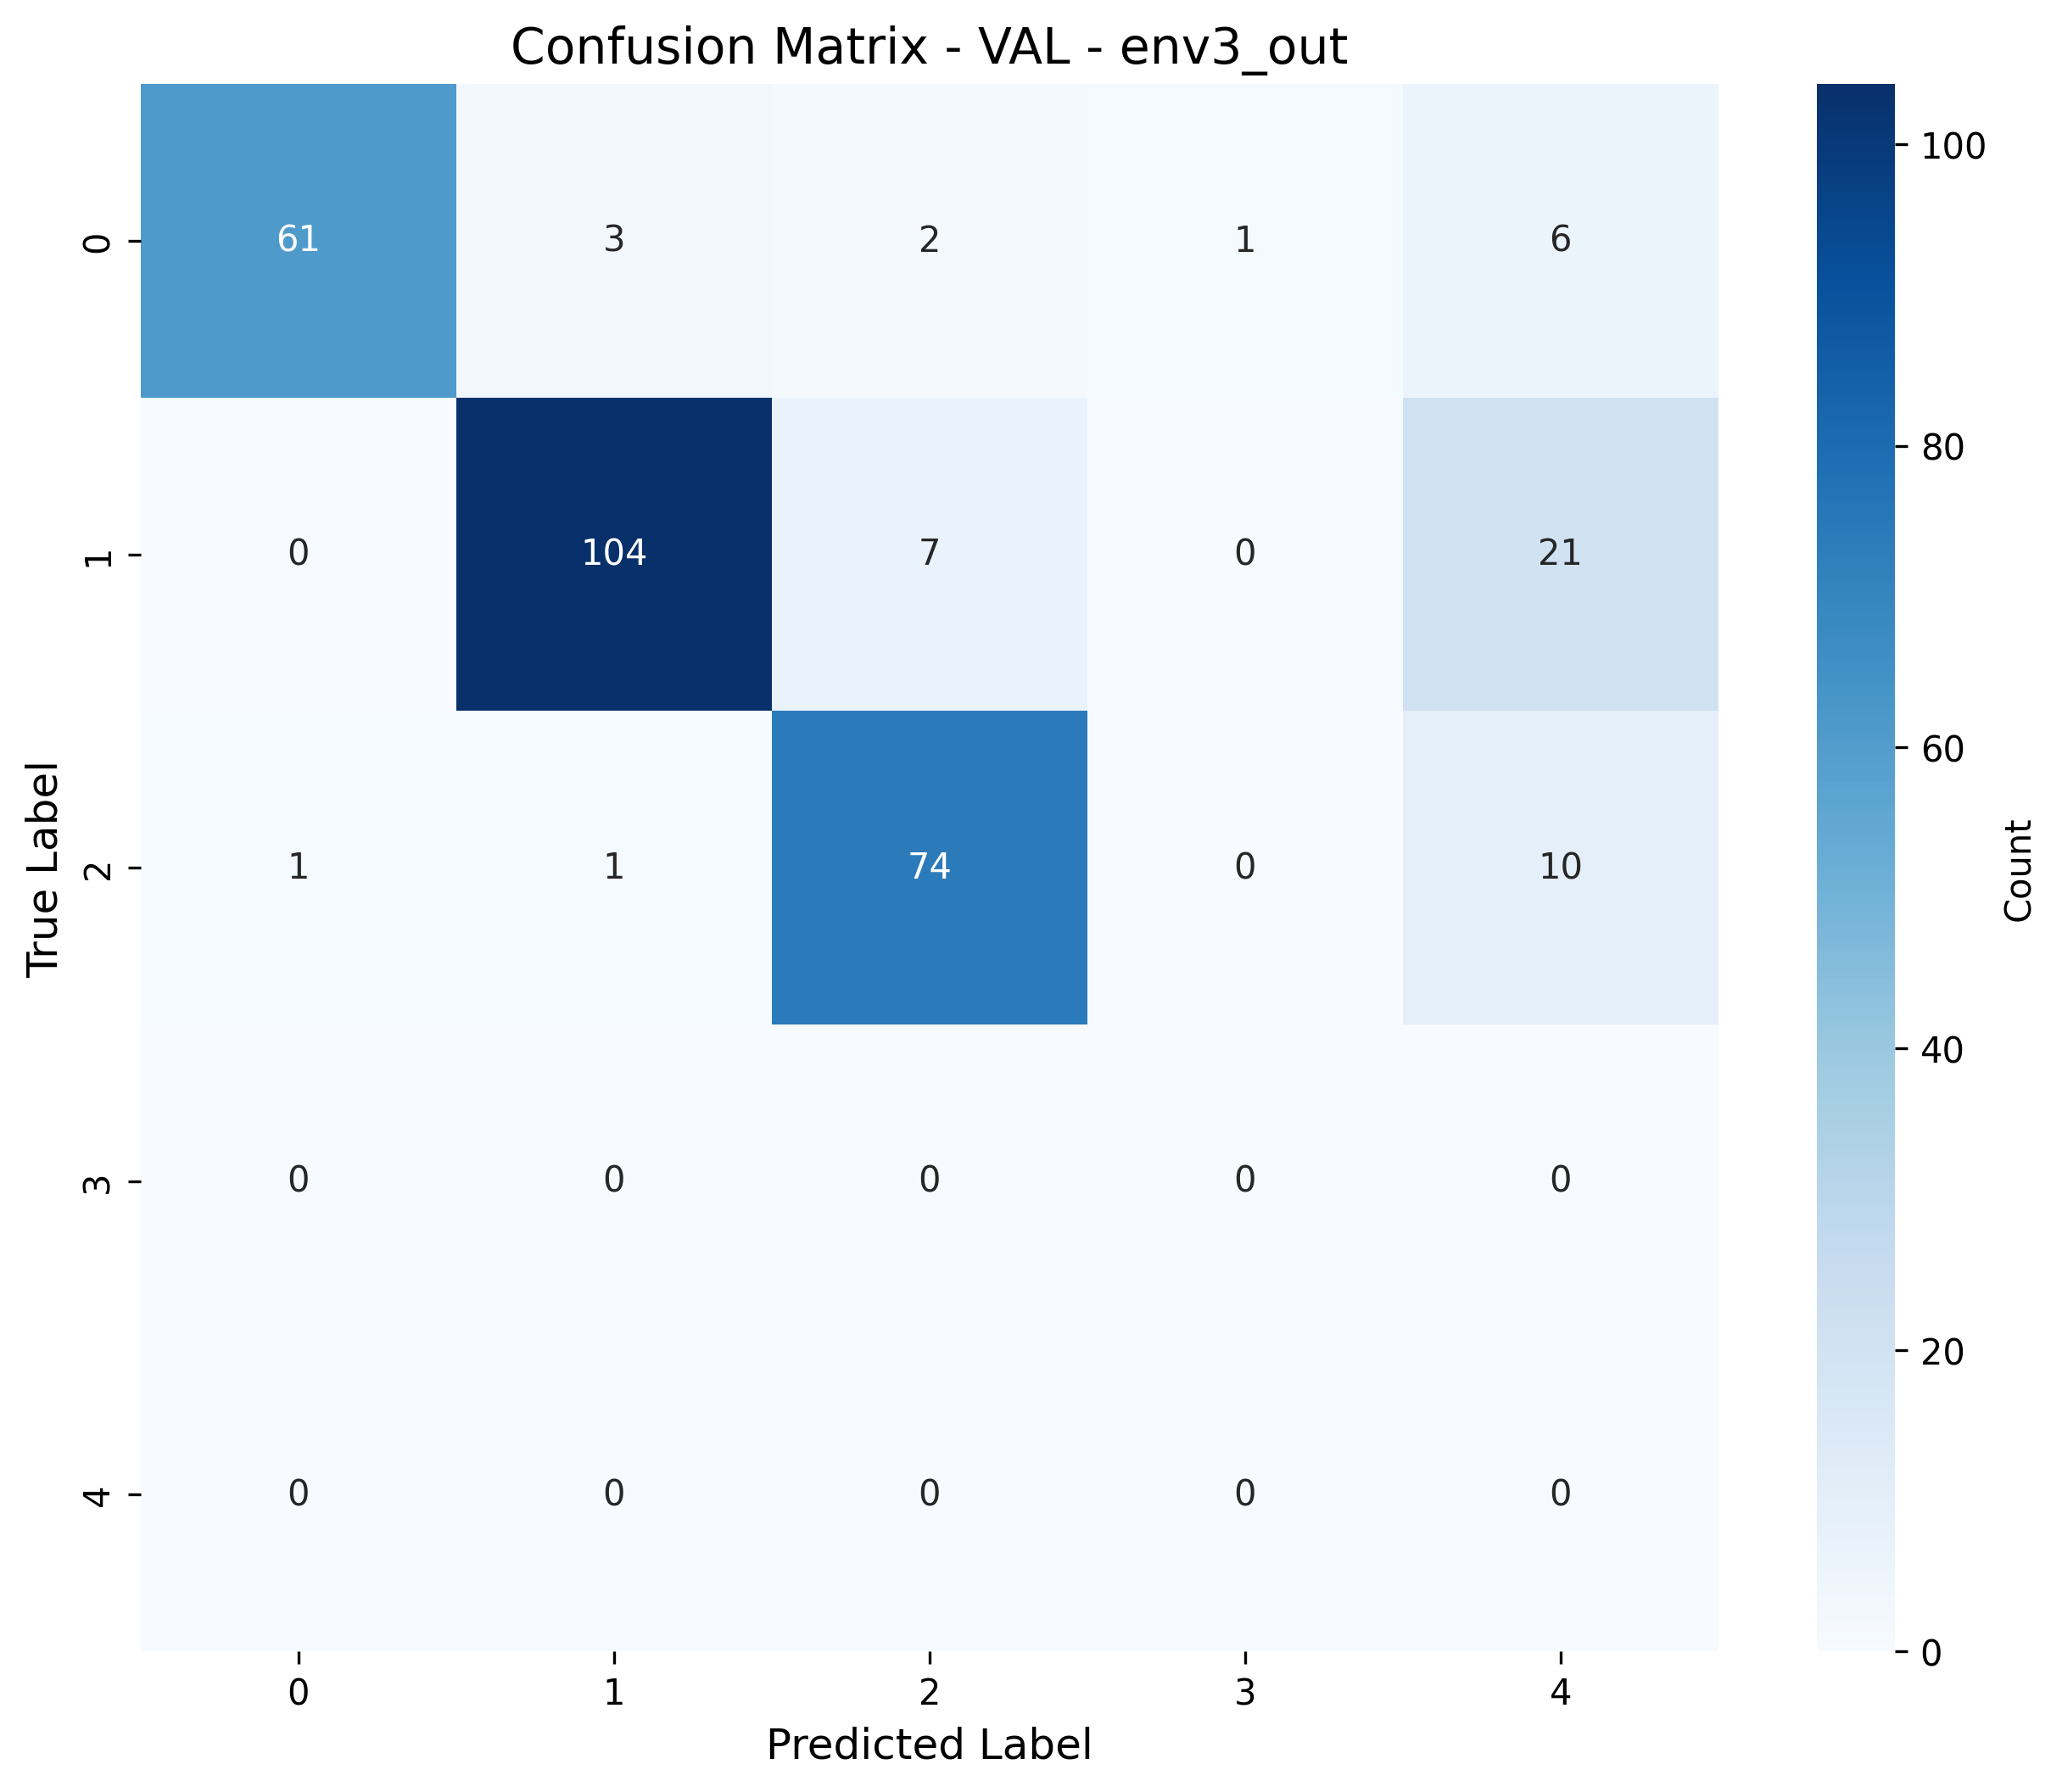



TRAINING CURVES:


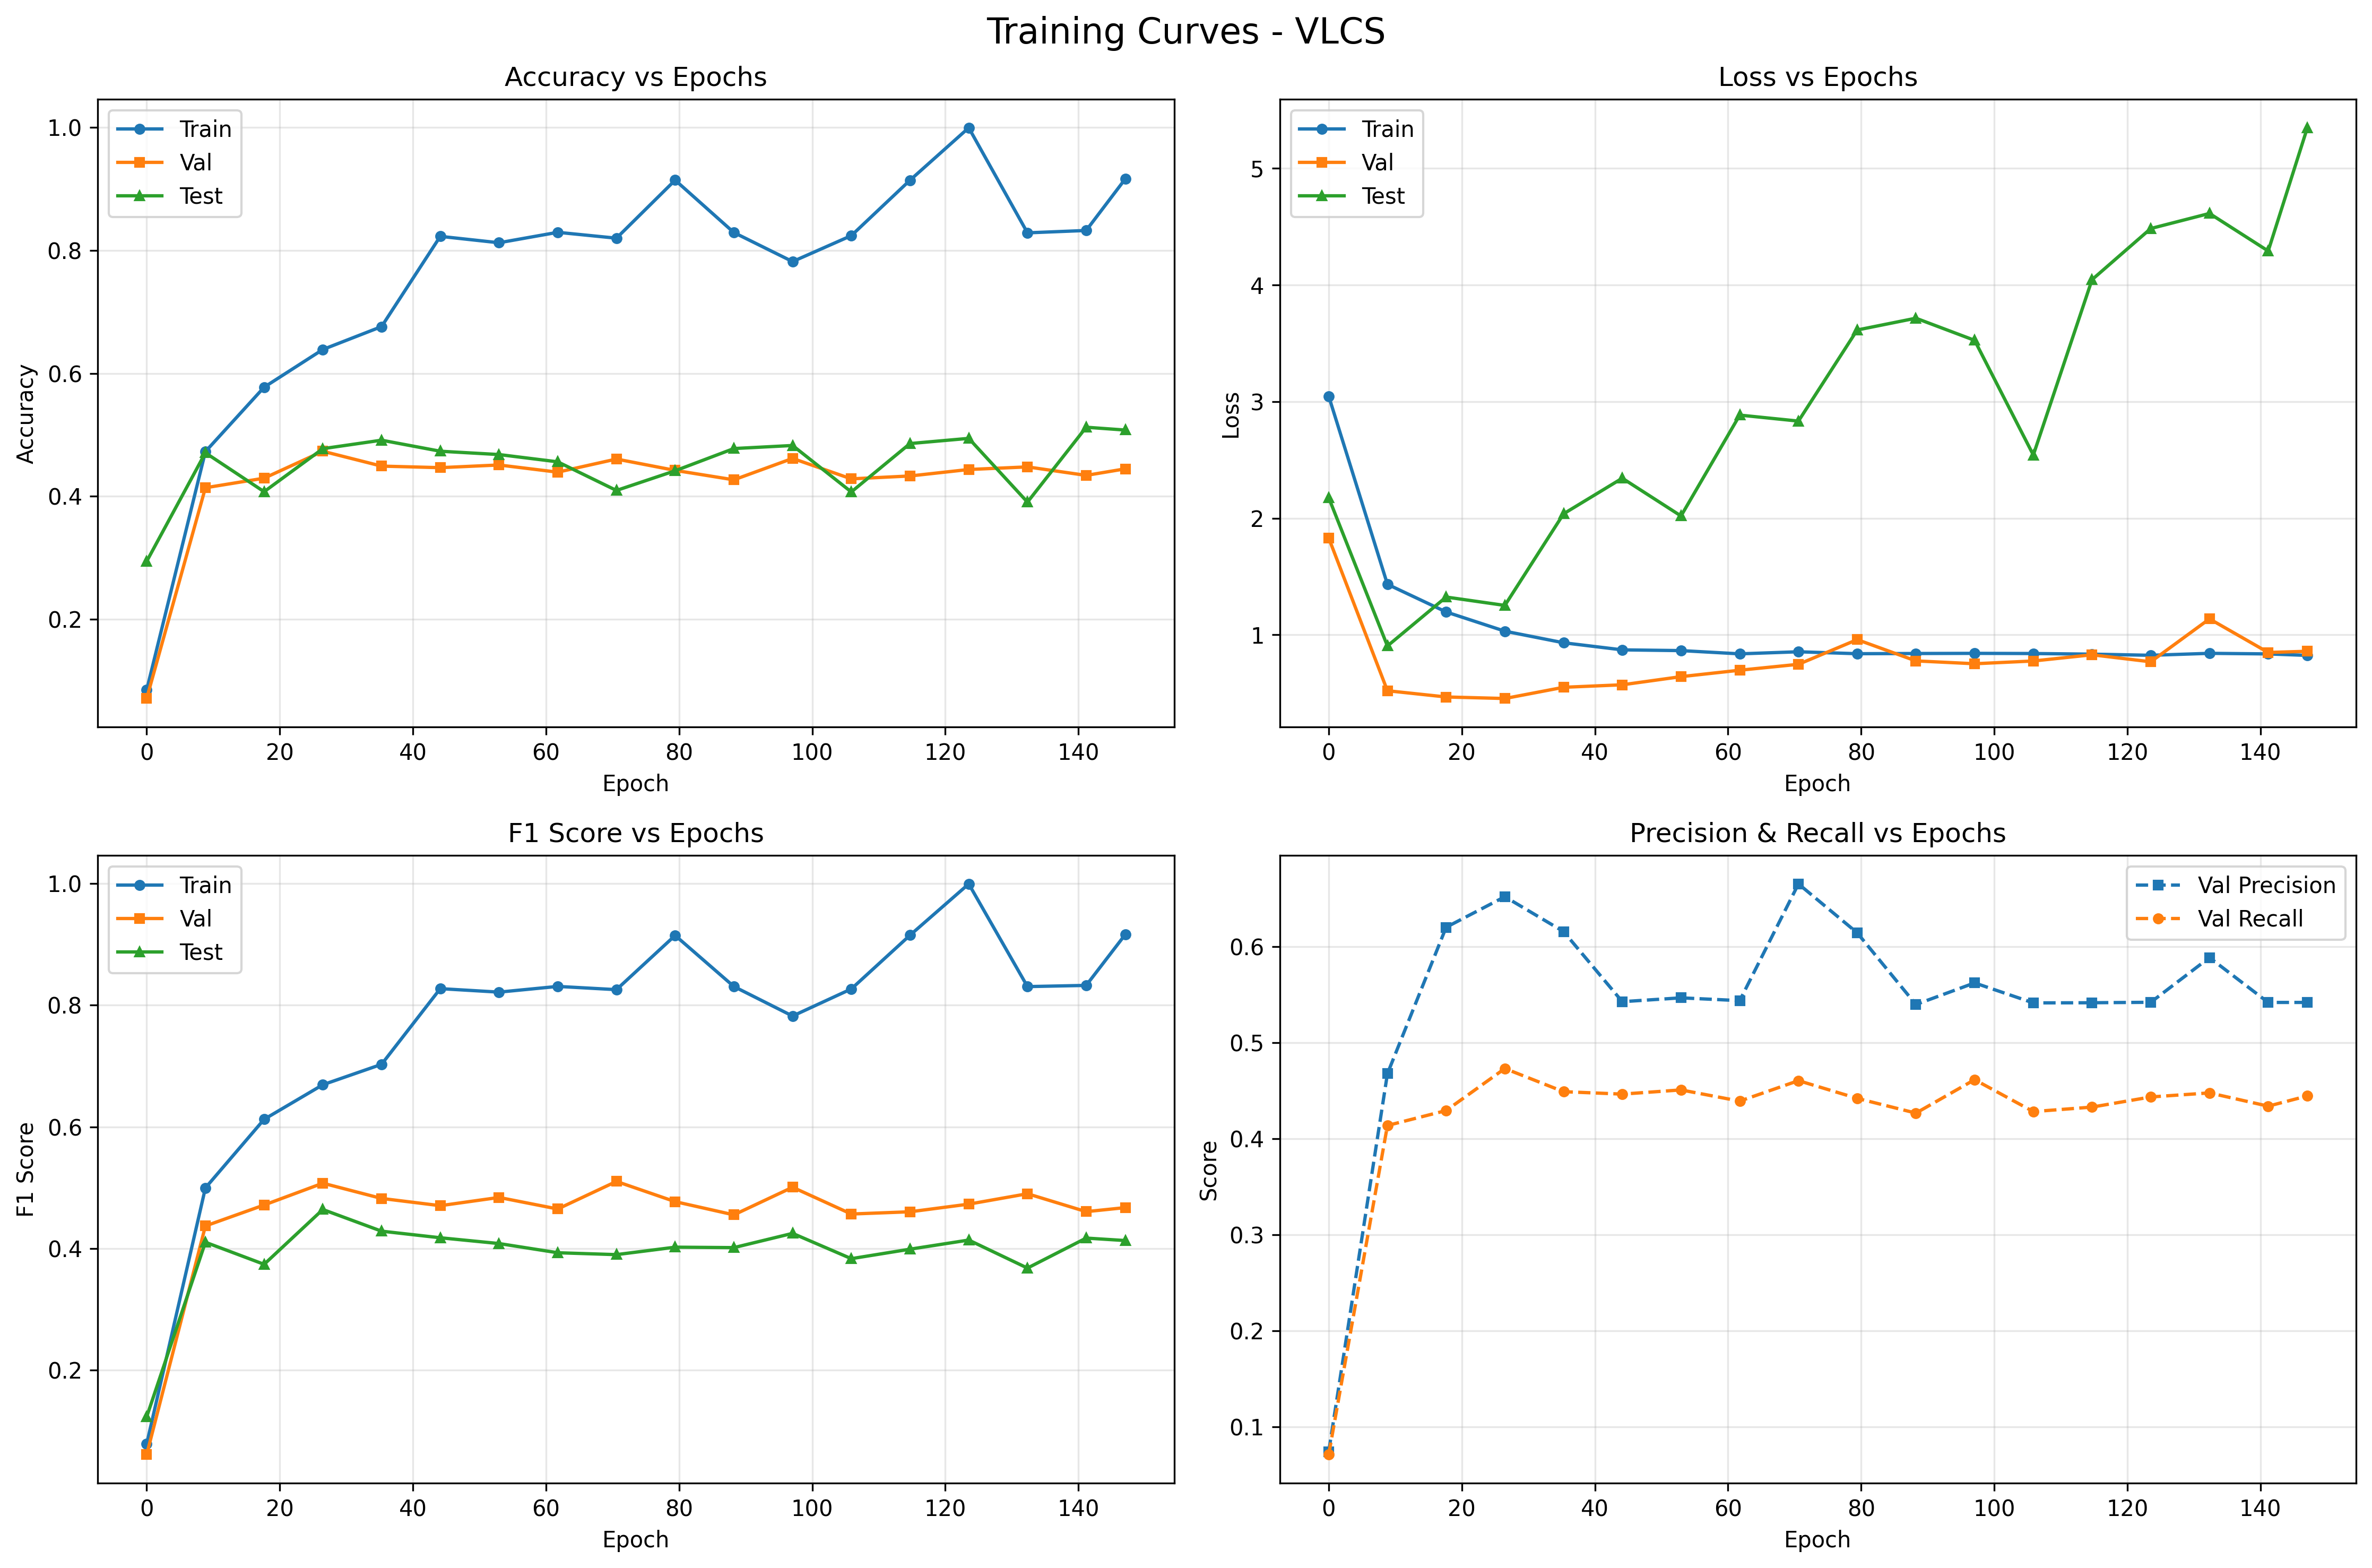

In [27]:


fit_simple(
exp_dir=str(exp_dir),
logger=logger,
seed=config.get("seed", 0),
trial_seed=config.get("trial_seed", 0),
hparams_seed=config.get("hparams_seed", 0),
algorithm_name=config["algo"],
dataset_name=dataset_name_vlcs,
data_dir=config["data_dir"][dataset_name_vlcs],
num_workers=config.get("num_workers", 4),
test_envs=[config["test_set_id"]],
overlap_type=config.get("overlap", "none"),
holdout_fraction=config.get("holdout_fraction", 0.2),
n_steps=config.get("n_epochs"),  # Changed to epochs!
checkpoint_freq=config.get("checkpoint_freq"),  # In epochs
model_checkpoint=config.get("model_checkpoint", {
    "metric": "val/acc",
    "maximize": True
}),
num_domain_linked_classes=config.get("num_domain_linked_classes"),
num_classes=config.get("num_classes"),
# AutoAugmentation specific
auto_augment=config.get("auto_augment", False),
augment_search_epochs=config.get("augment_search_epochs", 10),
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_vlcs.csv'}")
print(f"  Best model: {exp_dir / 'best_model_vlcs.ckpt'}")
print(f"  Config: {exp_dir / 'config_vlcs.json'}")



import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_vlcs}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# Display training curves
print("\n\nTRAINING CURVES:")
print("="*60)
display(Image(filename=os.path.join(log_dir, 'training_curves_VLCS.png')))


## Wilds

In [ ]:
dataset_name = config["dataset"][3]
dataset_name